# Experiments 52 - 54
### Excess Green: _PCA + exGreen / CLAHE / No Finetuning_


### Dataset **UPDATED**:
- **Dataset:** 3.5m | 90º
    - 2 PCA + exGreen + BurnBlend_(false color images)_
- **Sizes:** small & mid
- **Split:** 640 px
- **Tags:**  `plant-weed`
- **Train/Valid dist:** 66,6% / 33,3%

### Model:
- **Model:** `yolov8m` *(Medium)*
- **Epochs:** ~500
- **Batch:** 64
- **Freeze:** 10

### Experiments:
1. 2 PCA + exGreen w/Bl
1. Same + CLAHE
1. Random weights + ExG w/PCA+xG+Bl

- **Reference:** RGB + Freezing Backbone *(10 layers) **Exp. 50*** 
## AGREGAR REFERENCIA SIN FREEZING

In [1]:
# CONFIG FOLDER PATH

# Get the project root directory (replace with your actual path)
experiment_number = 3
project_root = "../" * 2

# The folder you want to navigate to (relative to the root)
target_folder = f"docs/Experimentos/8 exGreen/{experiment_number} set/runs/detect/"

### Init

In [2]:
scale: int = 500 # size for graphs (in pixels)

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [4]:
def update_project_root(path = ''):
    global project_root
    if not path:
        path = os.getcwd()
    folder_depth = len([i for i in path.split("/") if i != ''])
    project_root = "../" * folder_depth

In [5]:
def change_directory(target_folder):
    """
    Change the current working directory to the target folder.
    Args:
        target_folder (str): The target folder path relative to the project root.
    """ 
    global project_root
    # Construct the full path
    target_path = os.path.join(project_root, target_folder)

    # Change the current working directory
    try:
        os.chdir(target_path)
        print(f"Current working directory: {os.getcwd()}")  # Verify

        folder_depth = len([i for i in target_folder.split("/") if i != ''])
        project_root = "../" * folder_depth
        print(f"Project root updated to: {project_root}")  # Verify

    except FileNotFoundError:
        print(f"Error: Folder '{target_path}' not found. Check the path.")
    except NotADirectoryError:
        print(f"Error: '{target_path}' is not a directory.")
    except Exception as e:
        print(f"An error occurred: {e}")

In [6]:
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/8 exGreen/3 set/runs/detect
Project root updated to: ../../../../../../


In [7]:
# Reset to the root path
# os.chdir(project_root)
# print(f"Current working directory: {os.getcwd()}") #Verify

In [8]:
best_models = pd.DataFrame(
    columns=['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'train_time'],
       data = None
       )

#### Functions

In [9]:
def show_cm(TP, FP, FN):
    matrix = [[TP, FP], [FN, 0]]
    total_det = sum(sum(value) for value in matrix)
    percentages = []
    for row in matrix:
        values_percentages = []
        for value in row:
            if total_det != 0:
                percentage = (value / total_det) * 100
            else:
                percentage = 0.0
            values_percentages.append(f"{percentage:.2f}%")
        percentages.append(values_percentages)
    
    print("Total objects detected:", total_det)
    print("\nConfusion matrix:")
    for row in percentages:
        a, b = row
        print(f"[ {a} , {b} ]")

In [10]:
def show_metrics(TP, FP, FN):
    show_cm(TP, FP, FN)
    accuracy = TP/(TP+FP+FN)
    precision = TP/(TP+FP)
    recall = TP/(TP+FN)
    f1 = 2 * (precision * recall) / (precision + recall)
    f2 = 1.25 * (precision * recall) / (0.25 * precision + recall)
    fm = (precision * recall) ** 0.5
    print("\nMetrics:")
    print(f"- Accuracy: {accuracy:.3f}")
    print(f"- Precision: {precision:.3f}")
    print(f"- Recall: {recall:.3f}")
    print(f"- F1 Score: {f1:.3f}")
    print(f"- F½ Score: {f2:.3f}")
    print(f"- G-mean: {fm:.3f}")

In [11]:
def graph_training_metrics(df: pd.DataFrame, epoch: np.int64, graph: str="tight"):
    """
    Plots training and validation metrics from a training log DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing training metrics, including columns
                           'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                           'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
                           'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                           'metrics/mAP50-95(B)', and optionally 'lr/pg0' for the 'lr' graph.
        graph (str, optional): Type of graph to display. Options are:
            - "tight": Displays loss and metrics in a single row.
            - "full": Displays loss and metrics in two rows.
            - "lr": Displays loss, metrics, and learning rate in three rows.
            Defaults to "tight".

    Raises:
        ValueError: If the 'graph' parameter is not one of "tight", "full", or "lr".
    """
    graph = graph.lower()

    # Tight view (one row)
    if graph == "tight":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 6))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(1, 2, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(1, 2, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X


    # Full view (two rows)
    elif graph == "full":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 12))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(2, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(2, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

    # Shows also Lr graph (three rows)
    elif graph == "lr":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 15))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(3, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(3, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

        # Gráfico de evolución del learning rate
        plt.subplot(3, 1, 3)
        plt.plot(df["epoch"], df["lr/pg0"], label="Learning Rate (pg0)", color="cadetblue", marker='.', linestyle='-')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Evolution")
        plt.grid(True)

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

    else:
        raise ValueError(f"Invalid graph parameter: '{graph}'. Must be one of 'tight', 'full', or 'lr'.")

    plt.tight_layout()
    plt.show()

In [12]:
def graph_LrLoss(df):
    """Generates a 3D plot of Learning Rate vs. Loss vs. Epoch."""

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Data
    epochs = df['epoch']
    losses = df['val/cls_loss']  # or df['train/cls_loss'], or combined as needed.
    lrs = df['lr/pg0']

    # Scatter plot
    ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis', marker='o')

    # Labels
    ax.set_xlabel('Learning Rate (lr/pg0)')
    ax.set_ylabel('Classification Loss (val/cls_loss)')
    ax.set_zlabel('Epoch')
    ax.set_title('3D Plot: Learning Rate vs. Loss vs. Epoch')

    # Color bar
    fig.colorbar(ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis'), label='Loss Value')

    plt.show()

In [13]:
def graph_LrLoss_3D(df, set: str='val'):
    """Generates an interactive 3D plot of Learning Rate vs. Loss vs. Epoch."""

    if set.lower() == 'val':
        print("Validation set")
        loss_set = 'val/cls_loss'
        title_set = 'Validation'
    elif set.lower() == 'train':
        print("Training set")
        loss_set = 'train/cls_loss'
        title_set = 'Train'
    else:
        print("Debe indicarse el set de entrenamiento: set debe ser igual 'val' o 'train'")
        return  

    fig = go.Figure(data=[go.Scatter3d(
        x=df['lr/pg0'],
        y=df[loss_set],
        z=df['epoch'],
        mode='markers',
        marker=dict(
            size=5,
            color=df[loss_set], # color based on loss value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Loss Value')  # Add colorbar
        )
    )])

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(title='Learning Rate (lr/pg0)'),
            yaxis=dict(title=f'Classification Loss ({loss_set})'),
            zaxis=dict(title='Epoch'),
        ),
        title=f'Learning Rate vs. {title_set} Loss vs. Epoch'
    )

    fig.show()

----

# Experimentos

## Experiment 52
### *YOLOv8 Mid | False color images*
False color images are created by applying:
1. Excess Green to a grayscale image.
1. A 2-component PCA (to reduce dimensionality).
1. Combining these images as RGB channels.

In [14]:
folder = "train/"

In [15]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
241,242,2921.24,1.07657,0.58082,0.96100,0.51469,0.42713,0.39672,0.12422,2.69882,1.49952,2.18069,0.001201,0.001201,0.001201
242,243,2933.26,1.07573,0.58165,0.96857,0.48396,0.43866,0.39470,0.12431,2.69026,1.47074,2.15744,0.001197,0.001197,0.001197
243,244,2945.43,1.05966,0.58042,0.95781,0.46403,0.43923,0.38127,0.12162,2.74258,1.52852,2.20124,0.001194,0.001194,0.001194
244,245,2957.21,1.06973,0.59604,0.97181,0.47934,0.46668,0.40180,0.12794,2.73465,1.48010,2.19184,0.001191,0.001191,0.001191
245,246,2969.00,1.04018,0.57227,0.95340,0.49518,0.46898,0.41793,0.13345,2.71875,1.49812,2.24469,0.001187,0.001187,0.001187


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [16]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 49.483 min


#### Best epoch

In [17]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
45,46,573.463,1.91756,1.15843,1.31109,0.51404,0.45852,0.44114,0.1469,2.40121,1.45162,1.74985,0.001846,0.001846,0.001846,49.483333


In [18]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 46 con mAP50 de 0.441


In [19]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [106]:
# Setting values from CM graph
TP = 1816
FP = 1447
FN = 1656

In [107]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 4919

Confusion matrix:
[ 36.92% , 29.42% ]
[ 33.67% , 0.00% ]

Metrics:
- Accuracy: 0.369
- Precision: 0.557
- Recall: 0.523
- F1 Score: 0.539
- F½ Score: 0.550
- G-mean: 0.540


### Graphs

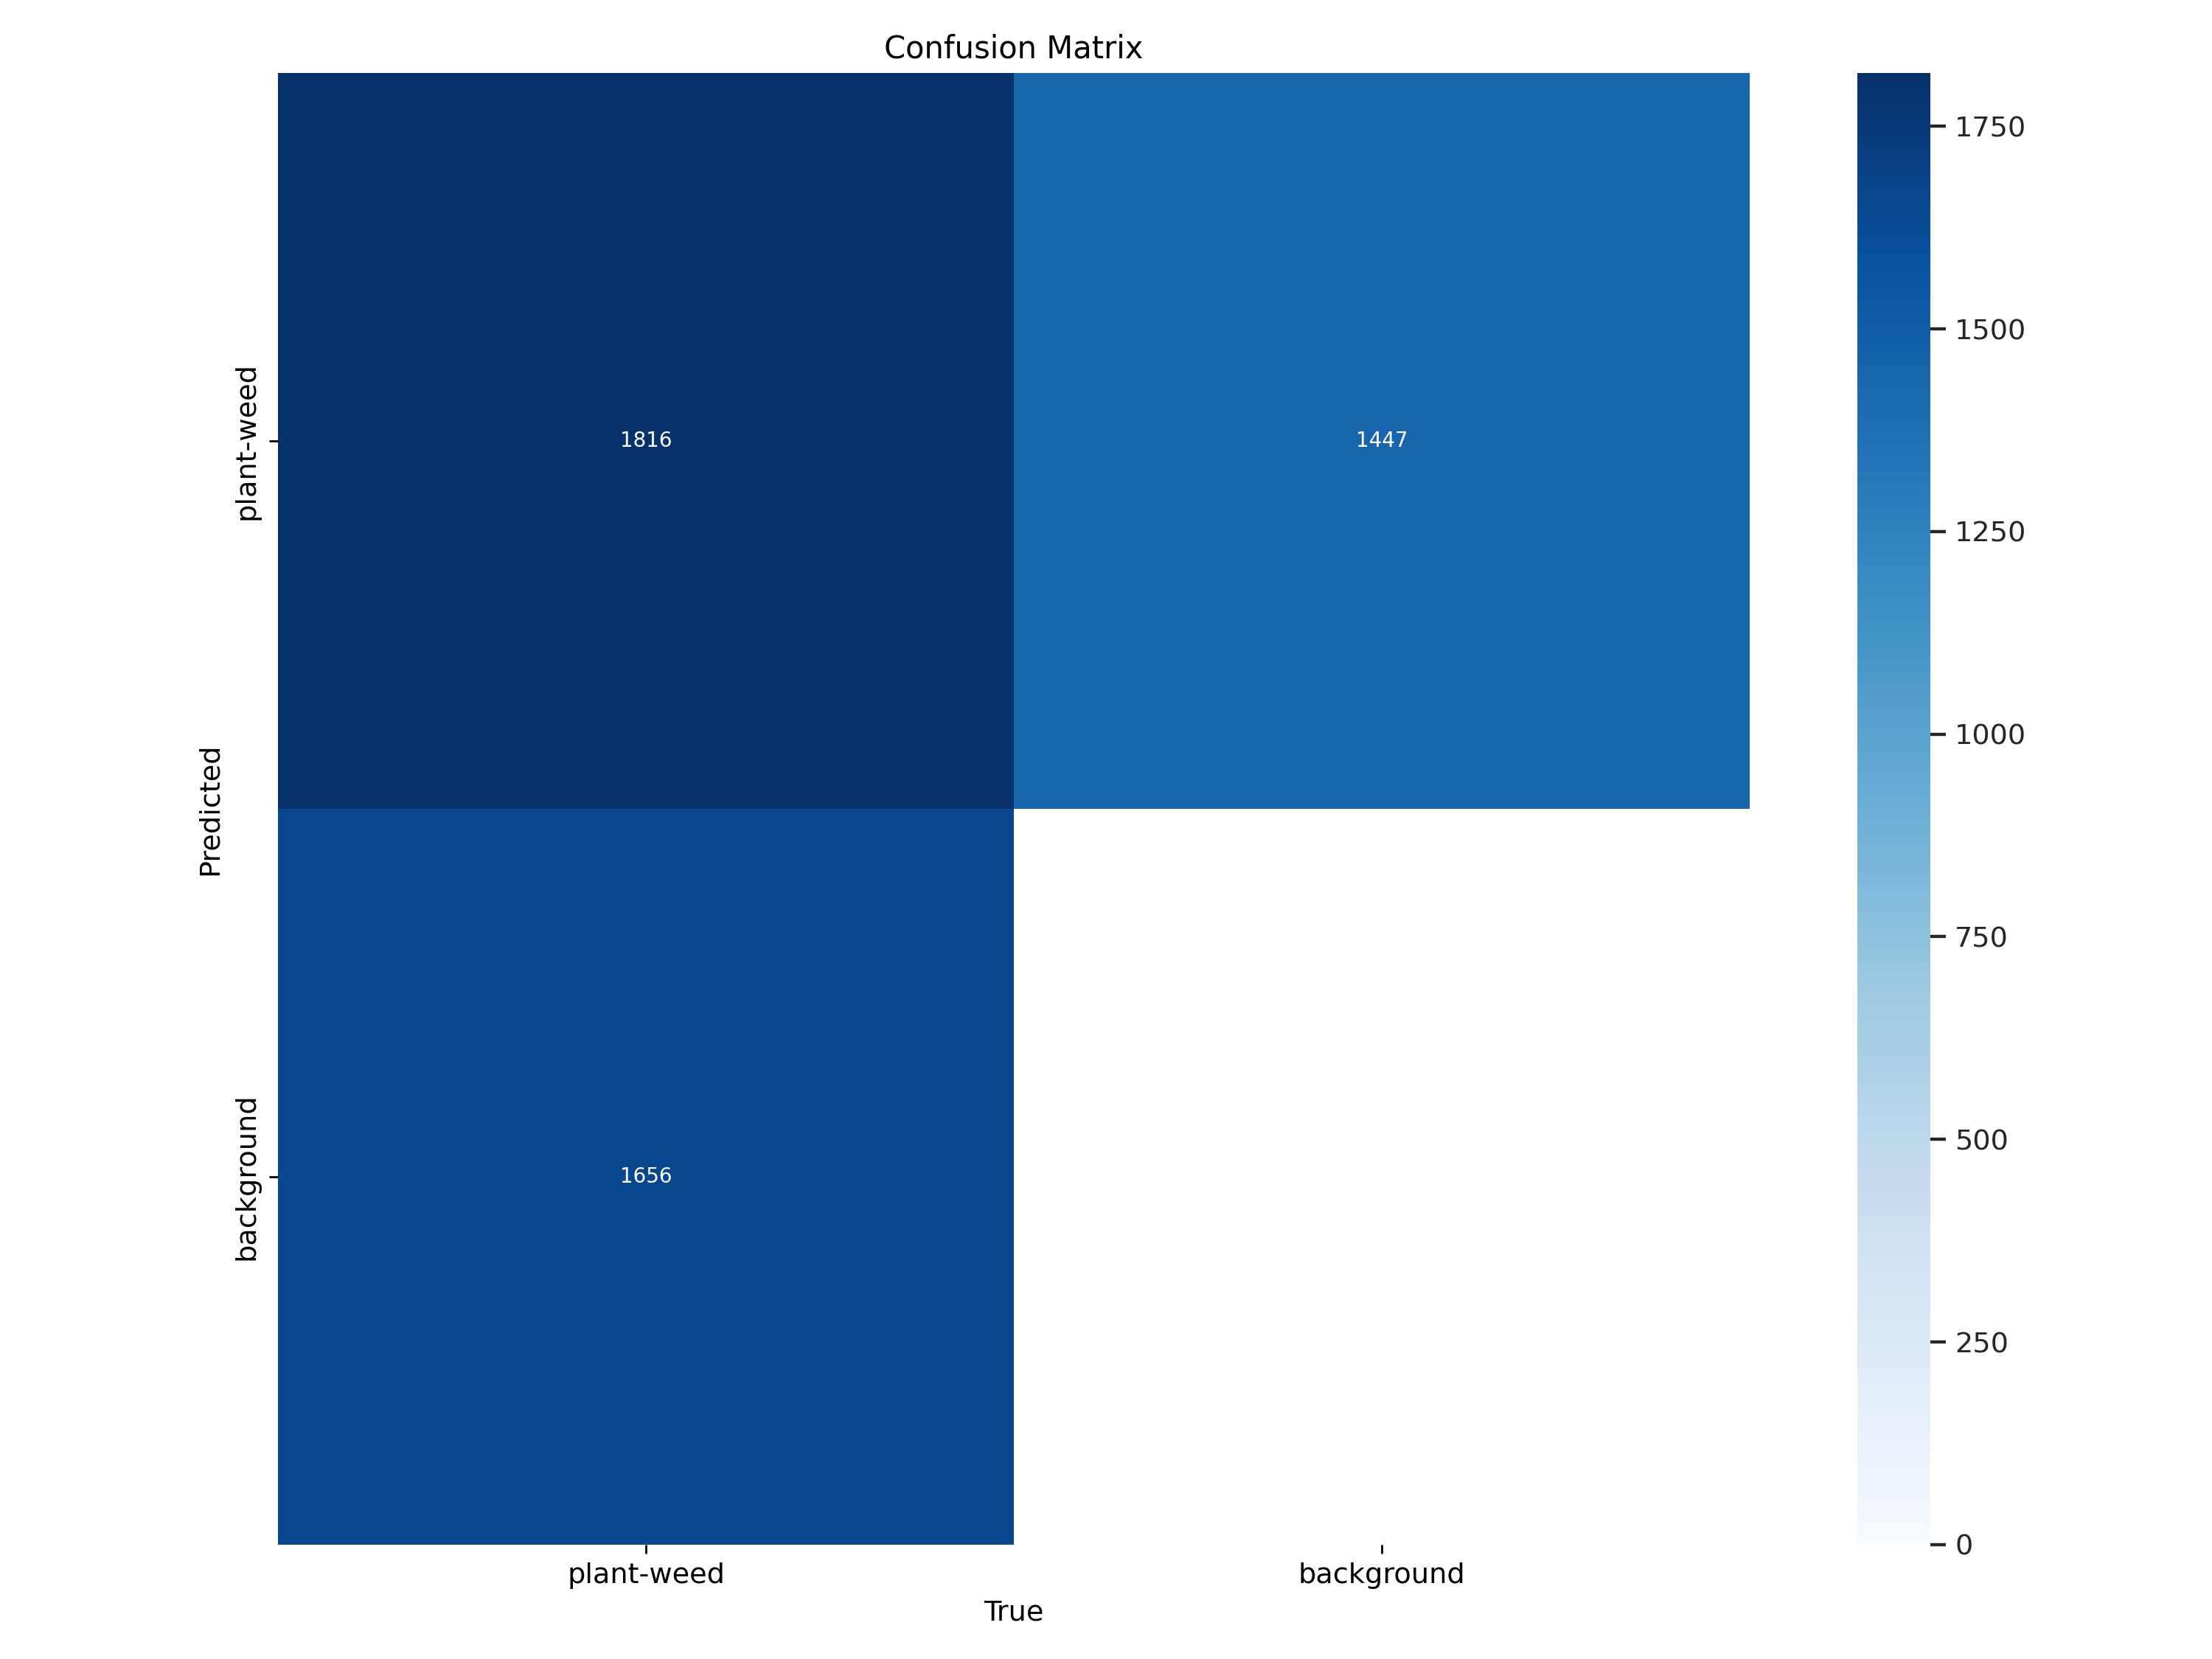

In [22]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

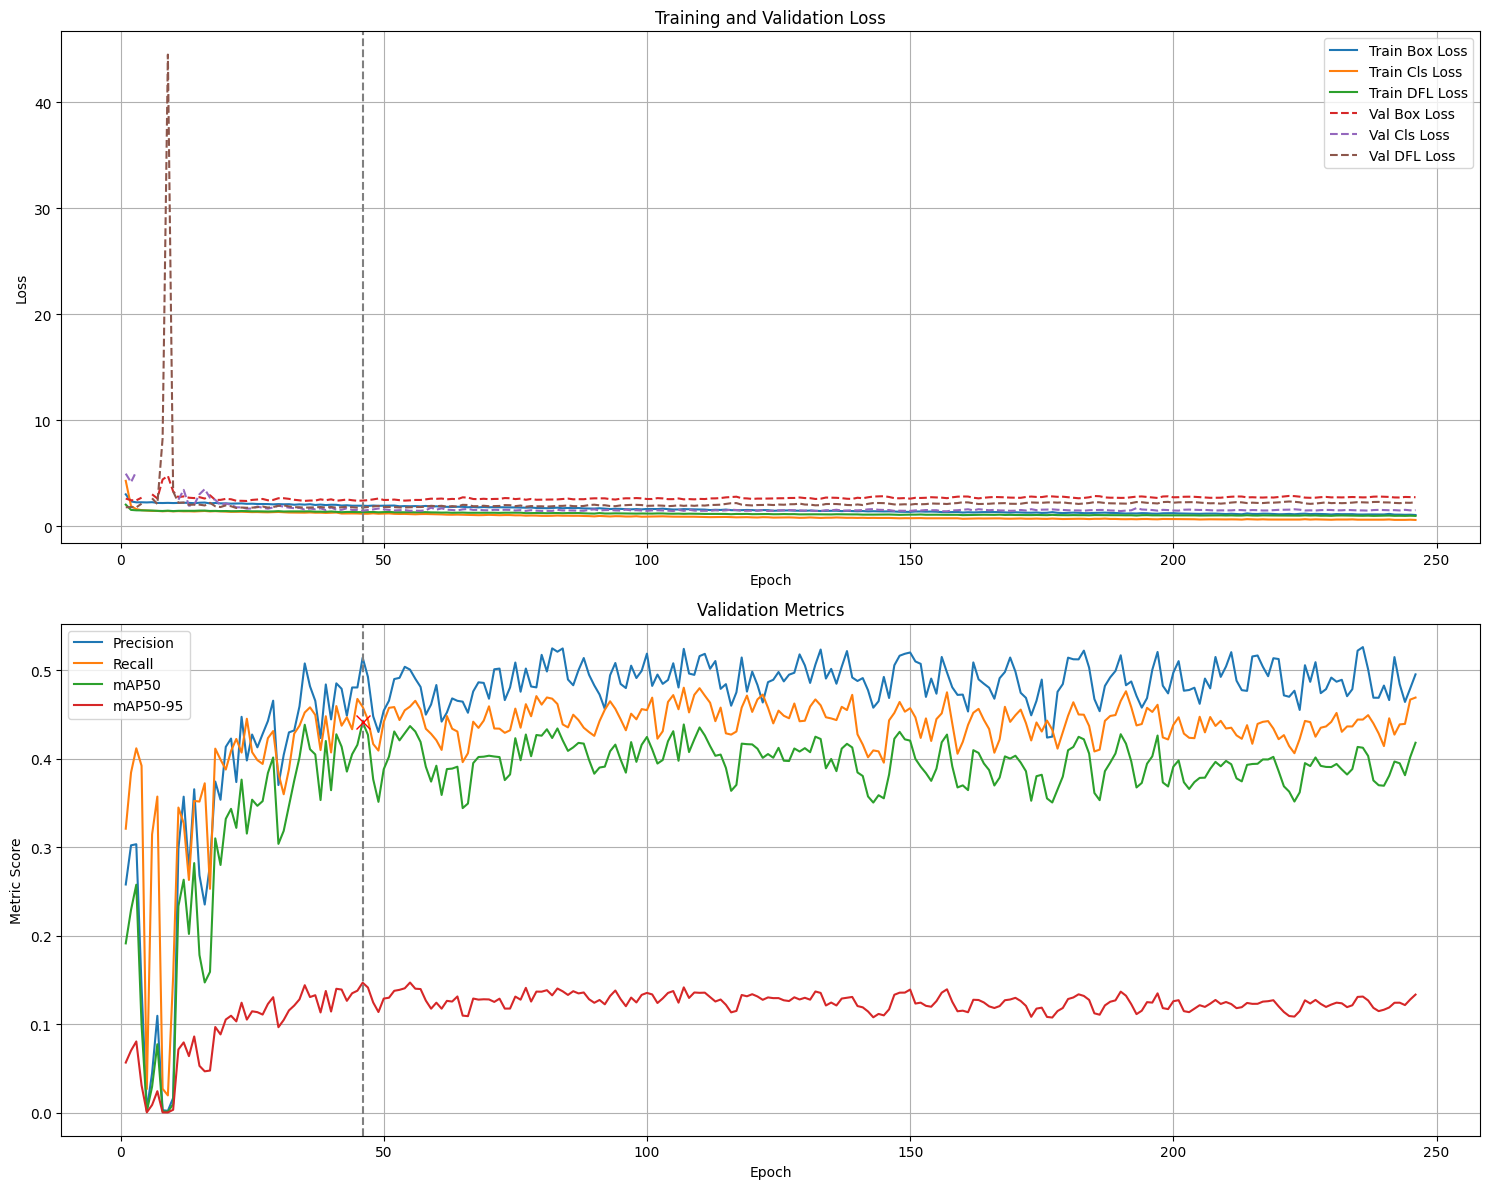

In [23]:
graph_training_metrics(df, epoch, graph="full")

In [24]:
graph_LrLoss_3D(df)

Validation set


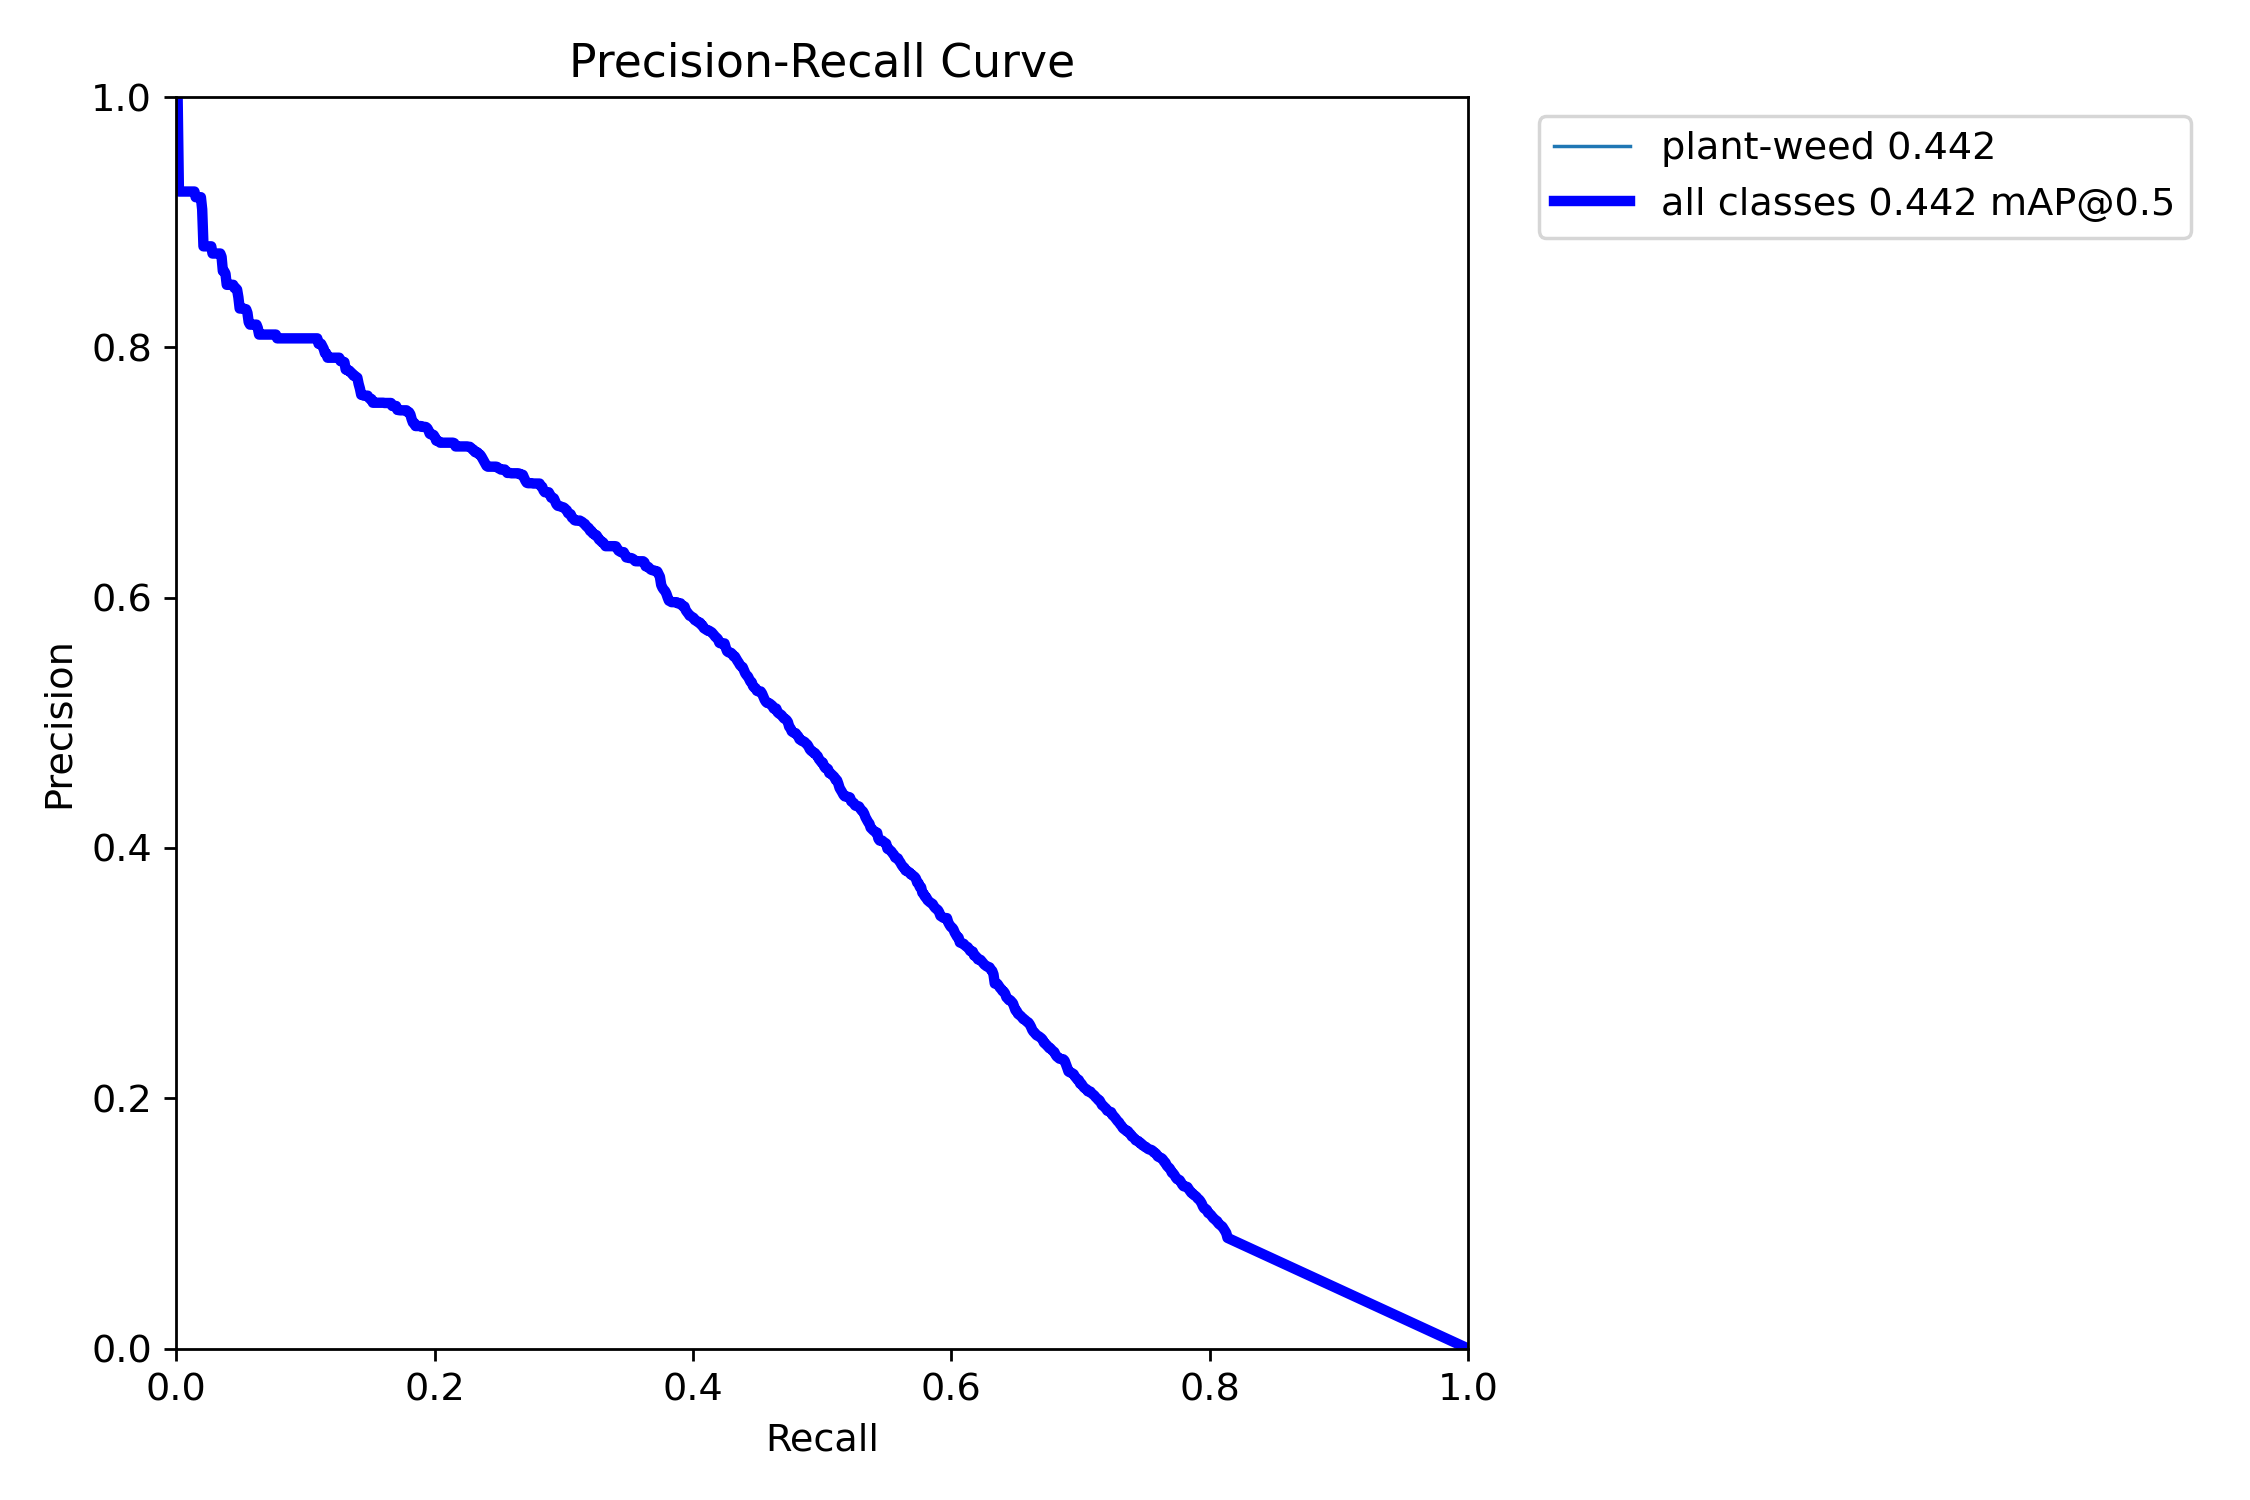

In [25]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

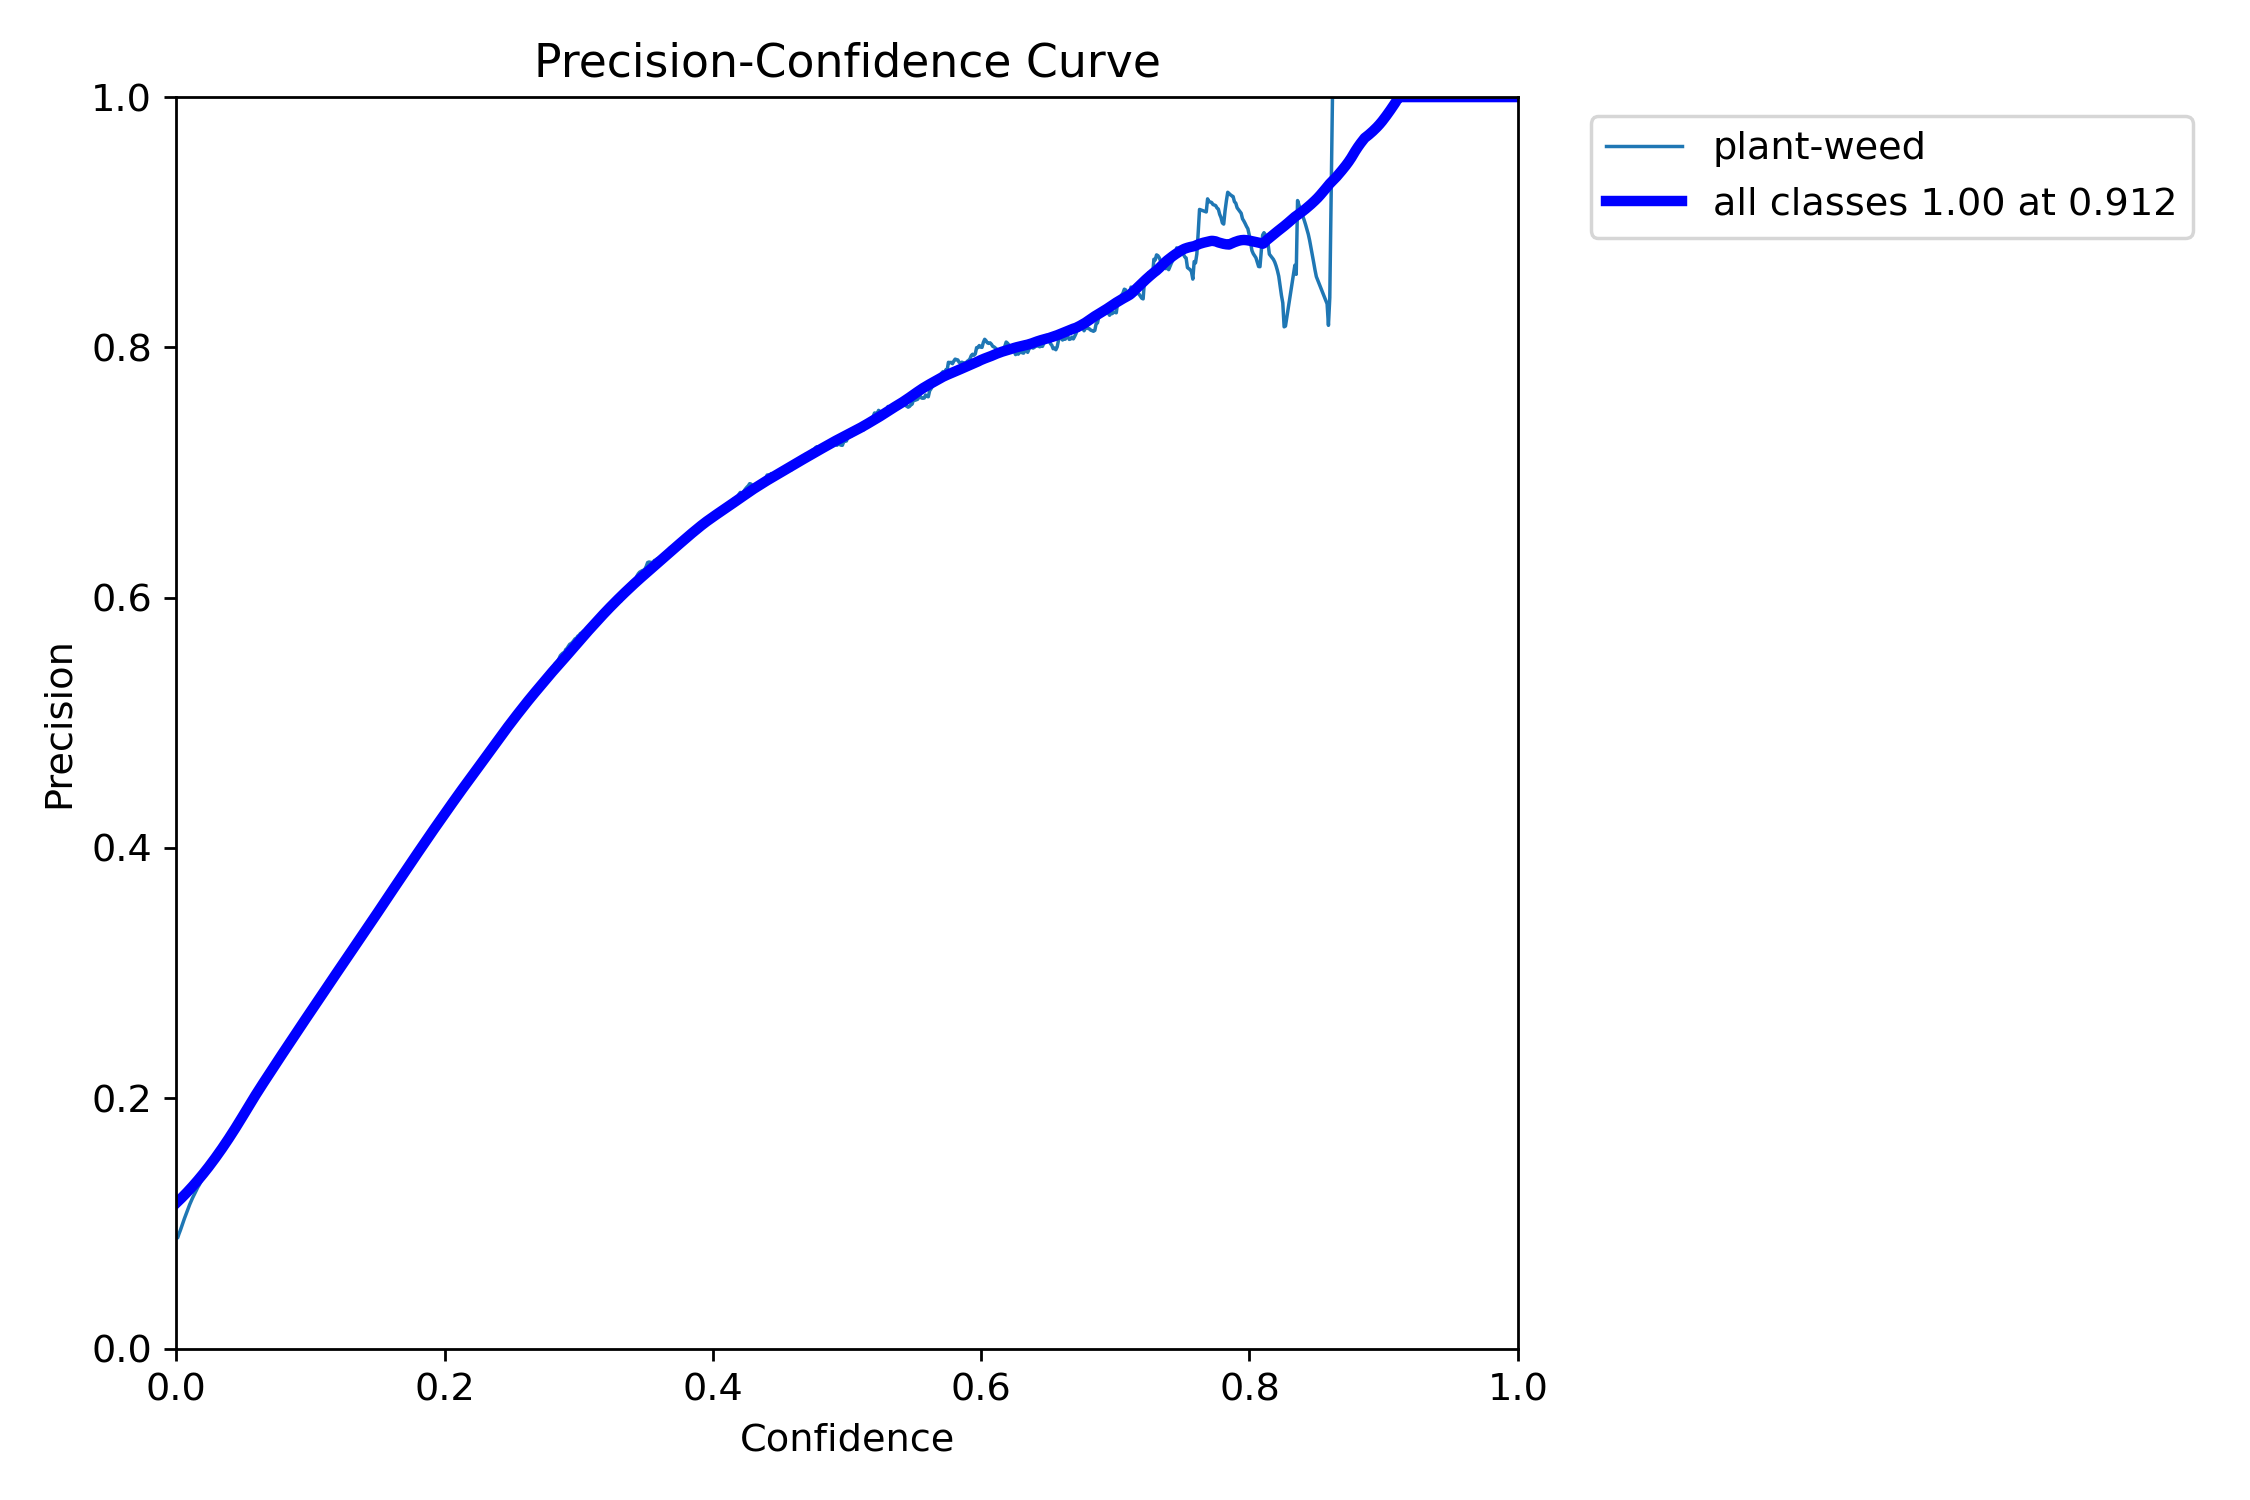

In [26]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

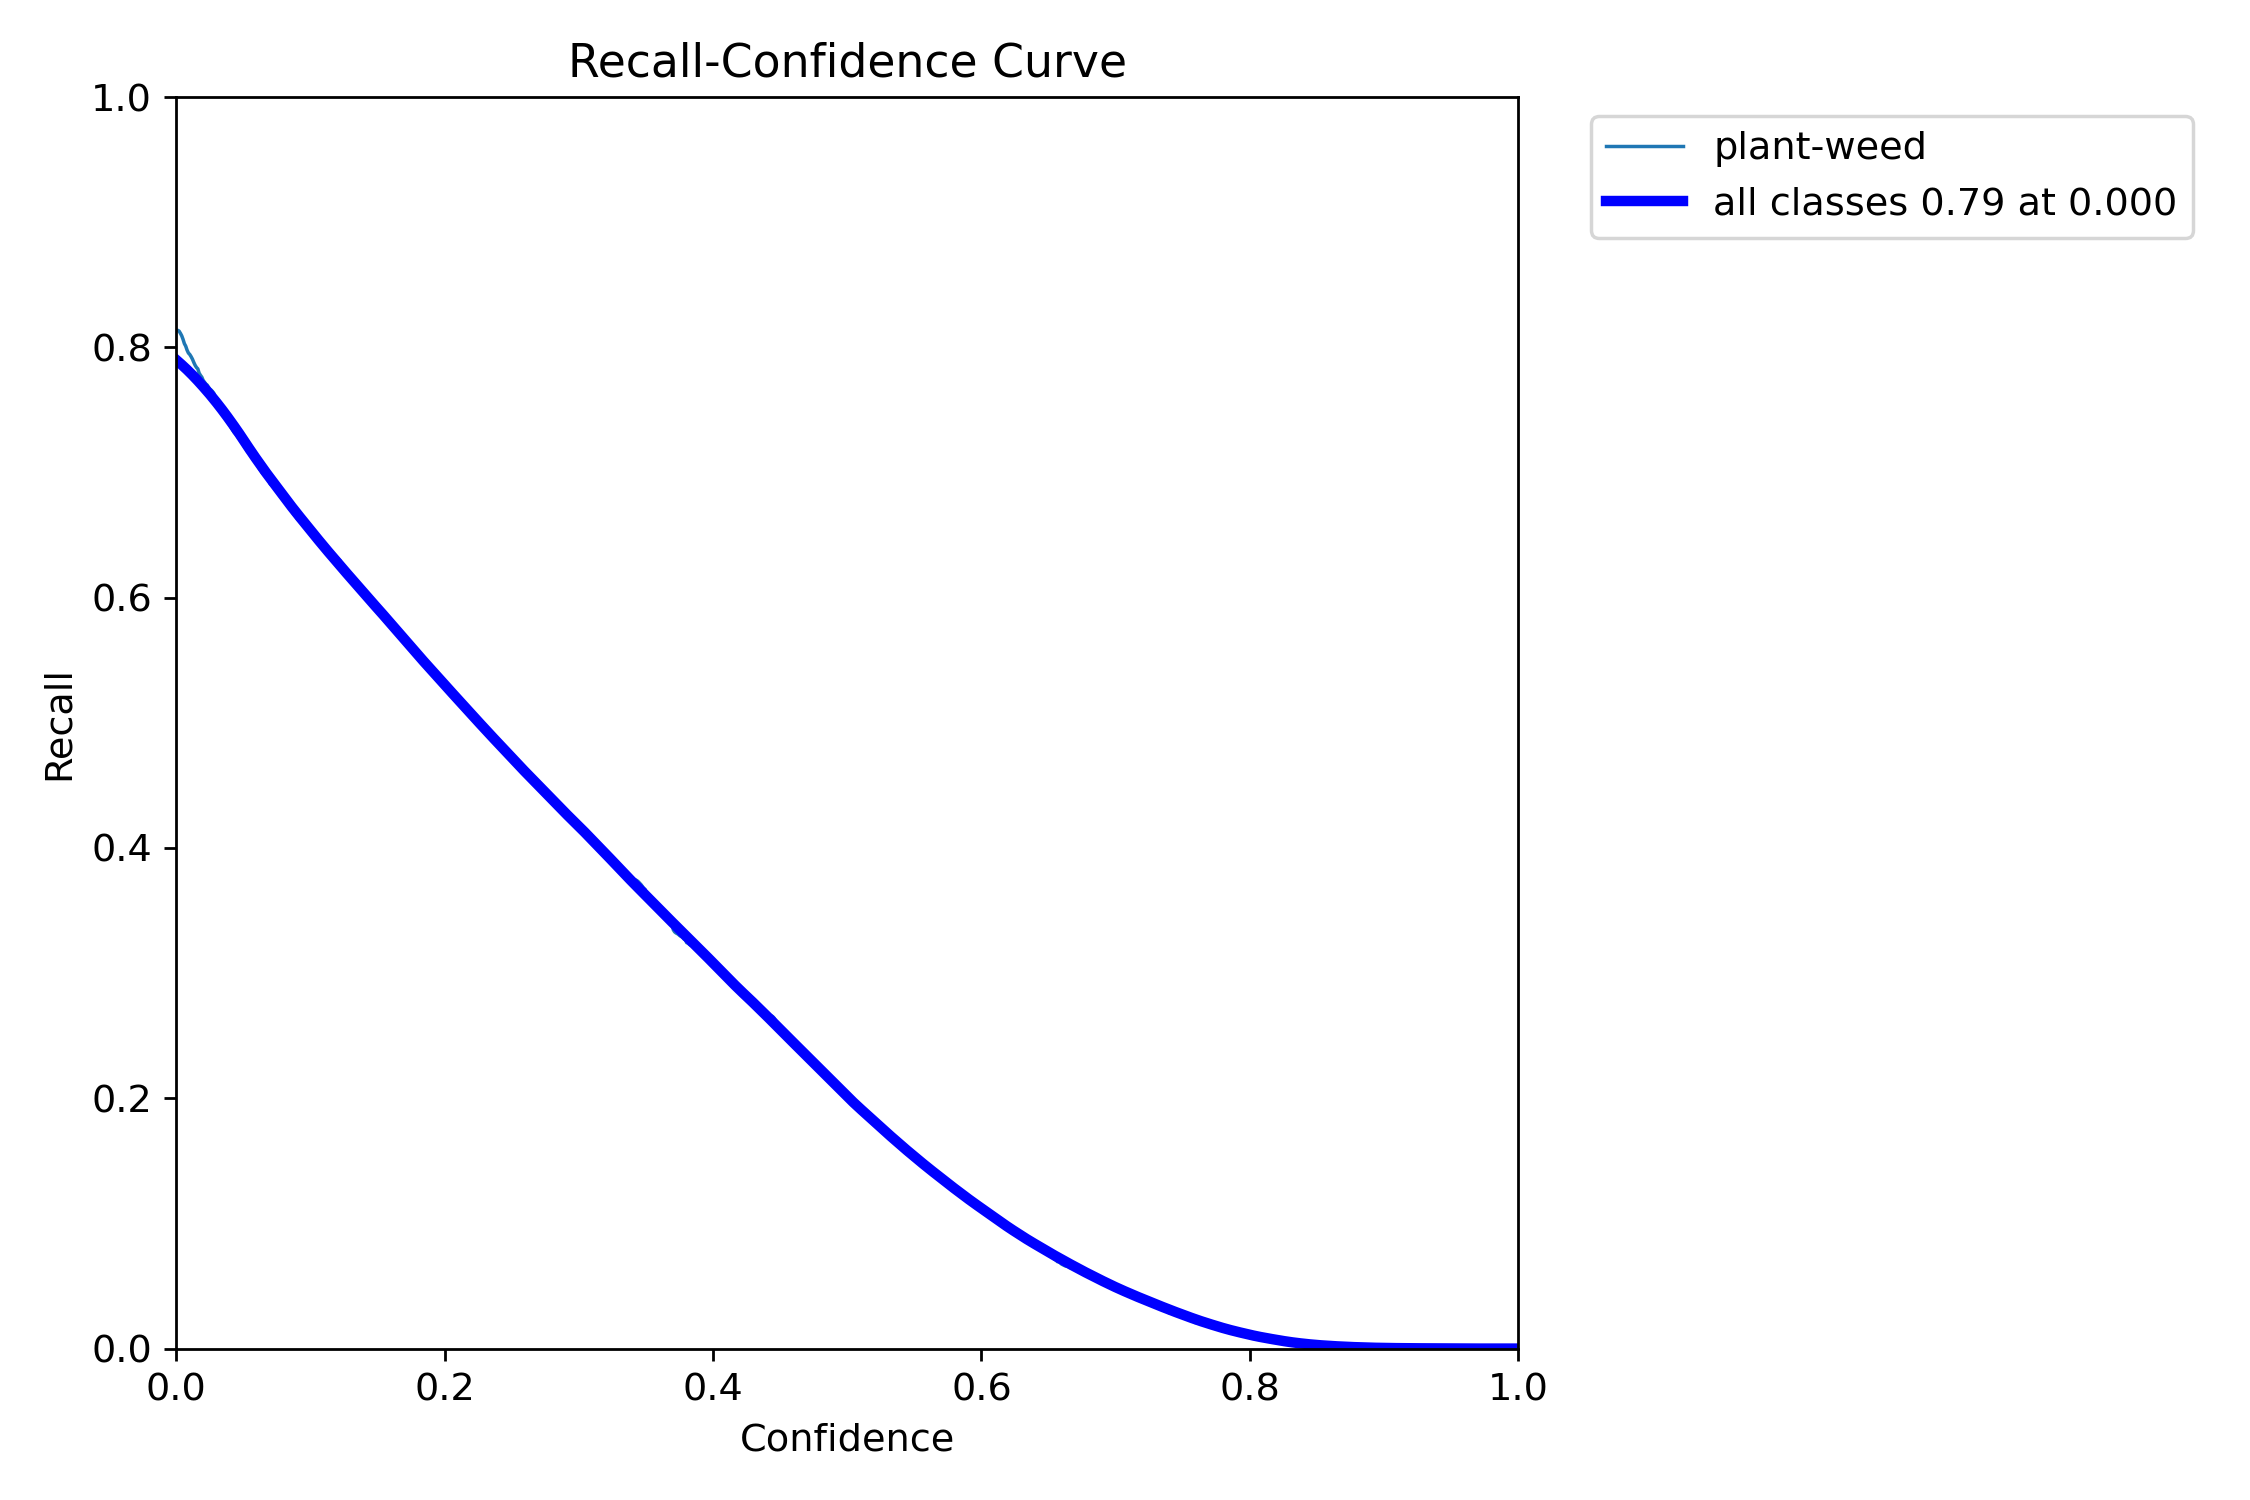

In [27]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

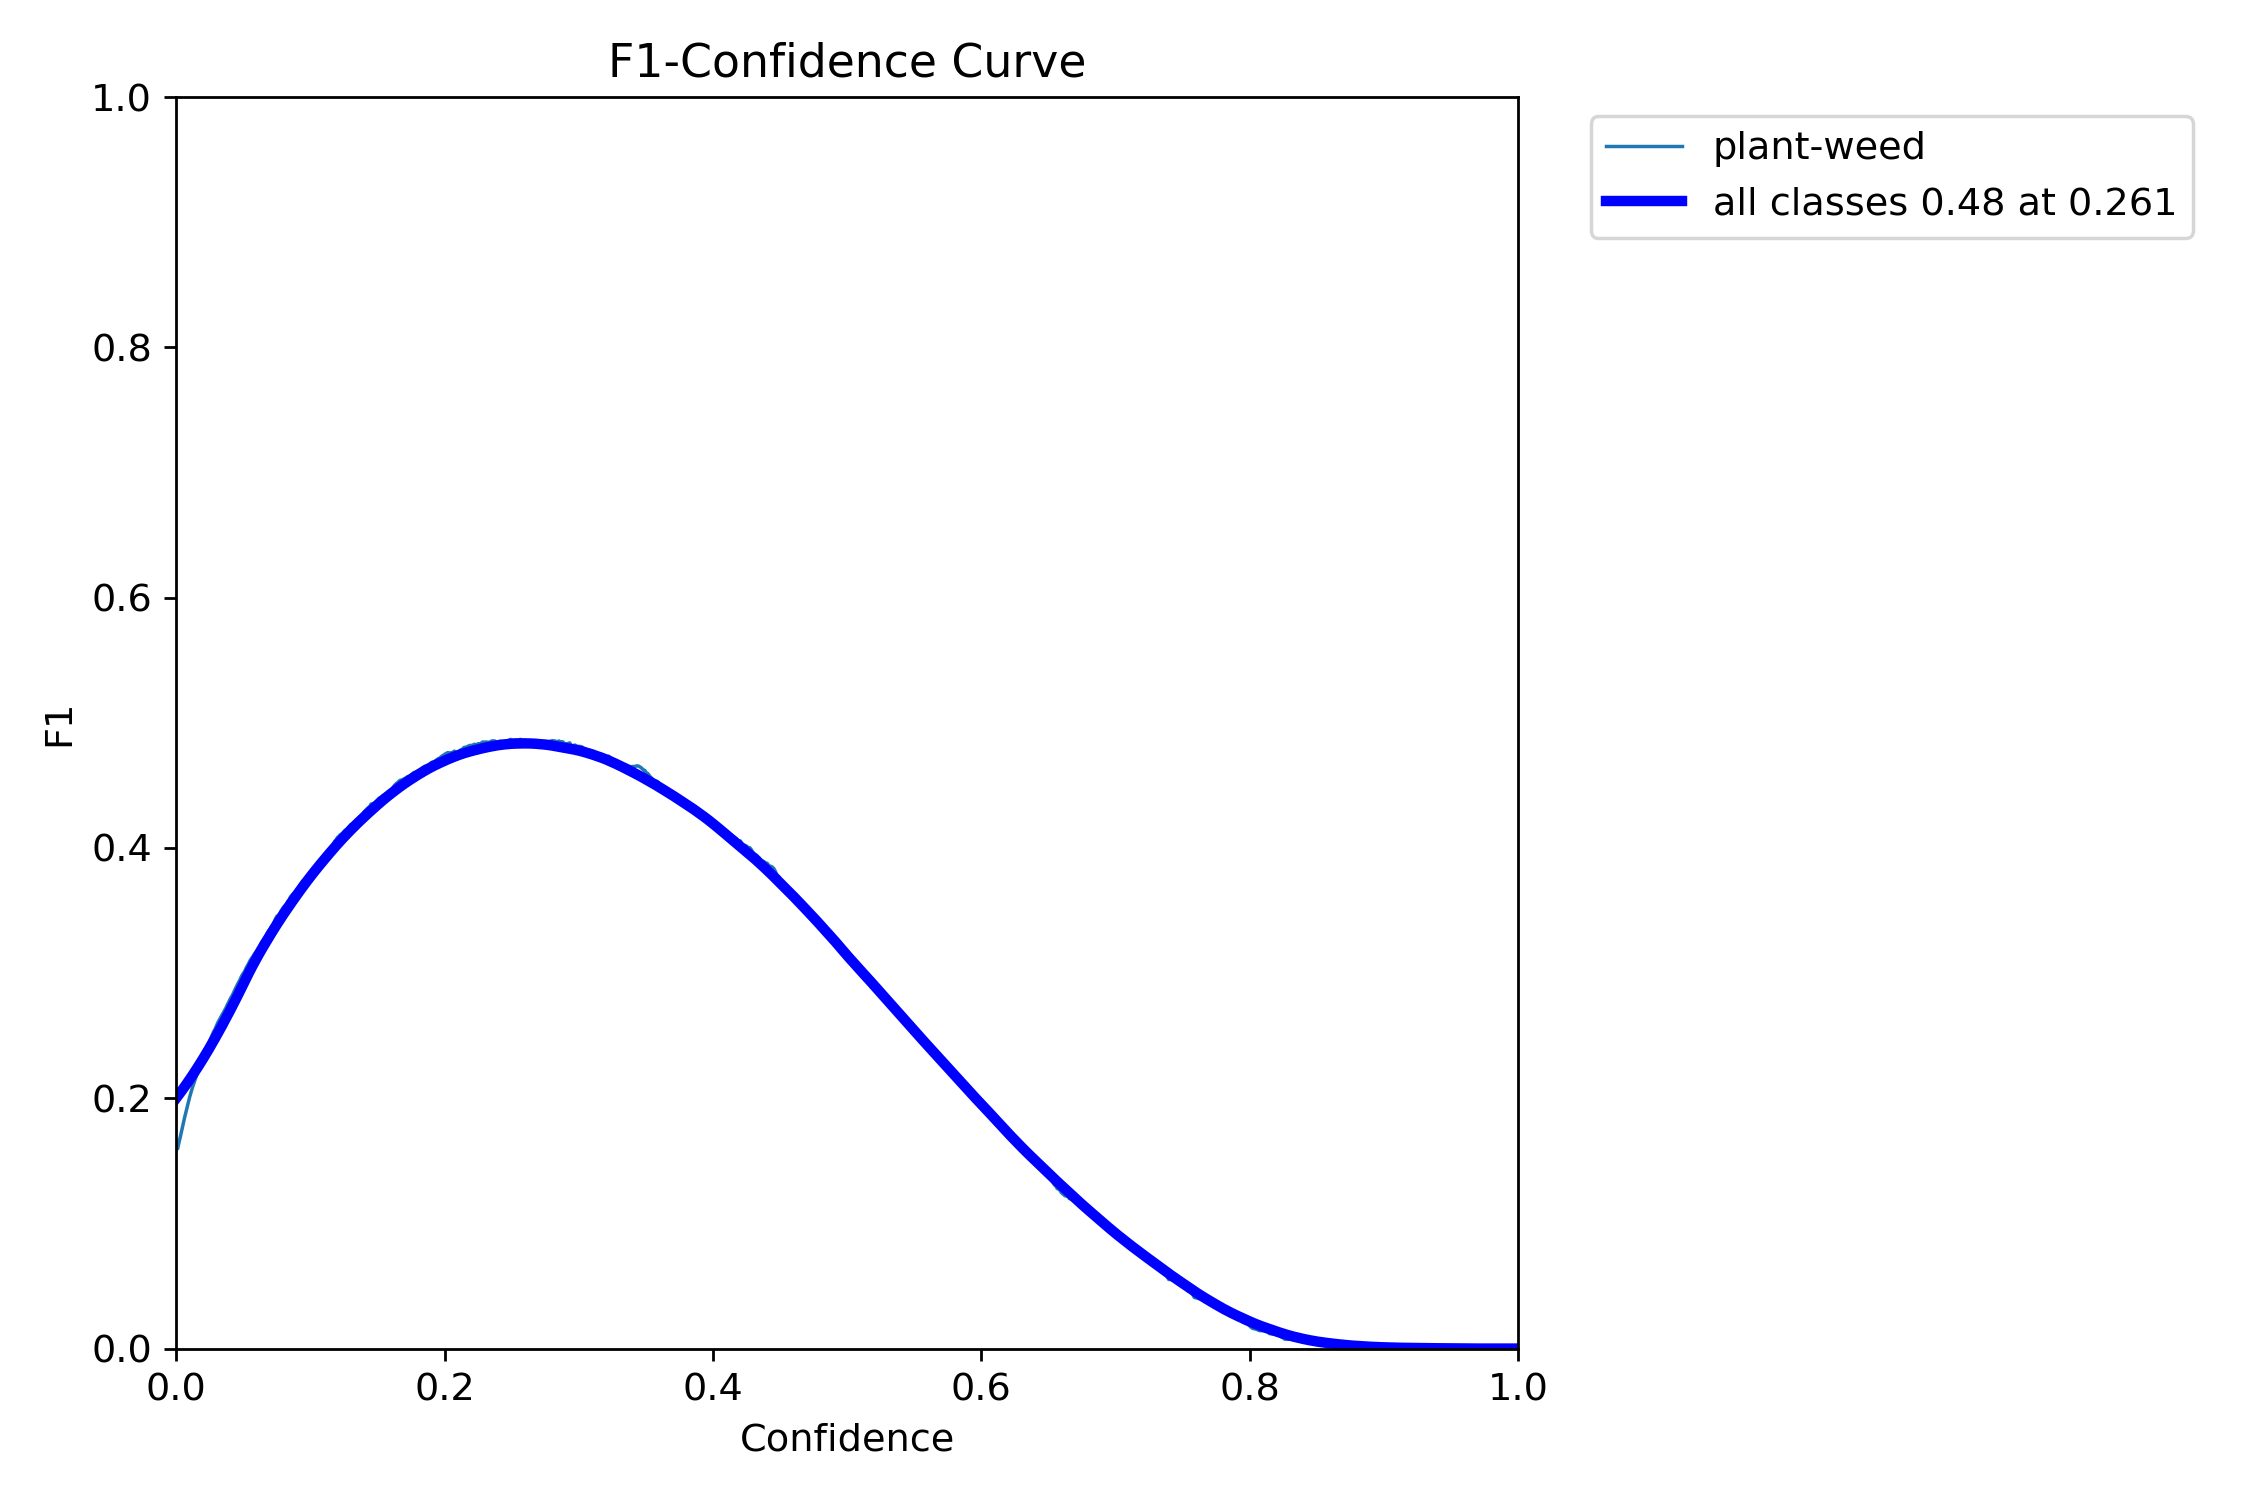

In [28]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

El valor de confianza que optimiza la precisión y recall es 0.231. En la mayoría de los casos, una mayor confianza es deseable.

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

## Experiment 53
### *YOLOv8 Mid | False color images*
Applying CLAHE preprocessing

In [29]:
folder = "train2/"

In [30]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df2 = pd.read_csv(file_path)
df = df2.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
225,226,3357.88,1.08575,0.59153,0.97657,0.50548,0.43548,0.38703,0.12417,2.72442,1.51367,2.23725,0.001081,0.001081,0.001081
226,227,3375.75,1.09466,0.60453,0.98319,0.50518,0.43116,0.39050,0.12245,2.76965,1.47296,2.26377,0.001075,0.001075,0.001075
227,228,3394.29,1.08851,0.59701,0.95558,0.50665,0.43145,0.39286,0.12725,2.72503,1.47125,2.20066,0.001071,0.001071,0.001071
228,229,3407.19,1.07048,0.59140,0.95906,0.50245,0.41647,0.38410,0.12313,2.76475,1.47845,2.25735,0.001067,0.001067,0.001067
229,230,3425.12,1.05590,0.57436,0.94981,0.50266,0.41849,0.38030,0.12279,2.76569,1.49383,2.27550,0.001063,0.001063,0.001063


In [31]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 57.085 min


In [32]:
df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
29,30,472.054,2.04139,1.29324,1.39094,0.48374,0.46717,0.44181,0.14581,2.36342,1.53153,1.70635,0.001874,0.001874,0.001874


#### Best epoch

In [33]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
29,30,472.054,2.04139,1.29324,1.39094,0.48374,0.46717,0.44181,0.14581,2.36342,1.53153,1.70635,0.001874,0.001874,0.001874,57.085333


In [34]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 30 con mAP50 de 0.442


In [35]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [104]:
# Setting values from CM graph
TP = 1942
FP = 2026
FN = 1530

In [105]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 5498

Confusion matrix:
[ 35.32% , 36.85% ]
[ 27.83% , 0.00% ]

Metrics:
- Accuracy: 0.353
- Precision: 0.489
- Recall: 0.559
- F1 Score: 0.522
- F½ Score: 0.502
- G-mean: 0.523


### Graphs

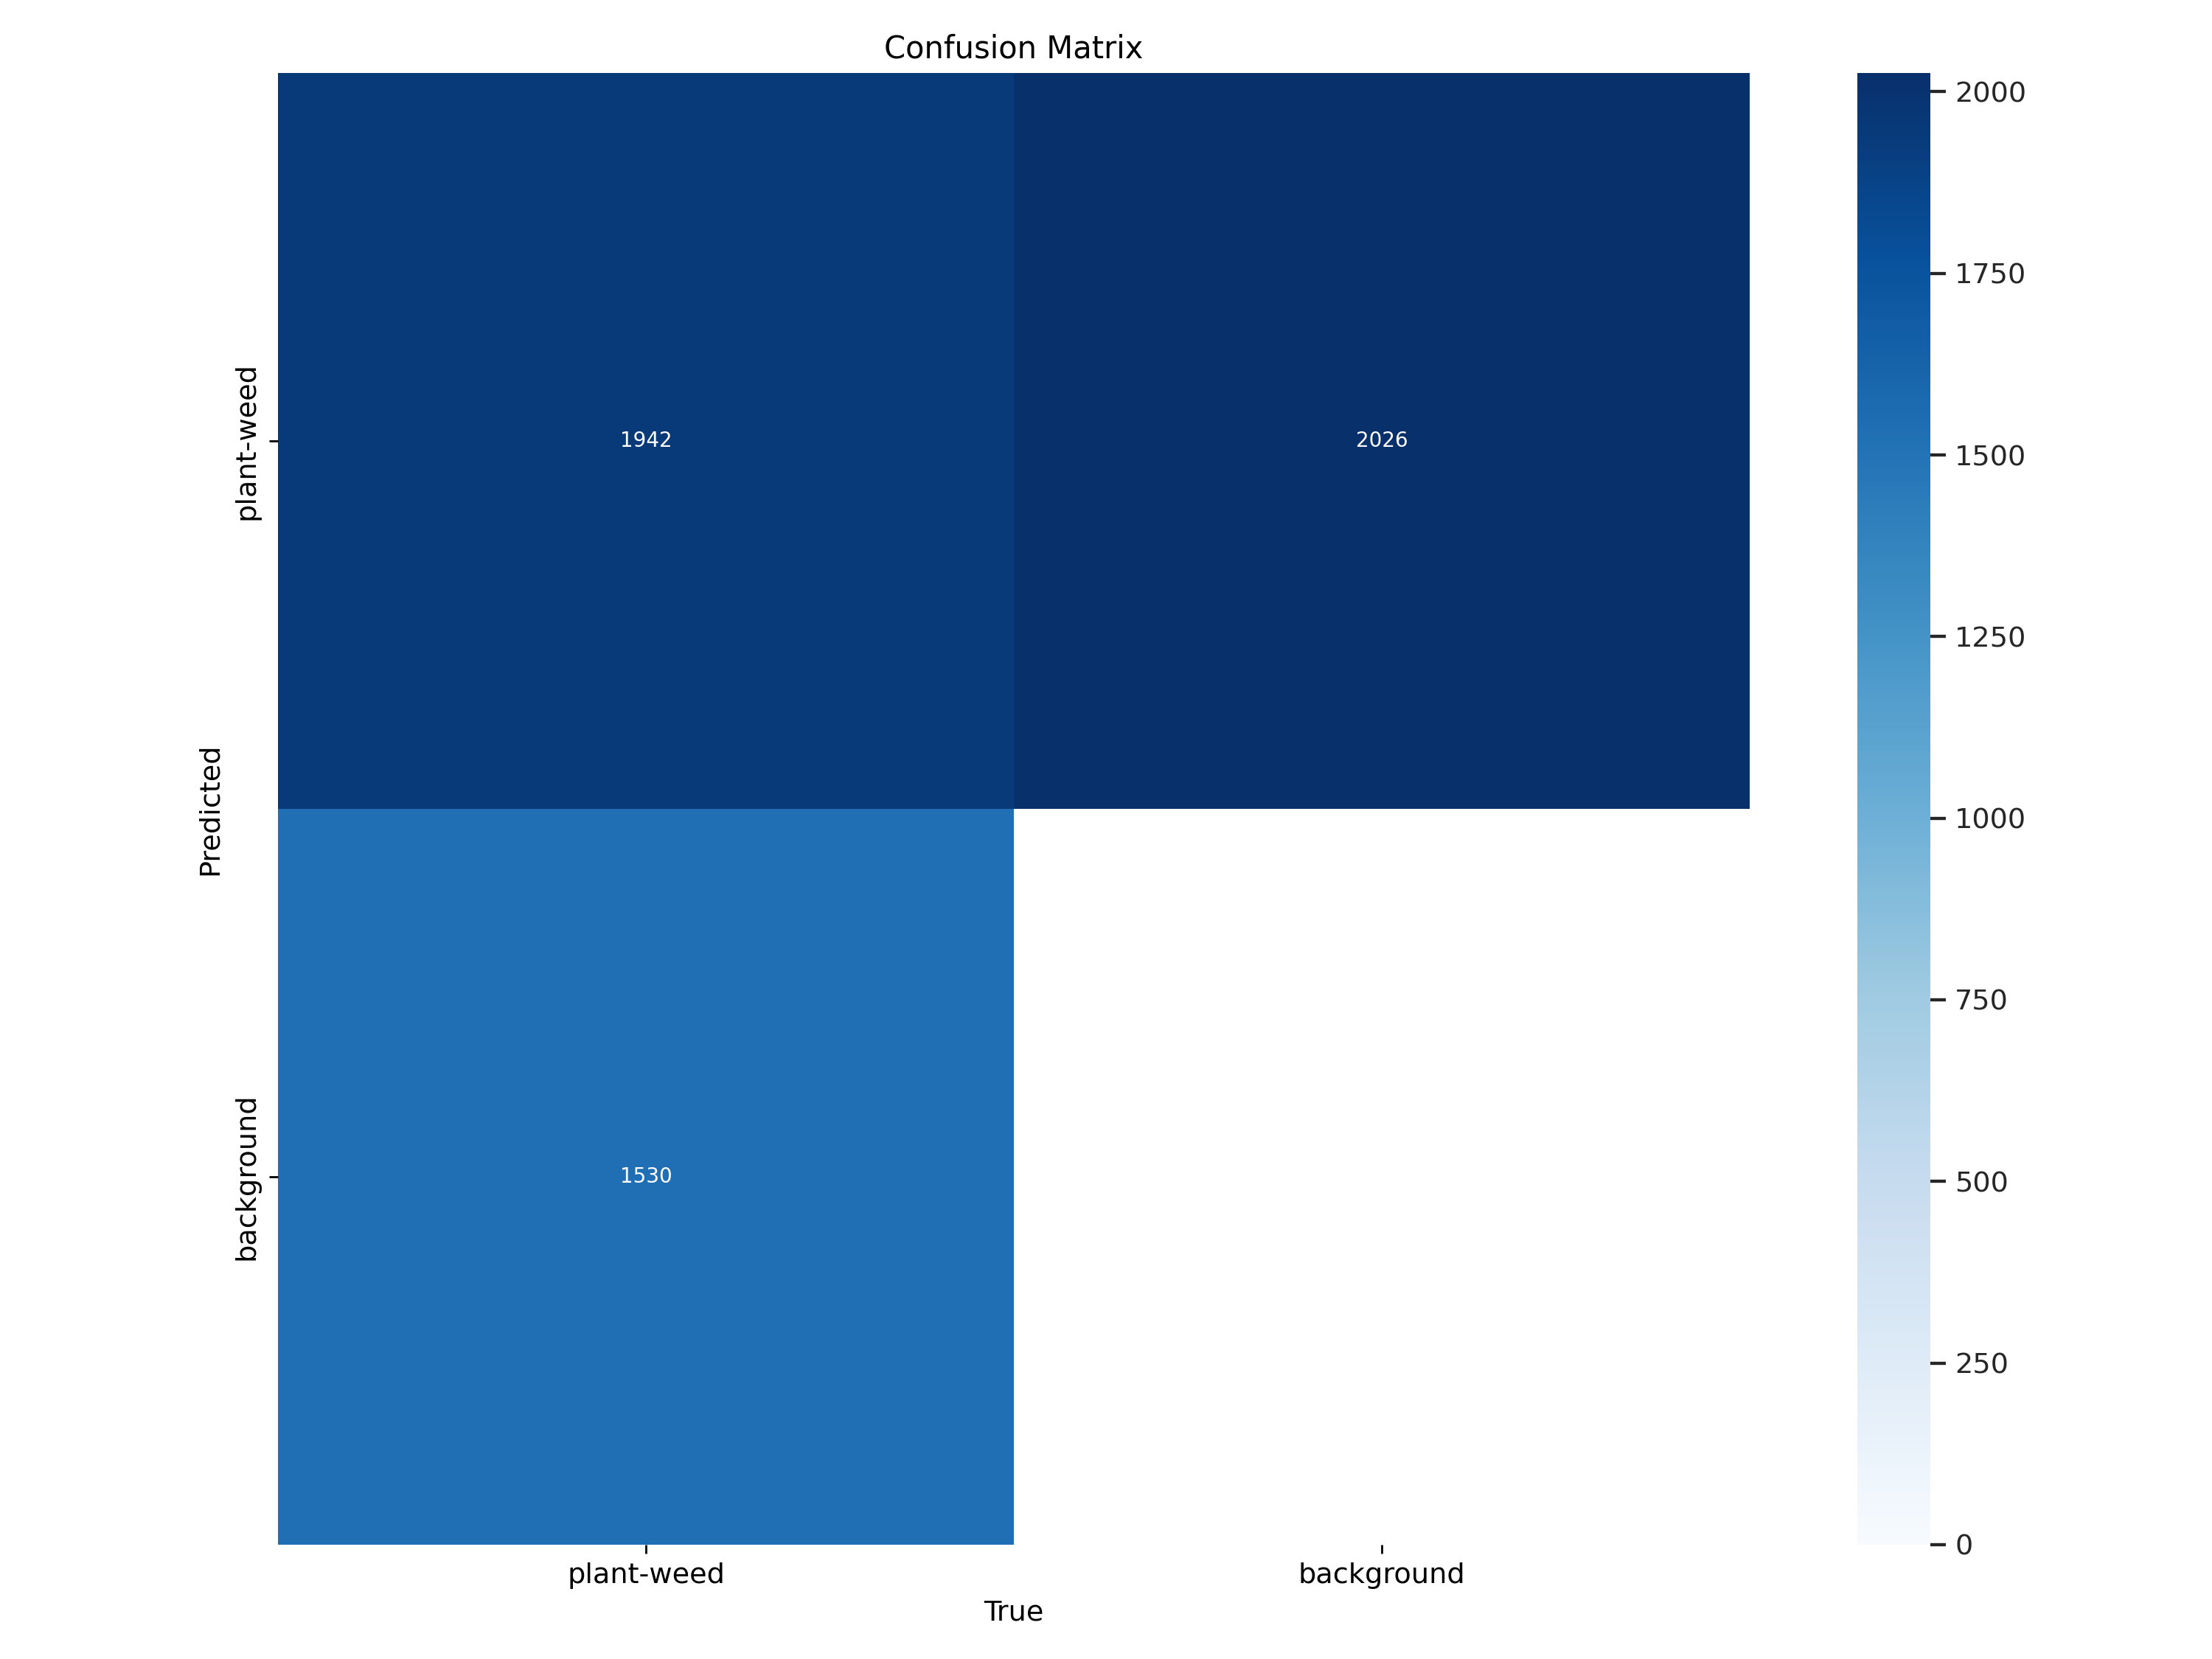

In [38]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

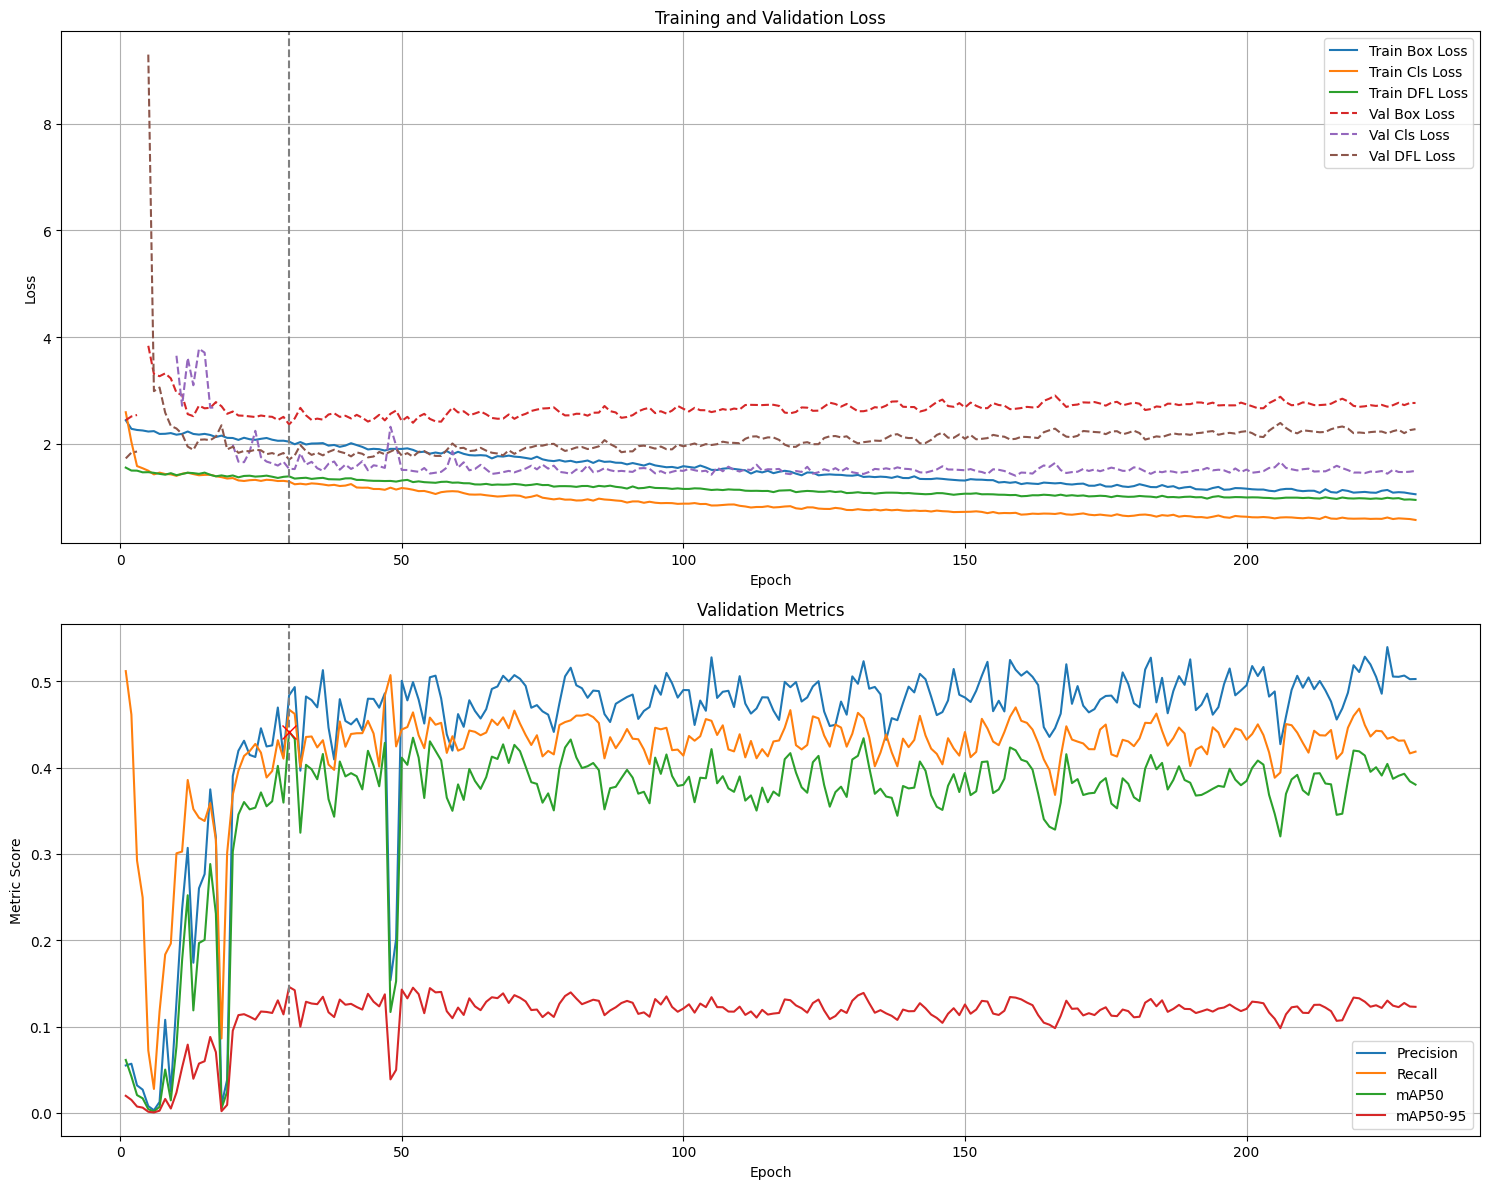

In [39]:
graph_training_metrics(df, epoch, graph="full")

In [40]:
graph_LrLoss_3D(df)

Validation set


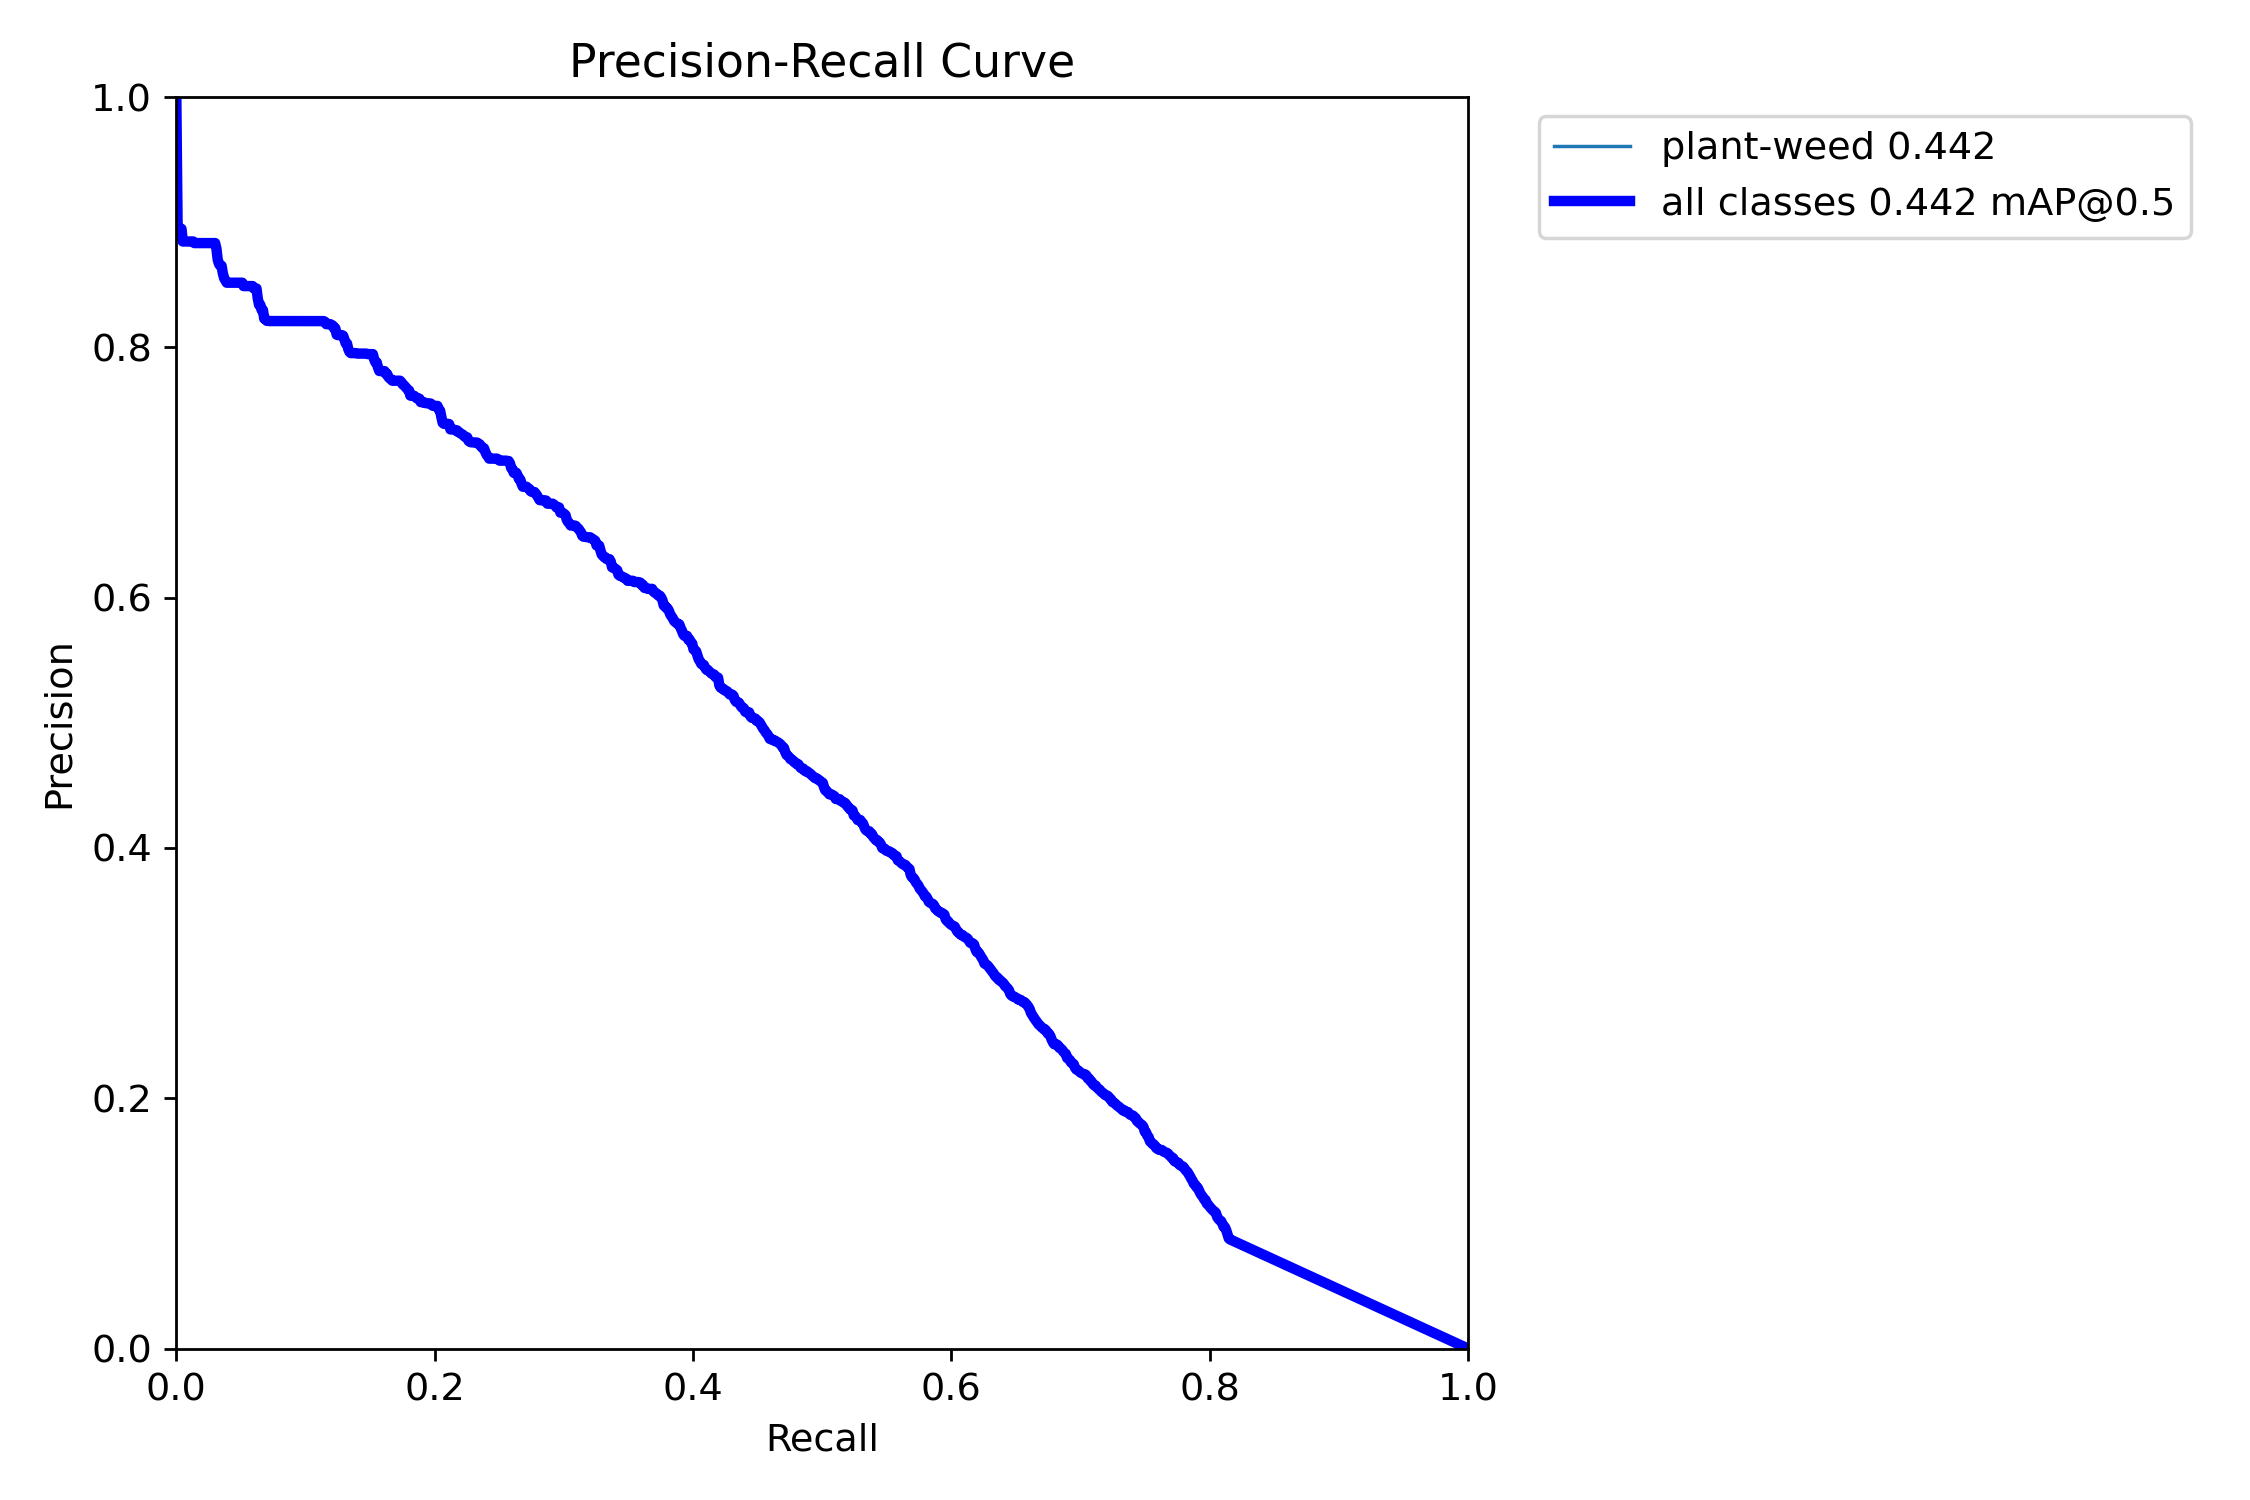

In [41]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

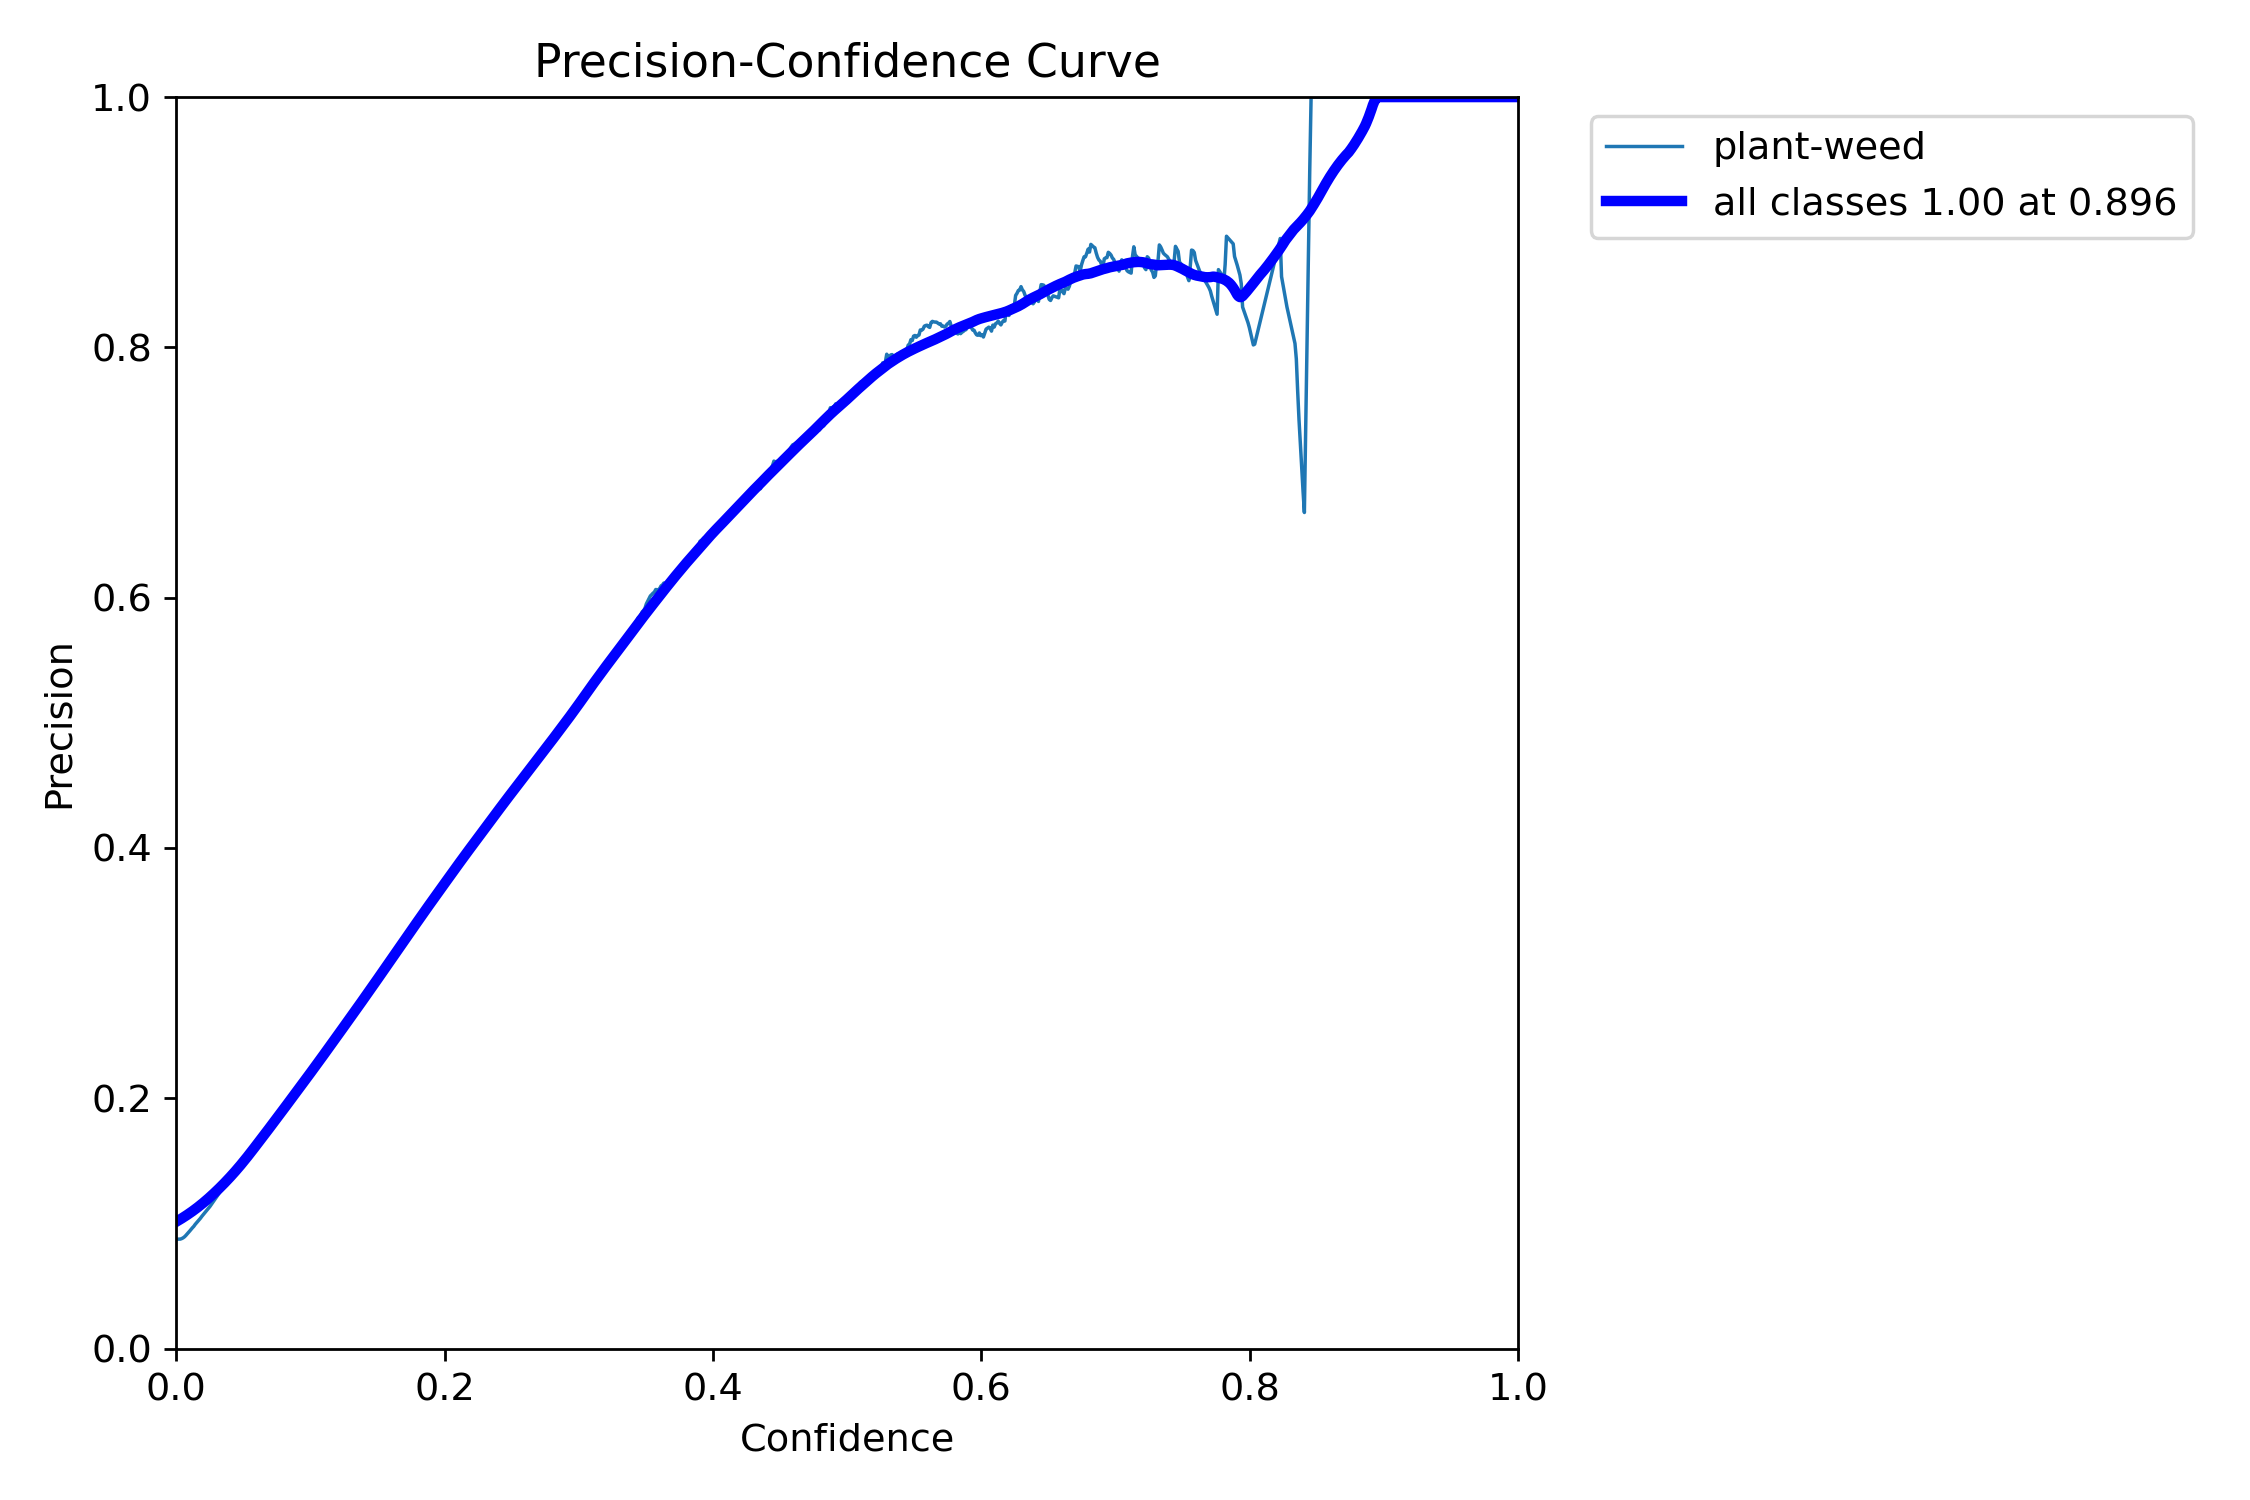

In [42]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

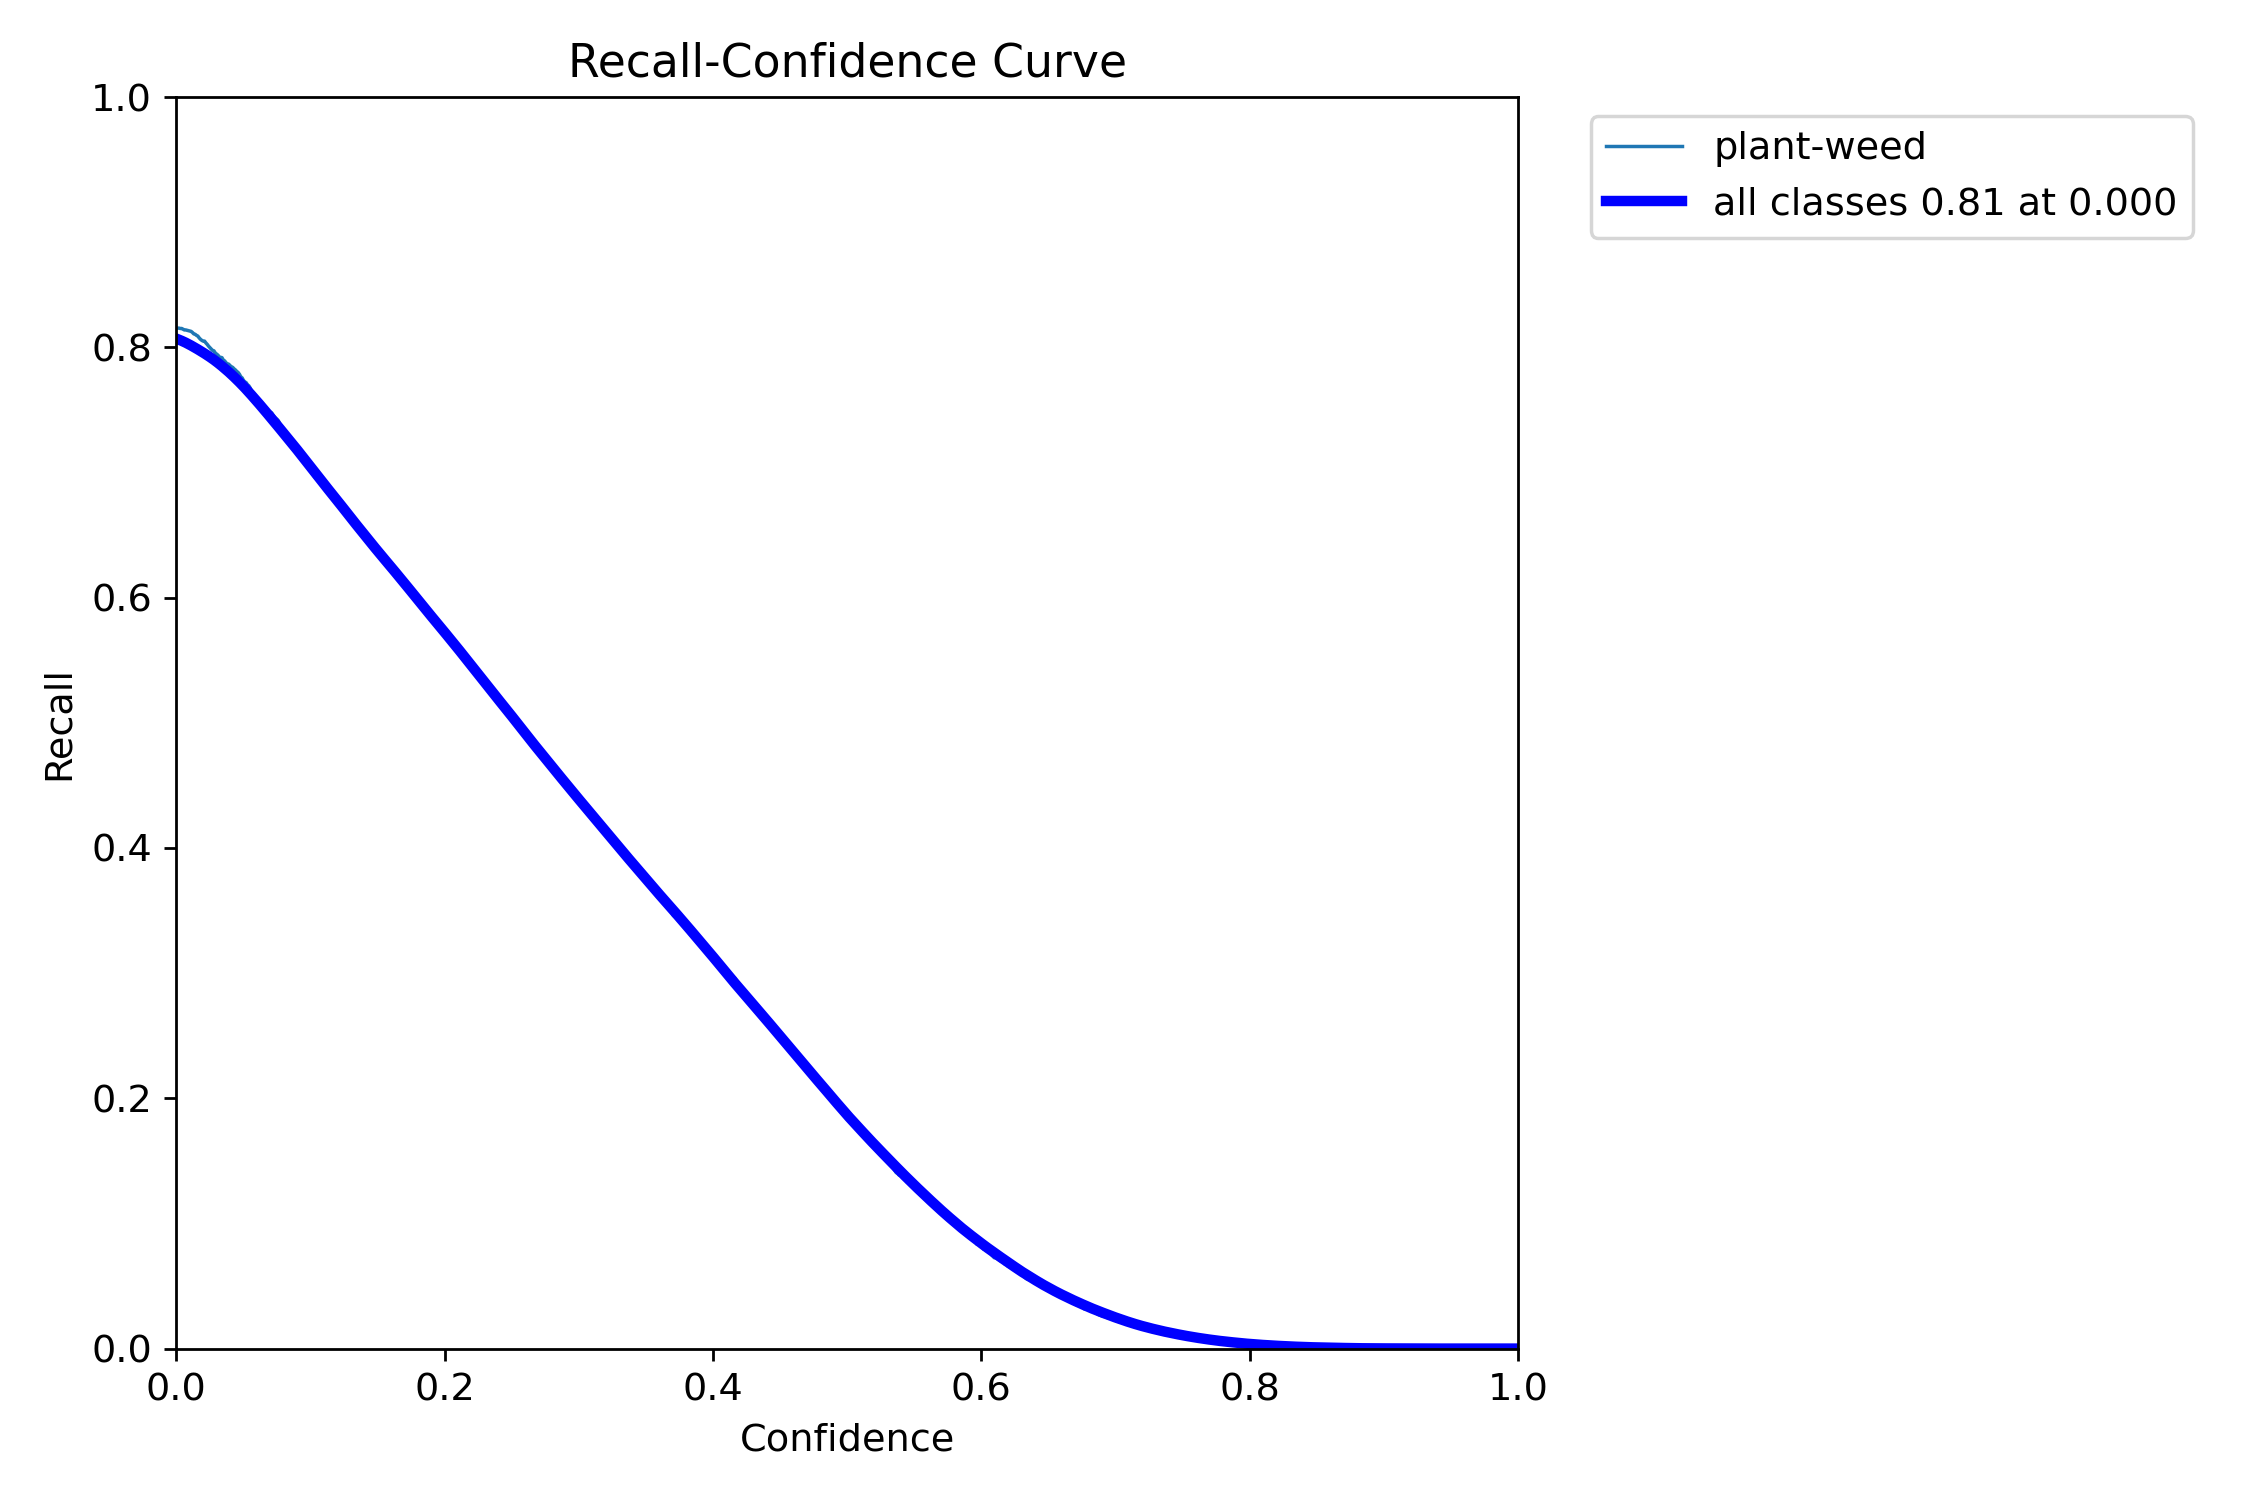

In [43]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

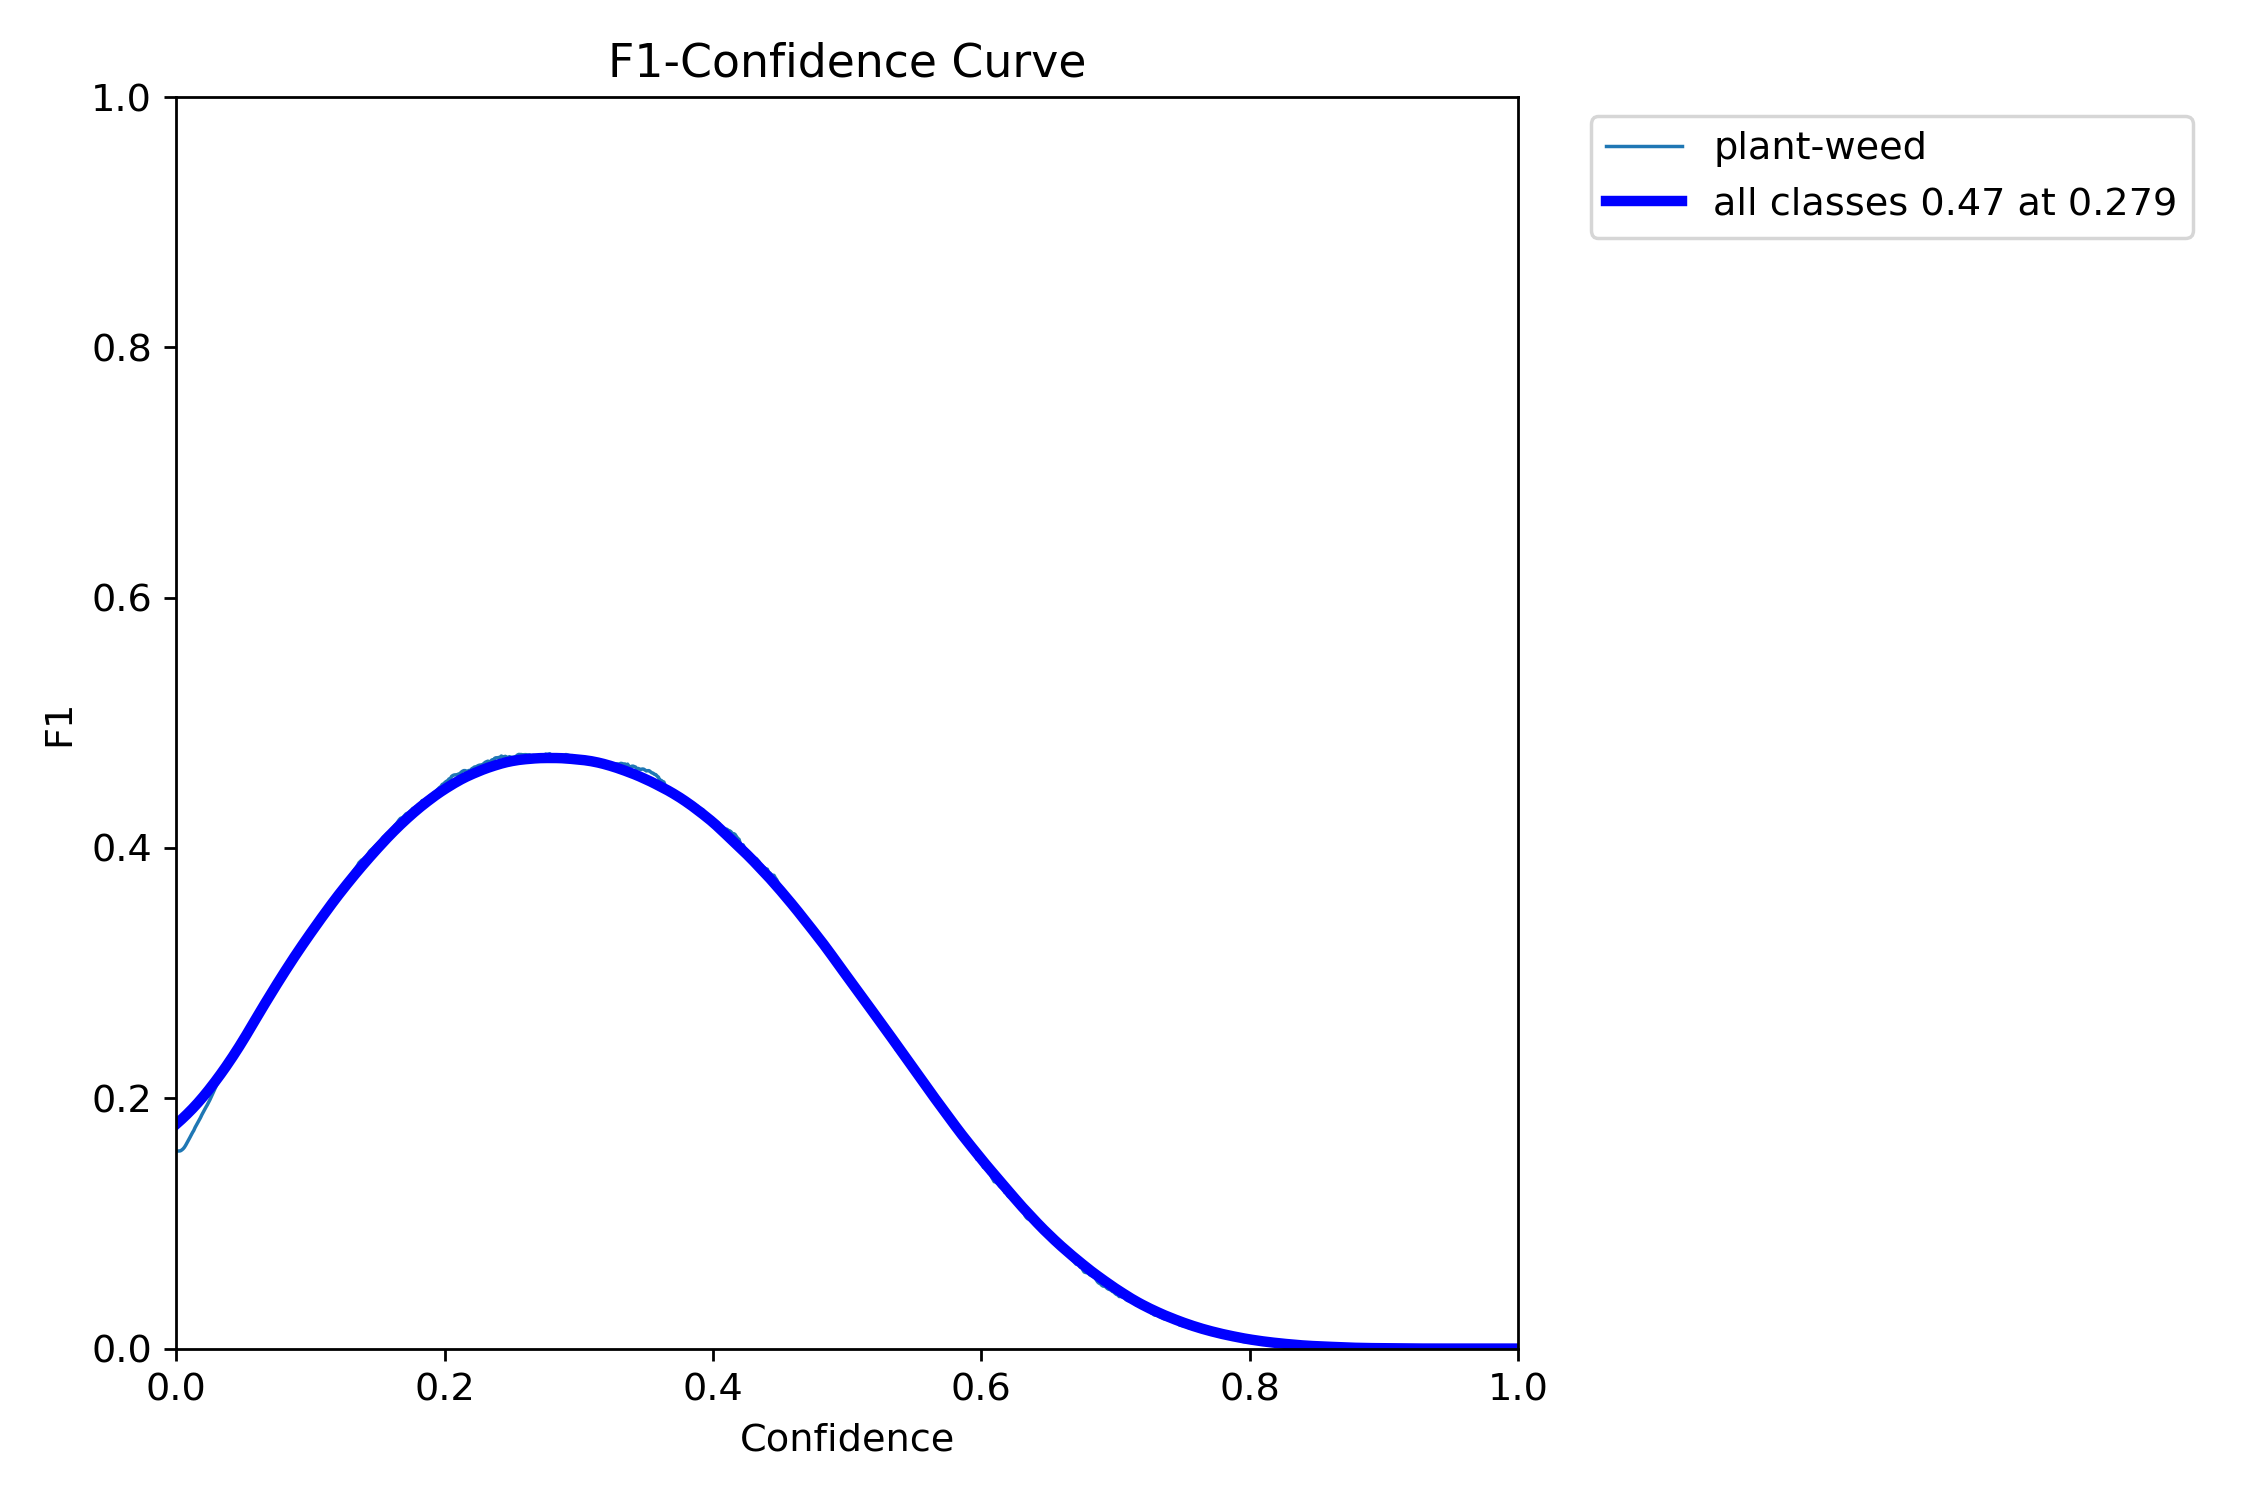

In [44]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

## Experiment 54
### *YOLOv8 Mid | False color images +  NO pretrain*
Random init for YOLO weights

In [45]:
folder = "train3/"

In [46]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df3 = pd.read_csv(file_path)
df = df3.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
448,449,5243.94,1.09643,0.59739,1.01687,0.47642,0.43952,0.38757,0.12067,2.75094,1.41522,2.31140,0.000562,0.000562,0.000562
449,450,5255.75,1.11454,0.58826,1.02694,0.49337,0.42079,0.38423,0.11896,2.76749,1.41298,2.32406,0.000559,0.000559,0.000559
450,451,5267.85,1.08343,0.58594,1.00753,0.49113,0.41158,0.37869,0.11703,2.76744,1.43547,2.30898,0.000556,0.000556,0.000556
451,452,5279.31,1.08123,0.58958,1.02459,0.50034,0.42454,0.39184,0.12303,2.74949,1.41961,2.29325,0.000553,0.000553,0.000553
452,453,5290.75,1.09933,0.59059,1.03334,0.47643,0.41647,0.37544,0.11723,2.76497,1.43226,2.30554,0.000549,0.000549,0.000549


In [47]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 88.179 min


In [48]:
df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
199,200,2360.98,1.73859,0.96404,1.3058,0.53938,0.47005,0.45095,0.14532,2.52551,1.3544,1.93694,0.001354,0.001354,0.001354


#### Best epoch

In [49]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
199,200,2360.98,1.73859,0.96404,1.3058,0.53938,0.47005,0.45095,0.14532,2.52551,1.3544,1.93694,0.001354,0.001354,0.001354,88.179167


In [50]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 200 con mAP50 de 0.451


In [51]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [102]:
# Setting values from CM graph
TP = 1838
FP = 1403
FN = 1634

In [103]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 4875

Confusion matrix:
[ 37.70% , 28.78% ]
[ 33.52% , 0.00% ]

Metrics:
- Accuracy: 0.377
- Precision: 0.567
- Recall: 0.529
- F1 Score: 0.548
- F½ Score: 0.559
- G-mean: 0.548


### Graphs

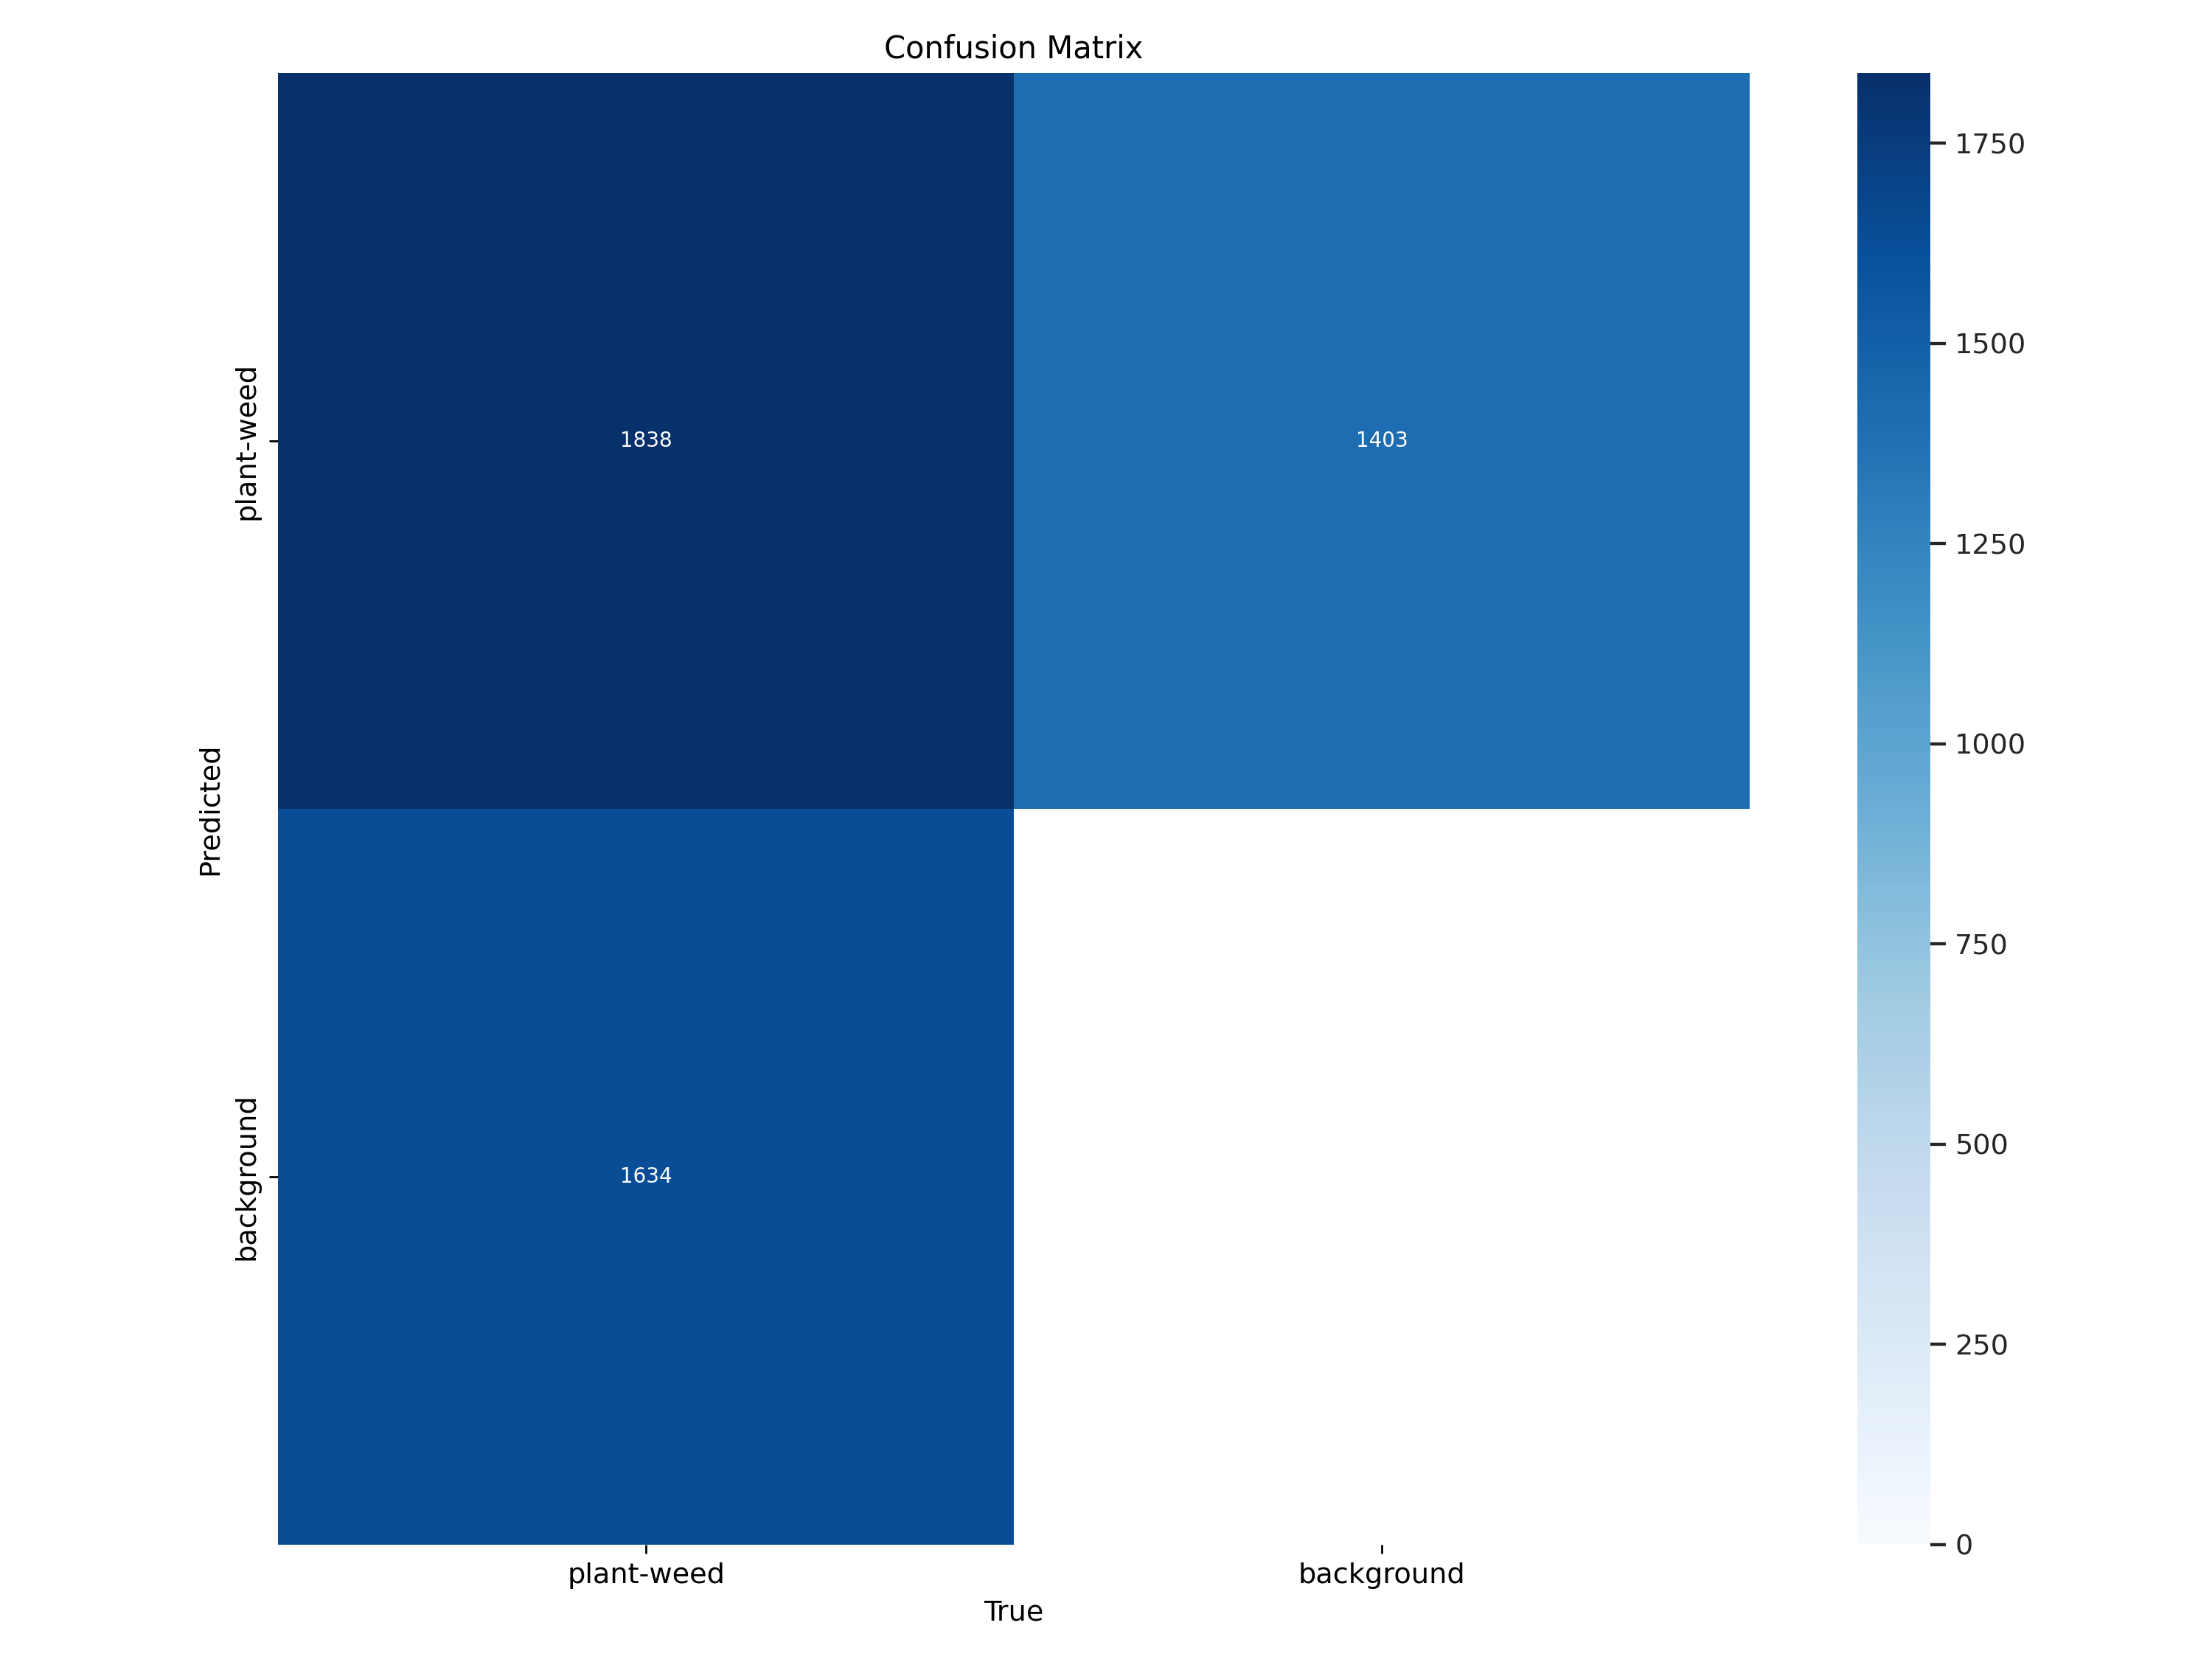

In [54]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

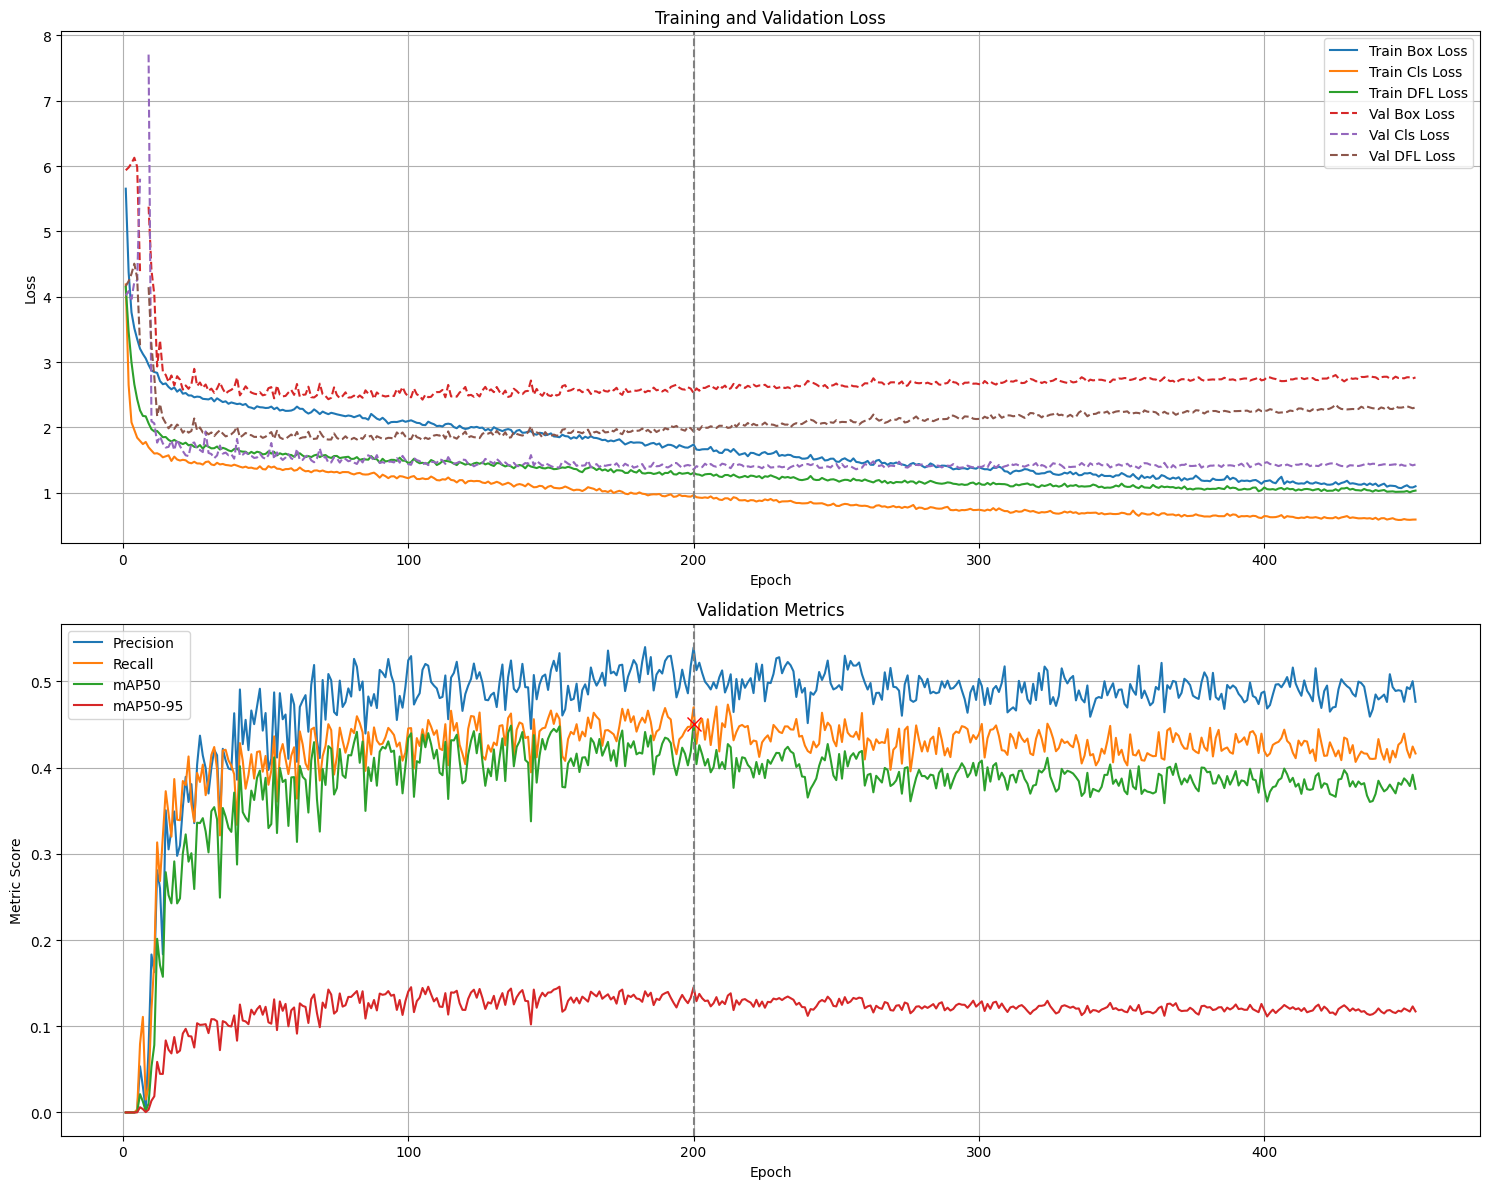

In [55]:
graph_training_metrics(df, epoch, graph="full")

In [56]:
graph_LrLoss_3D(df)

Validation set


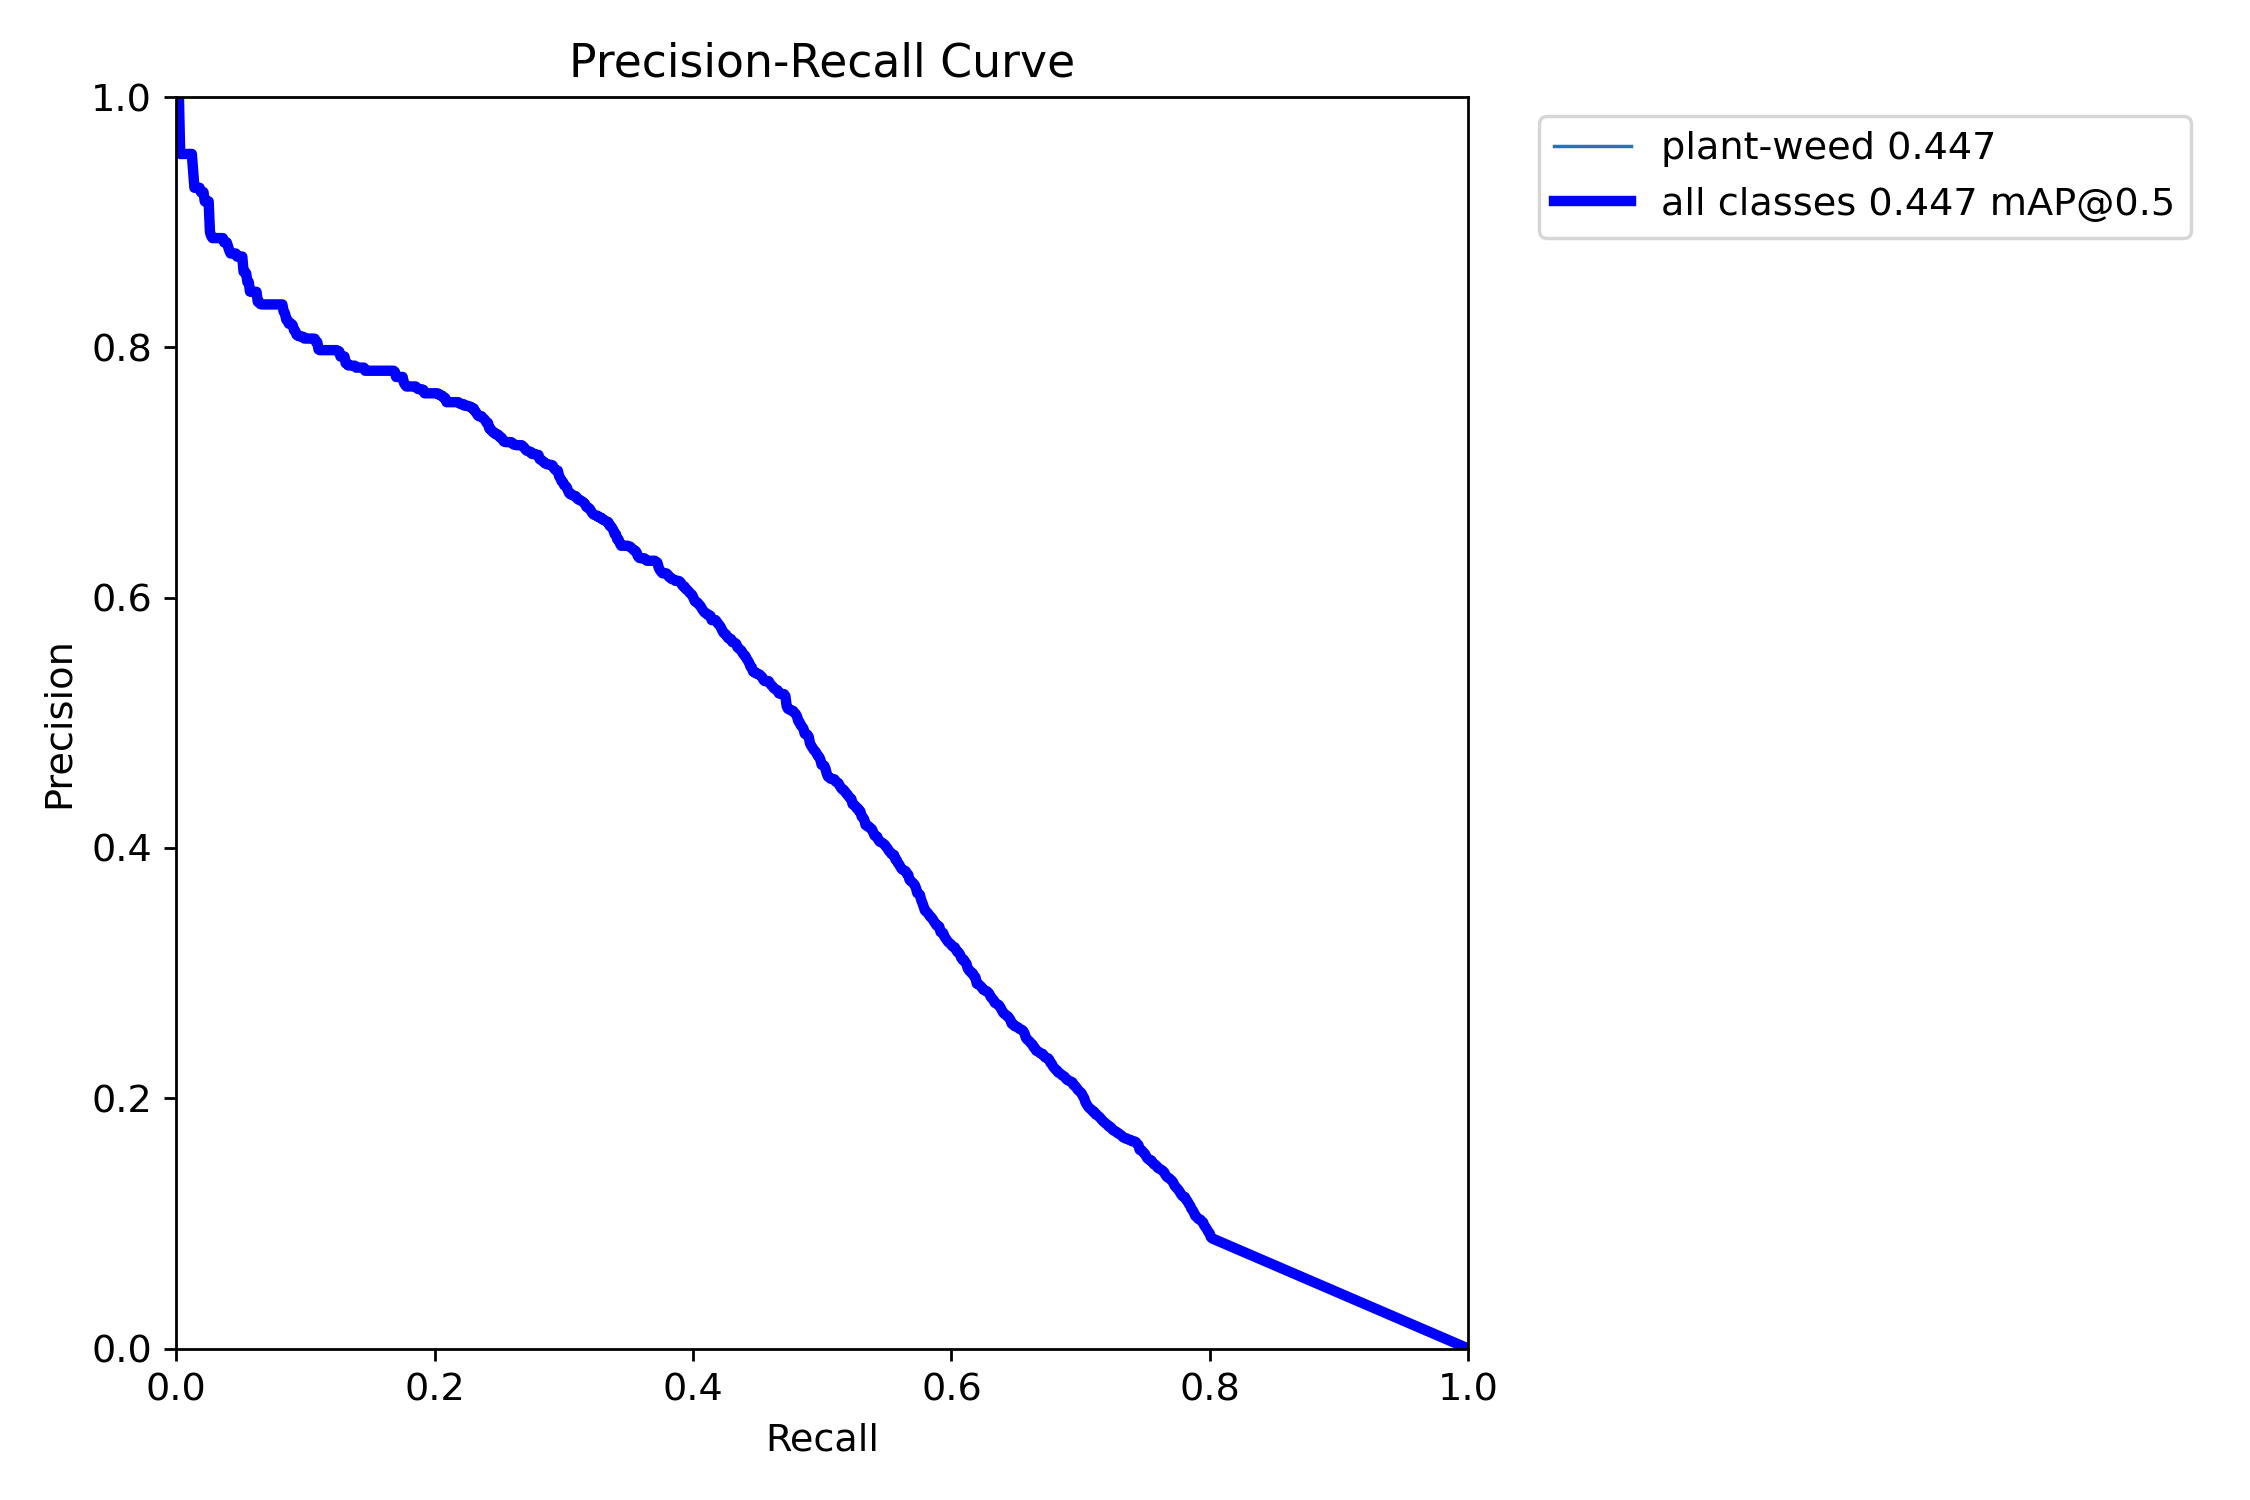

In [57]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

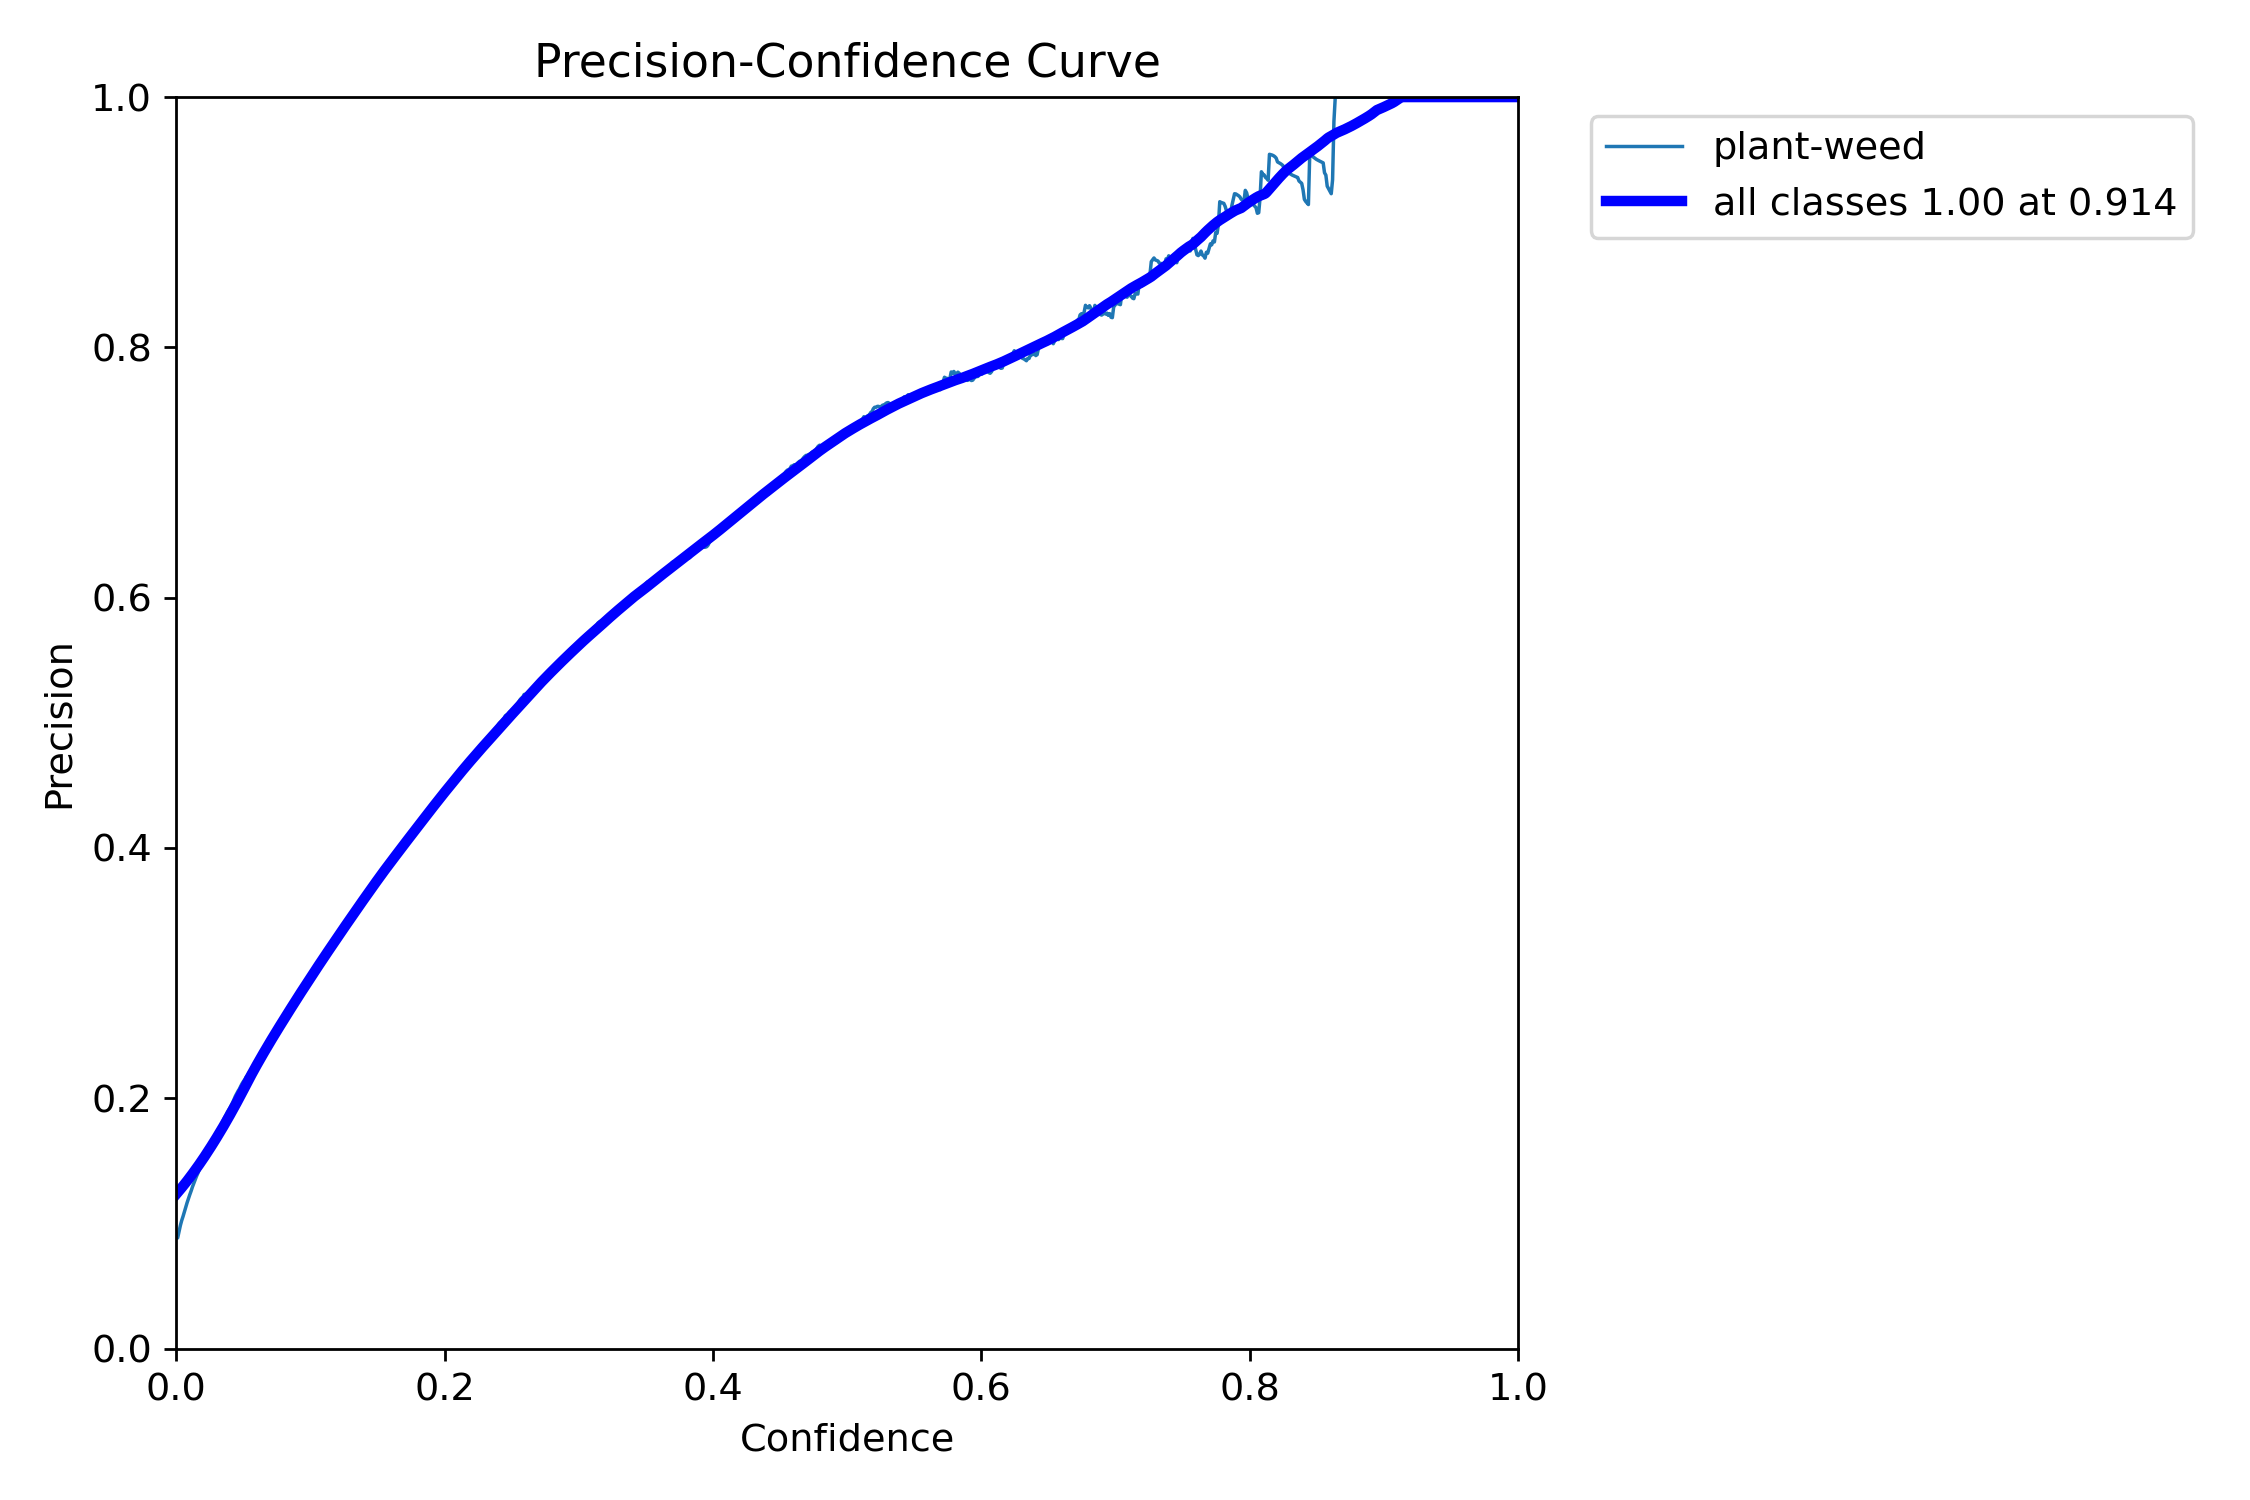

In [58]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

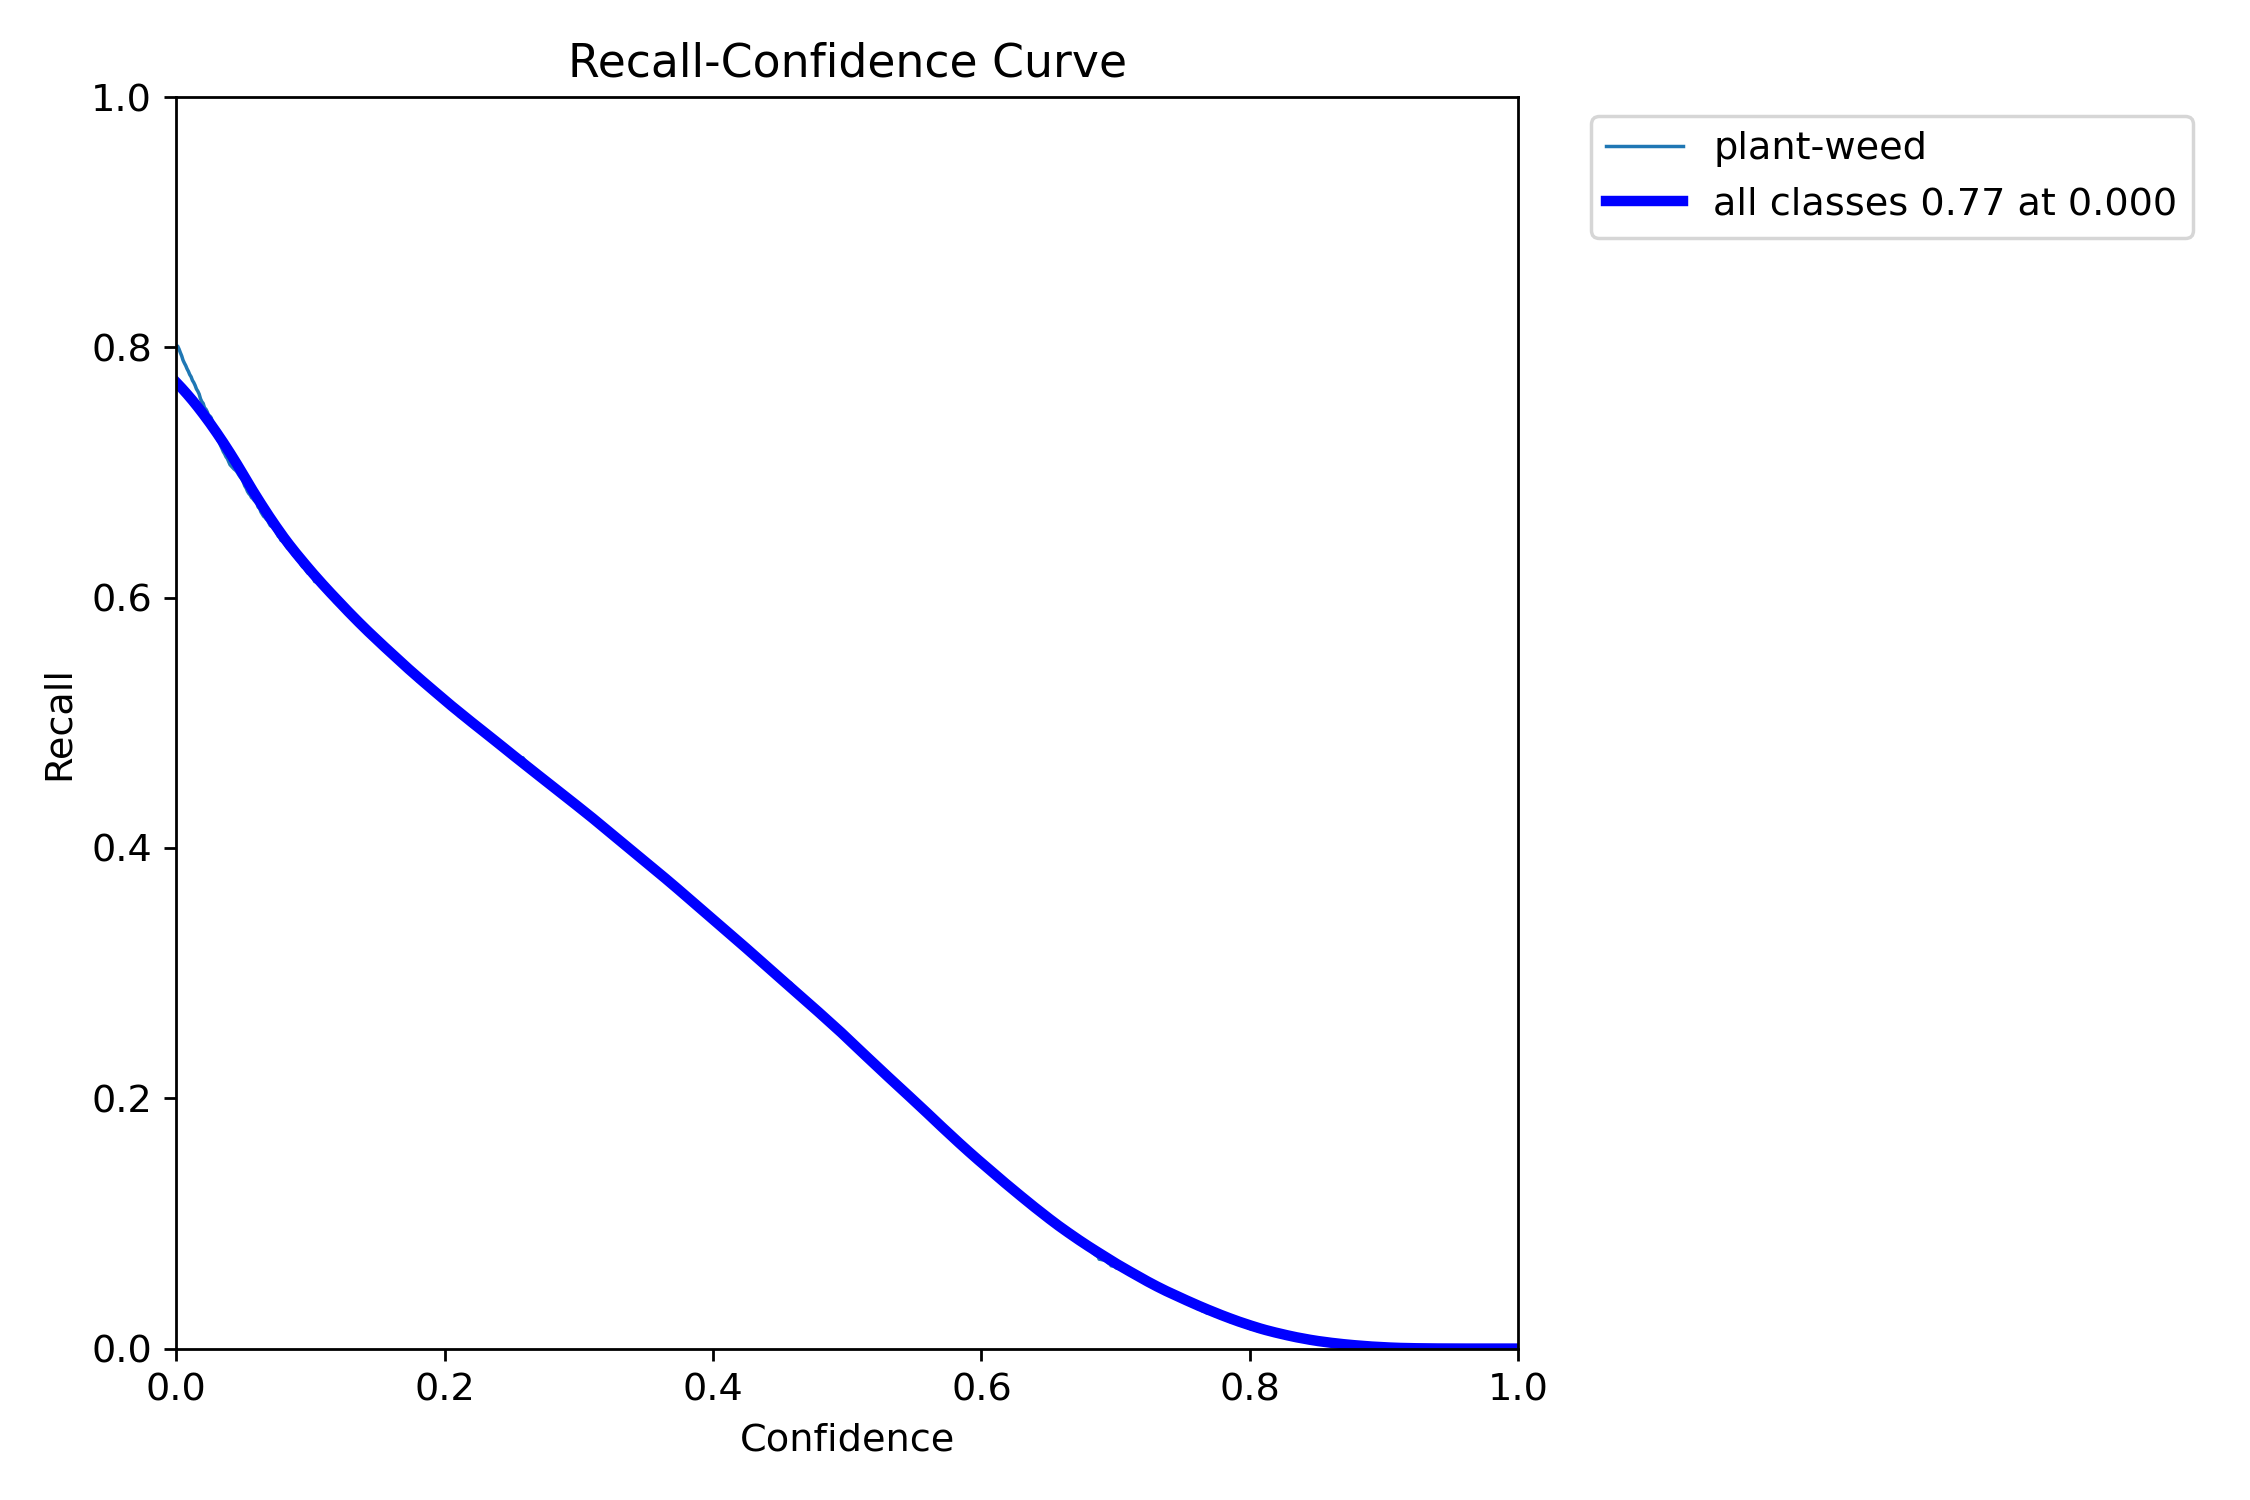

In [59]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

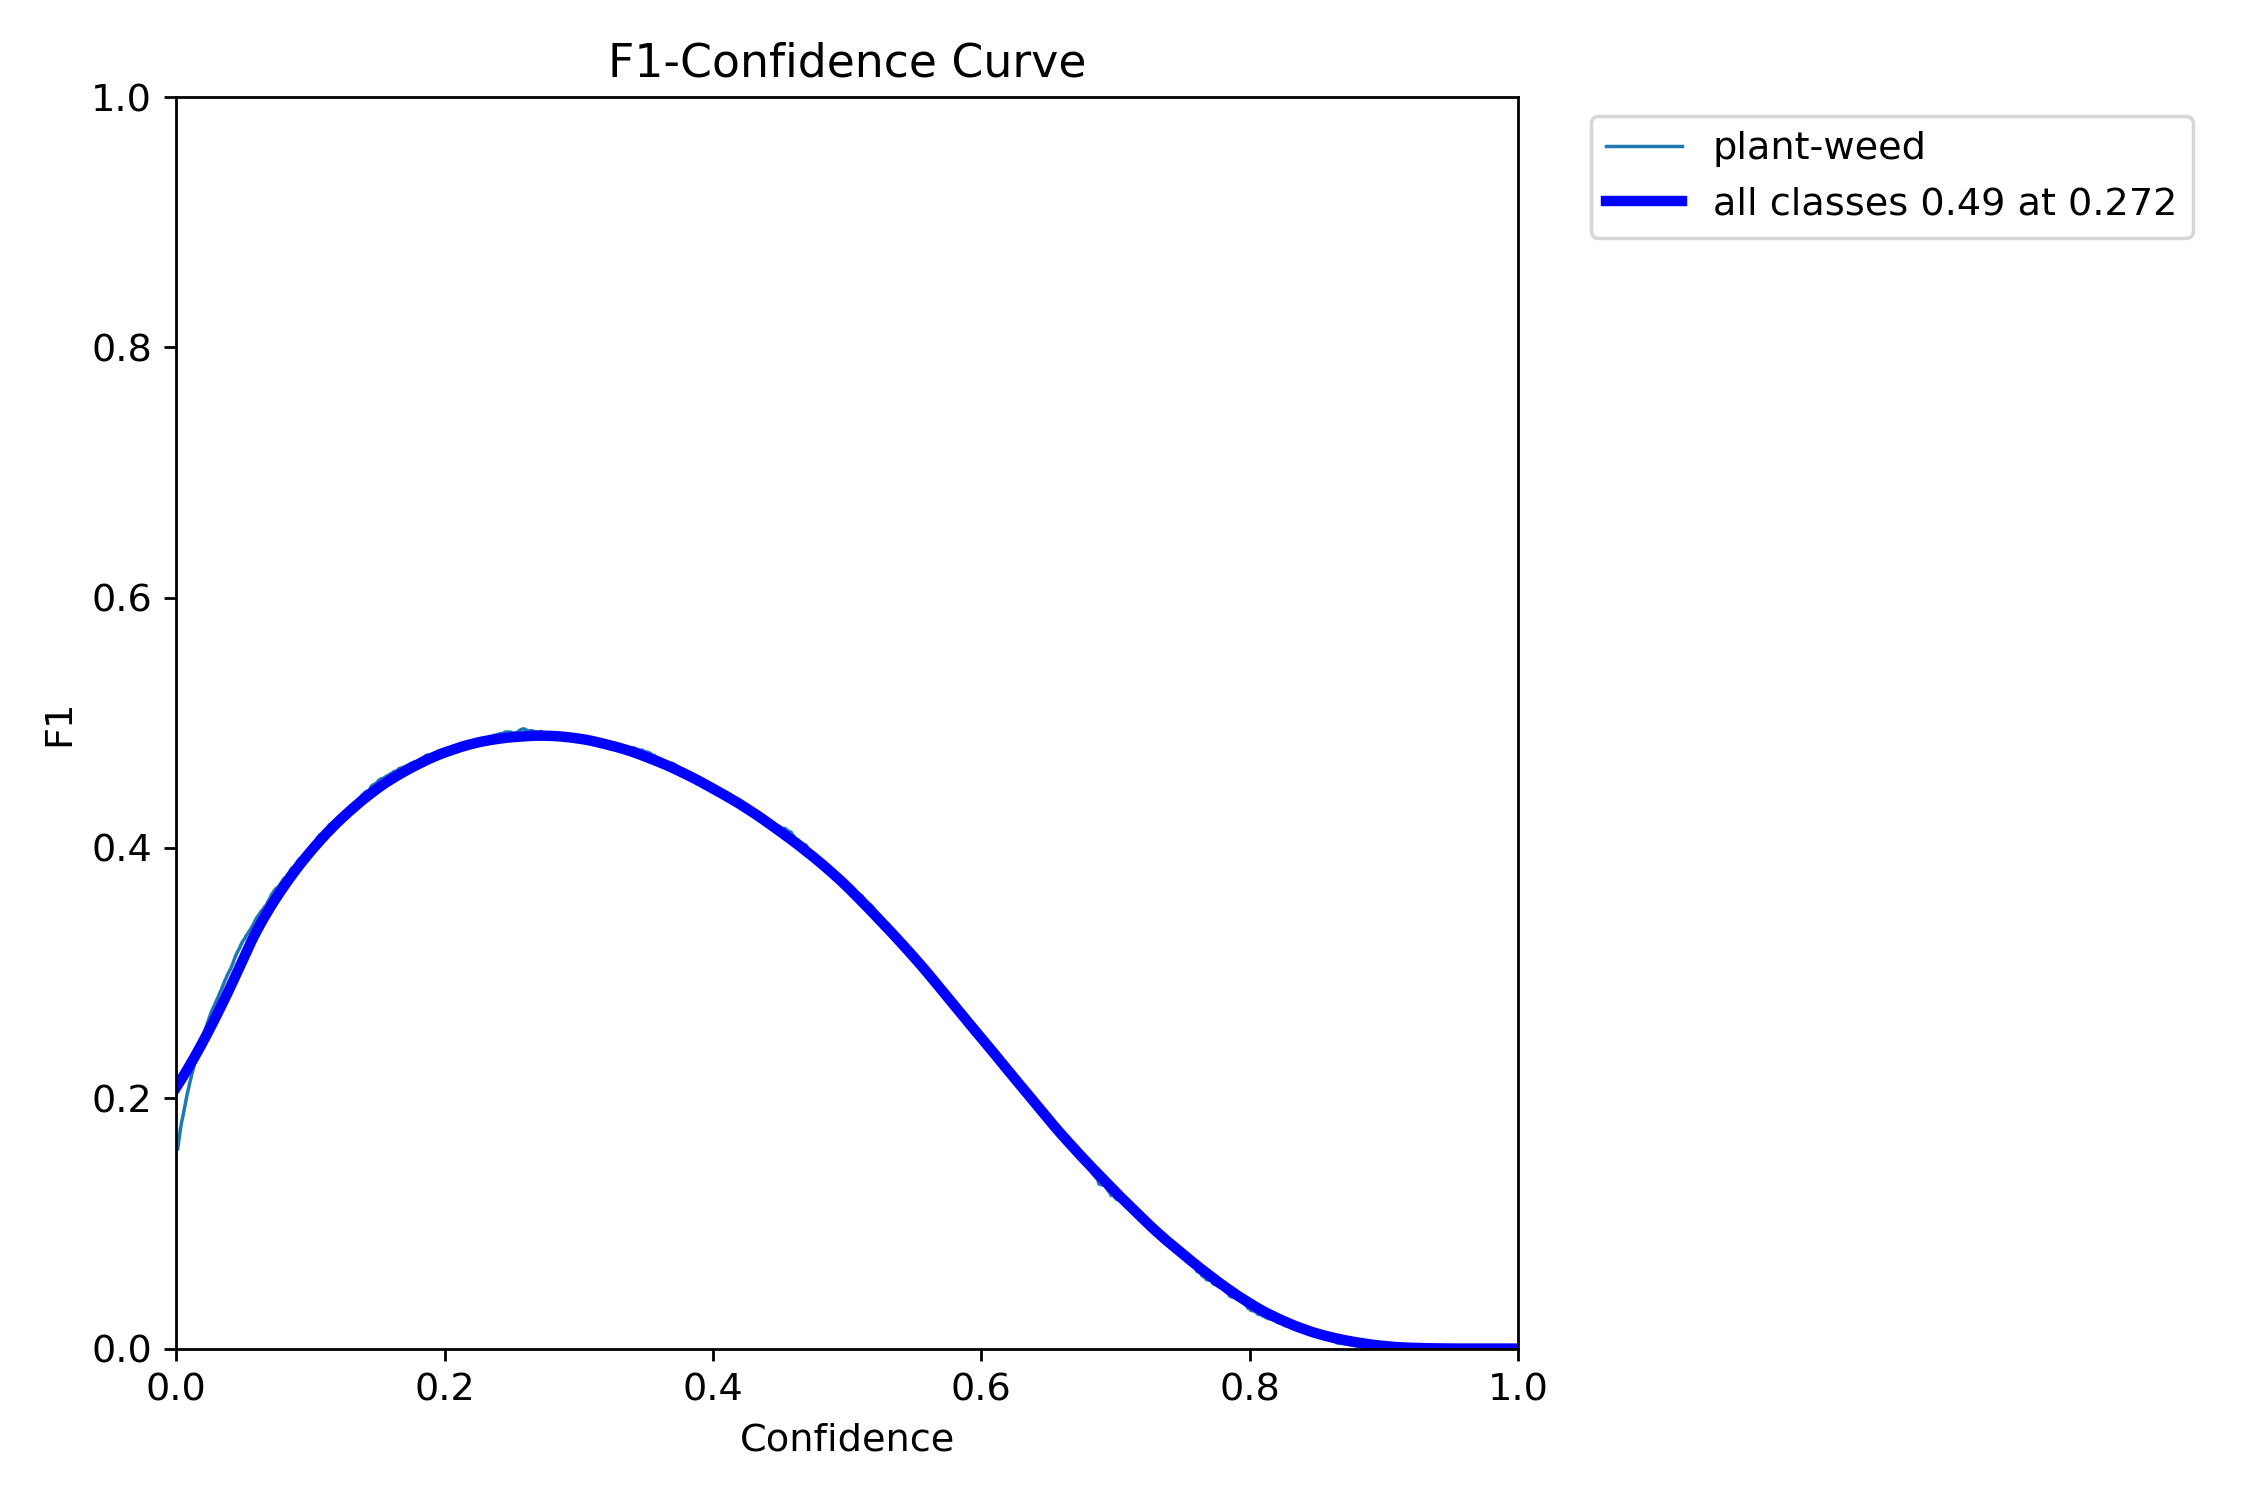

In [60]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

## Validation

In [61]:
folder = "val3/"

#### Classification metrics

In [100]:
# Setting values from CM graph
TP = 1873
FP = 1266
FN = 1599

In [101]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 4738

Confusion matrix:
[ 39.53% , 26.72% ]
[ 33.75% , 0.00% ]

Metrics:
- Accuracy: 0.395
- Precision: 0.597
- Recall: 0.539
- F1 Score: 0.567
- F½ Score: 0.584
- G-mean: 0.567


### Graphs

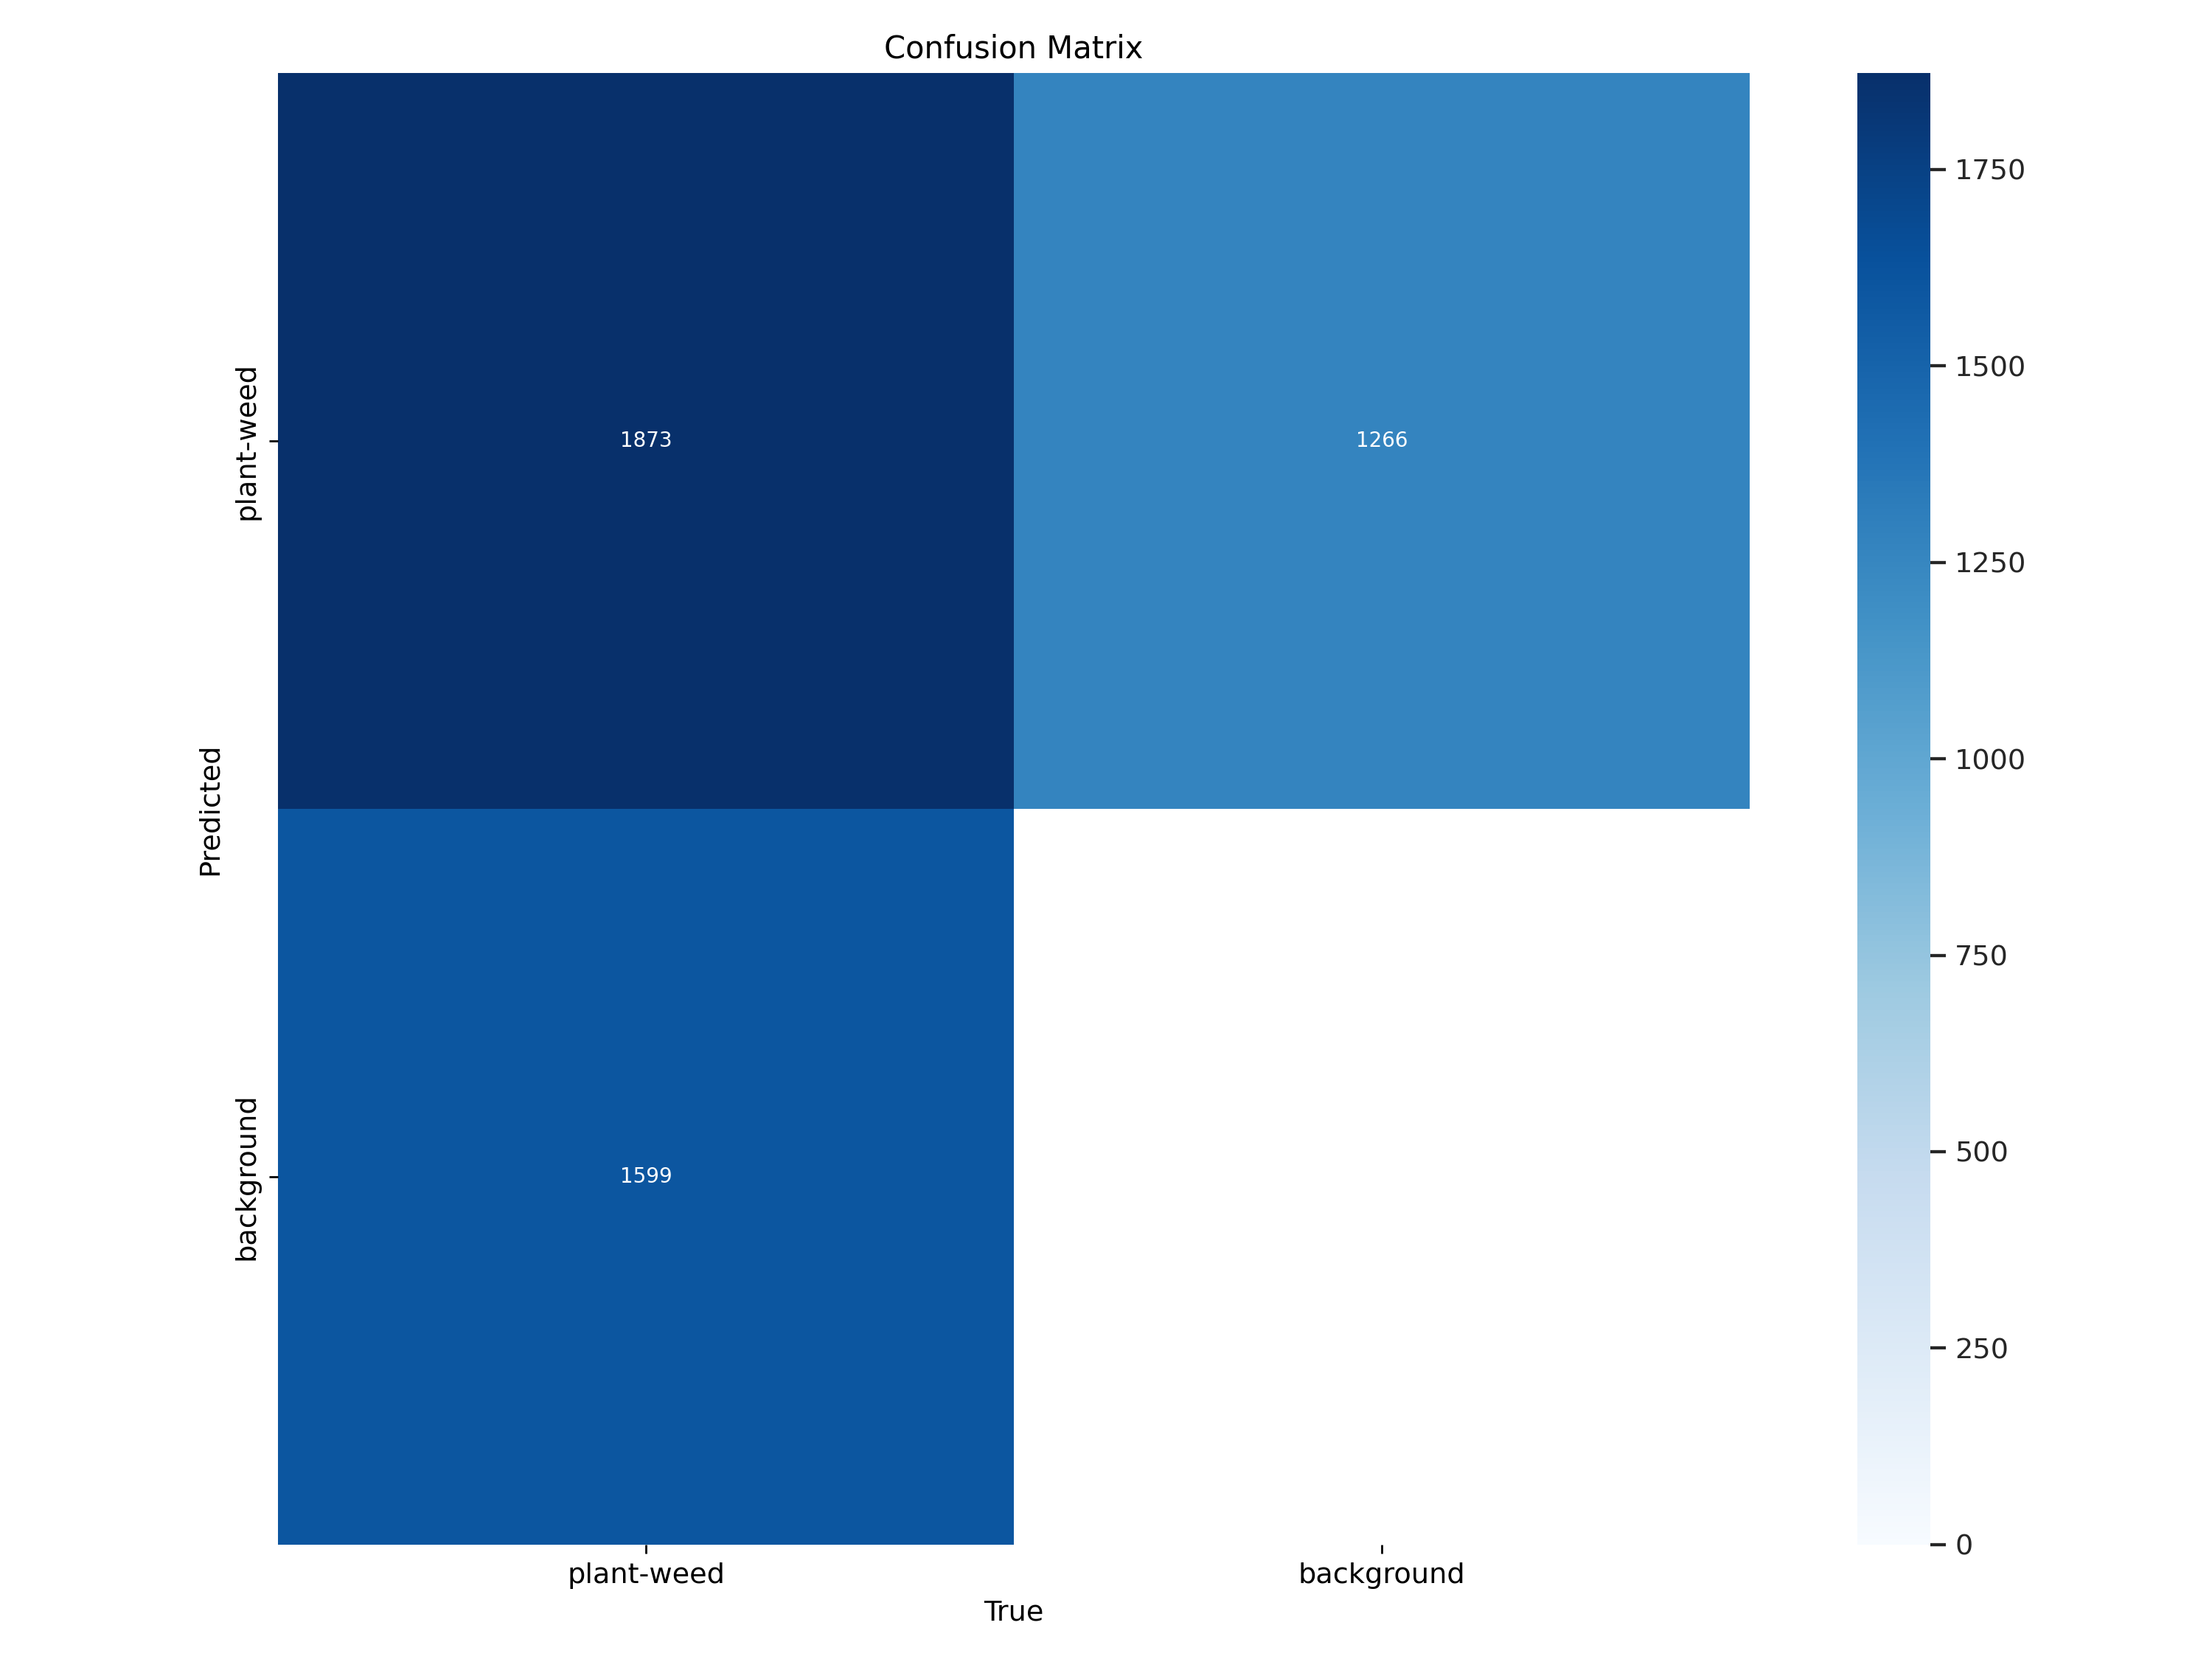

In [64]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

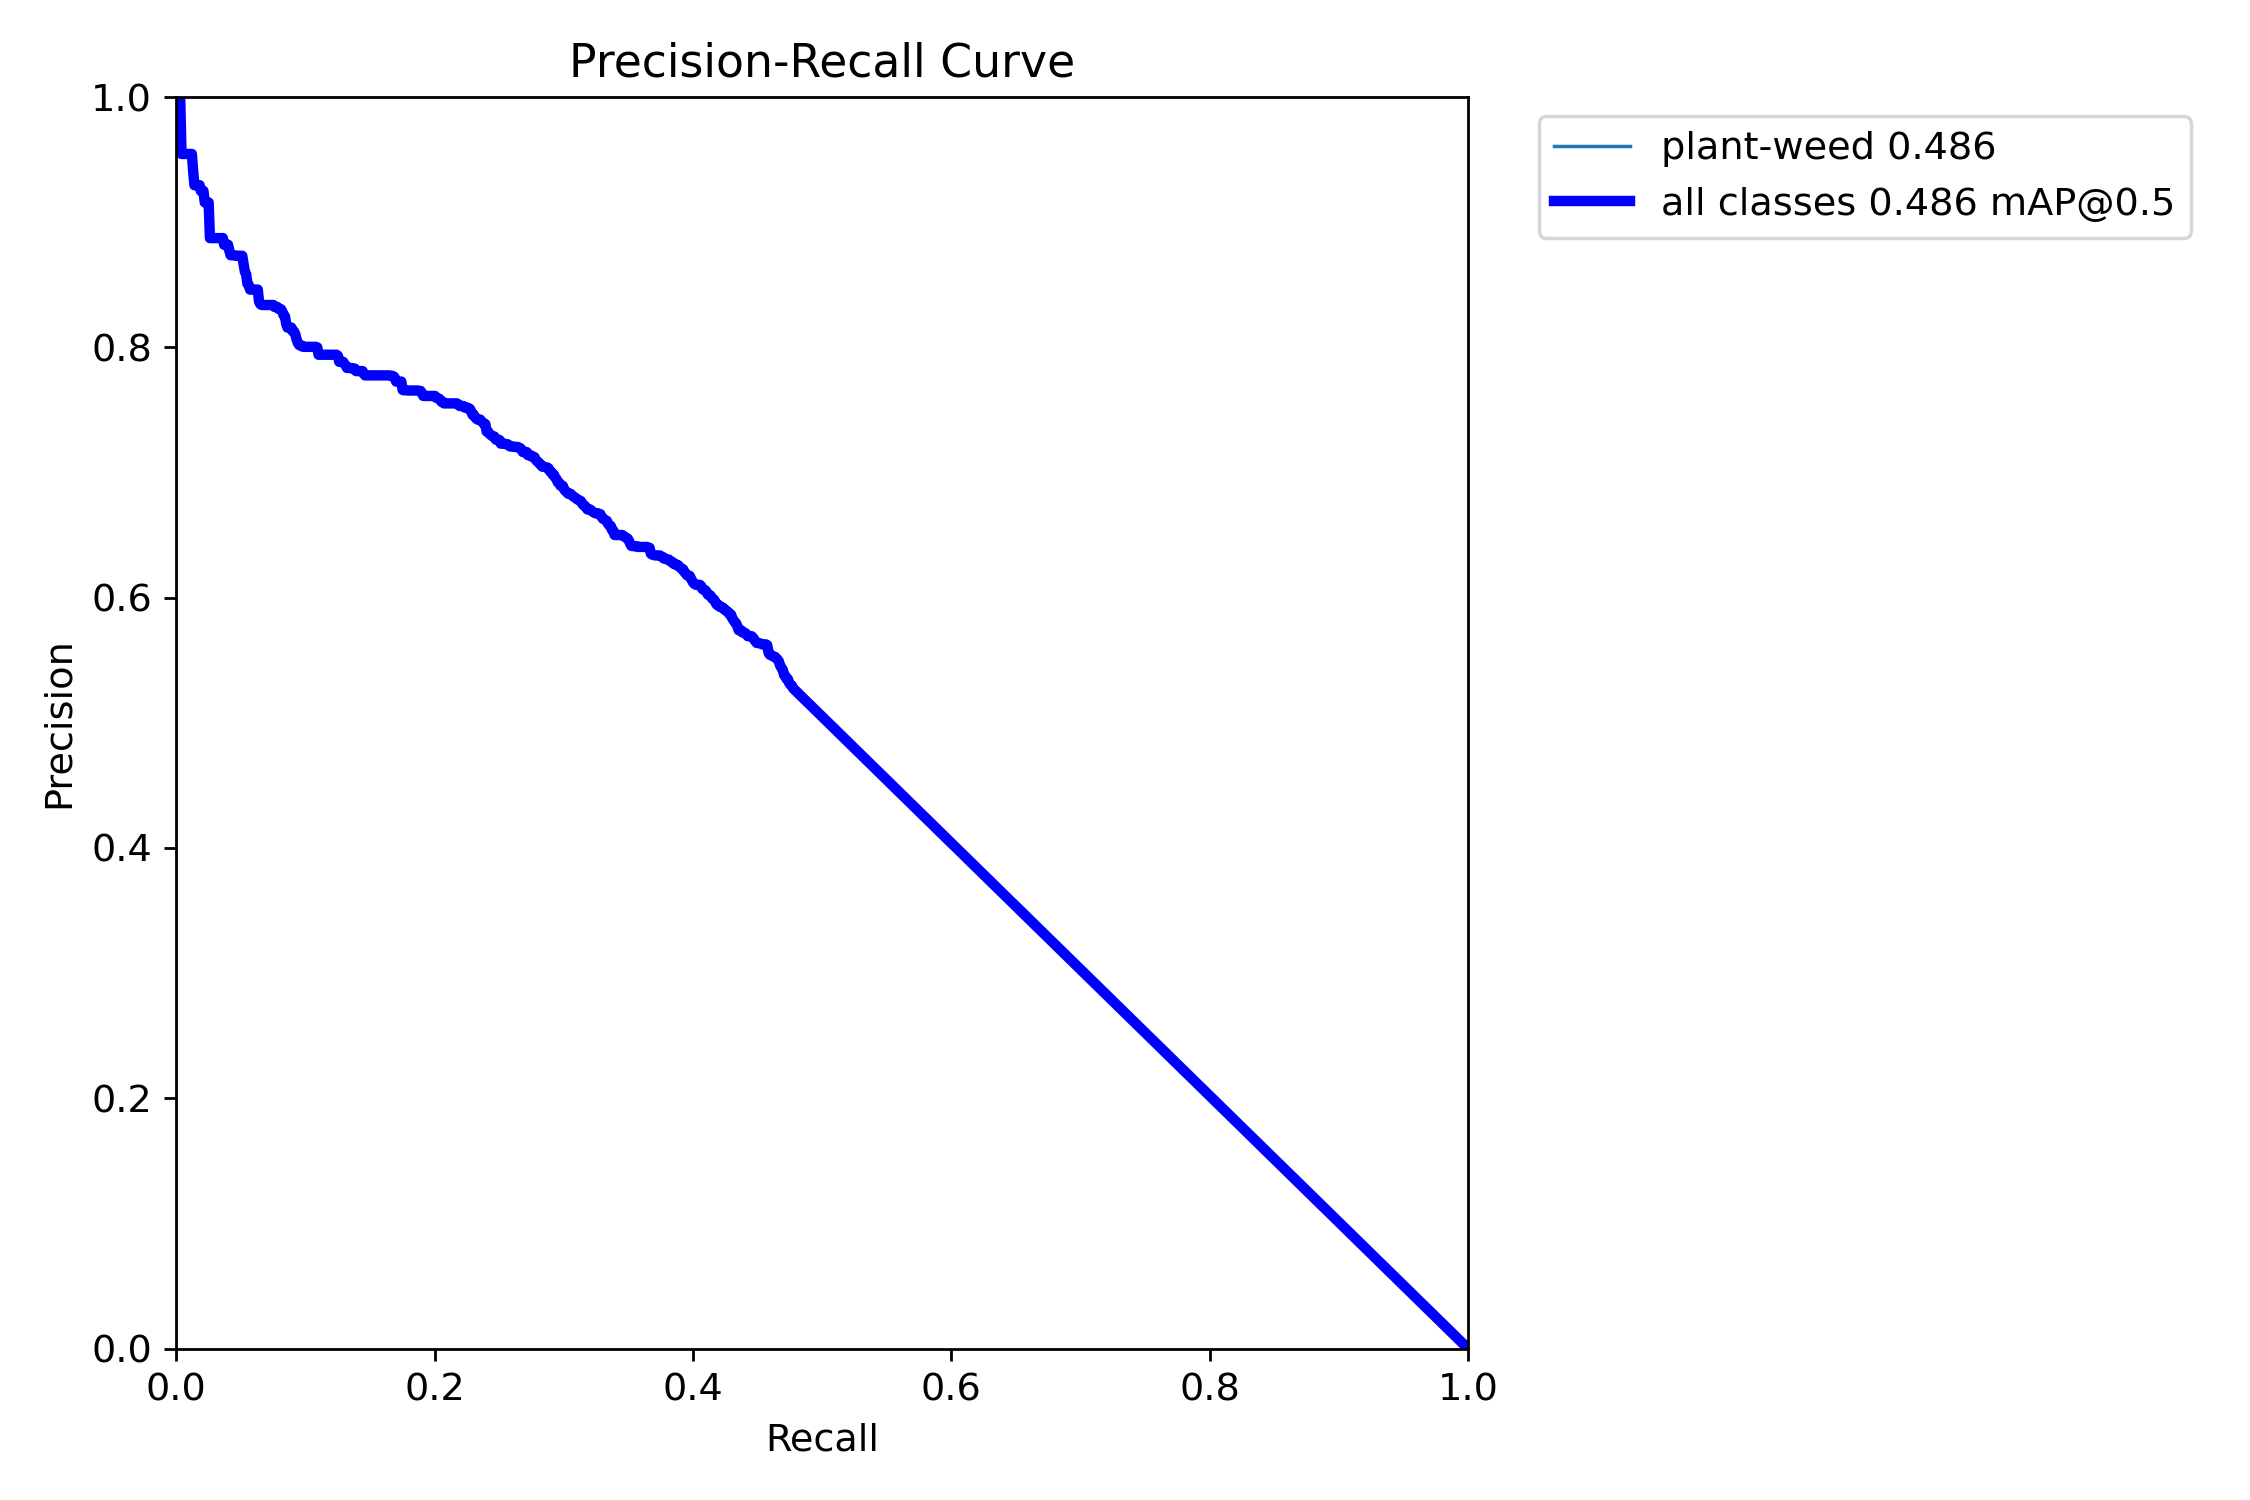

In [65]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

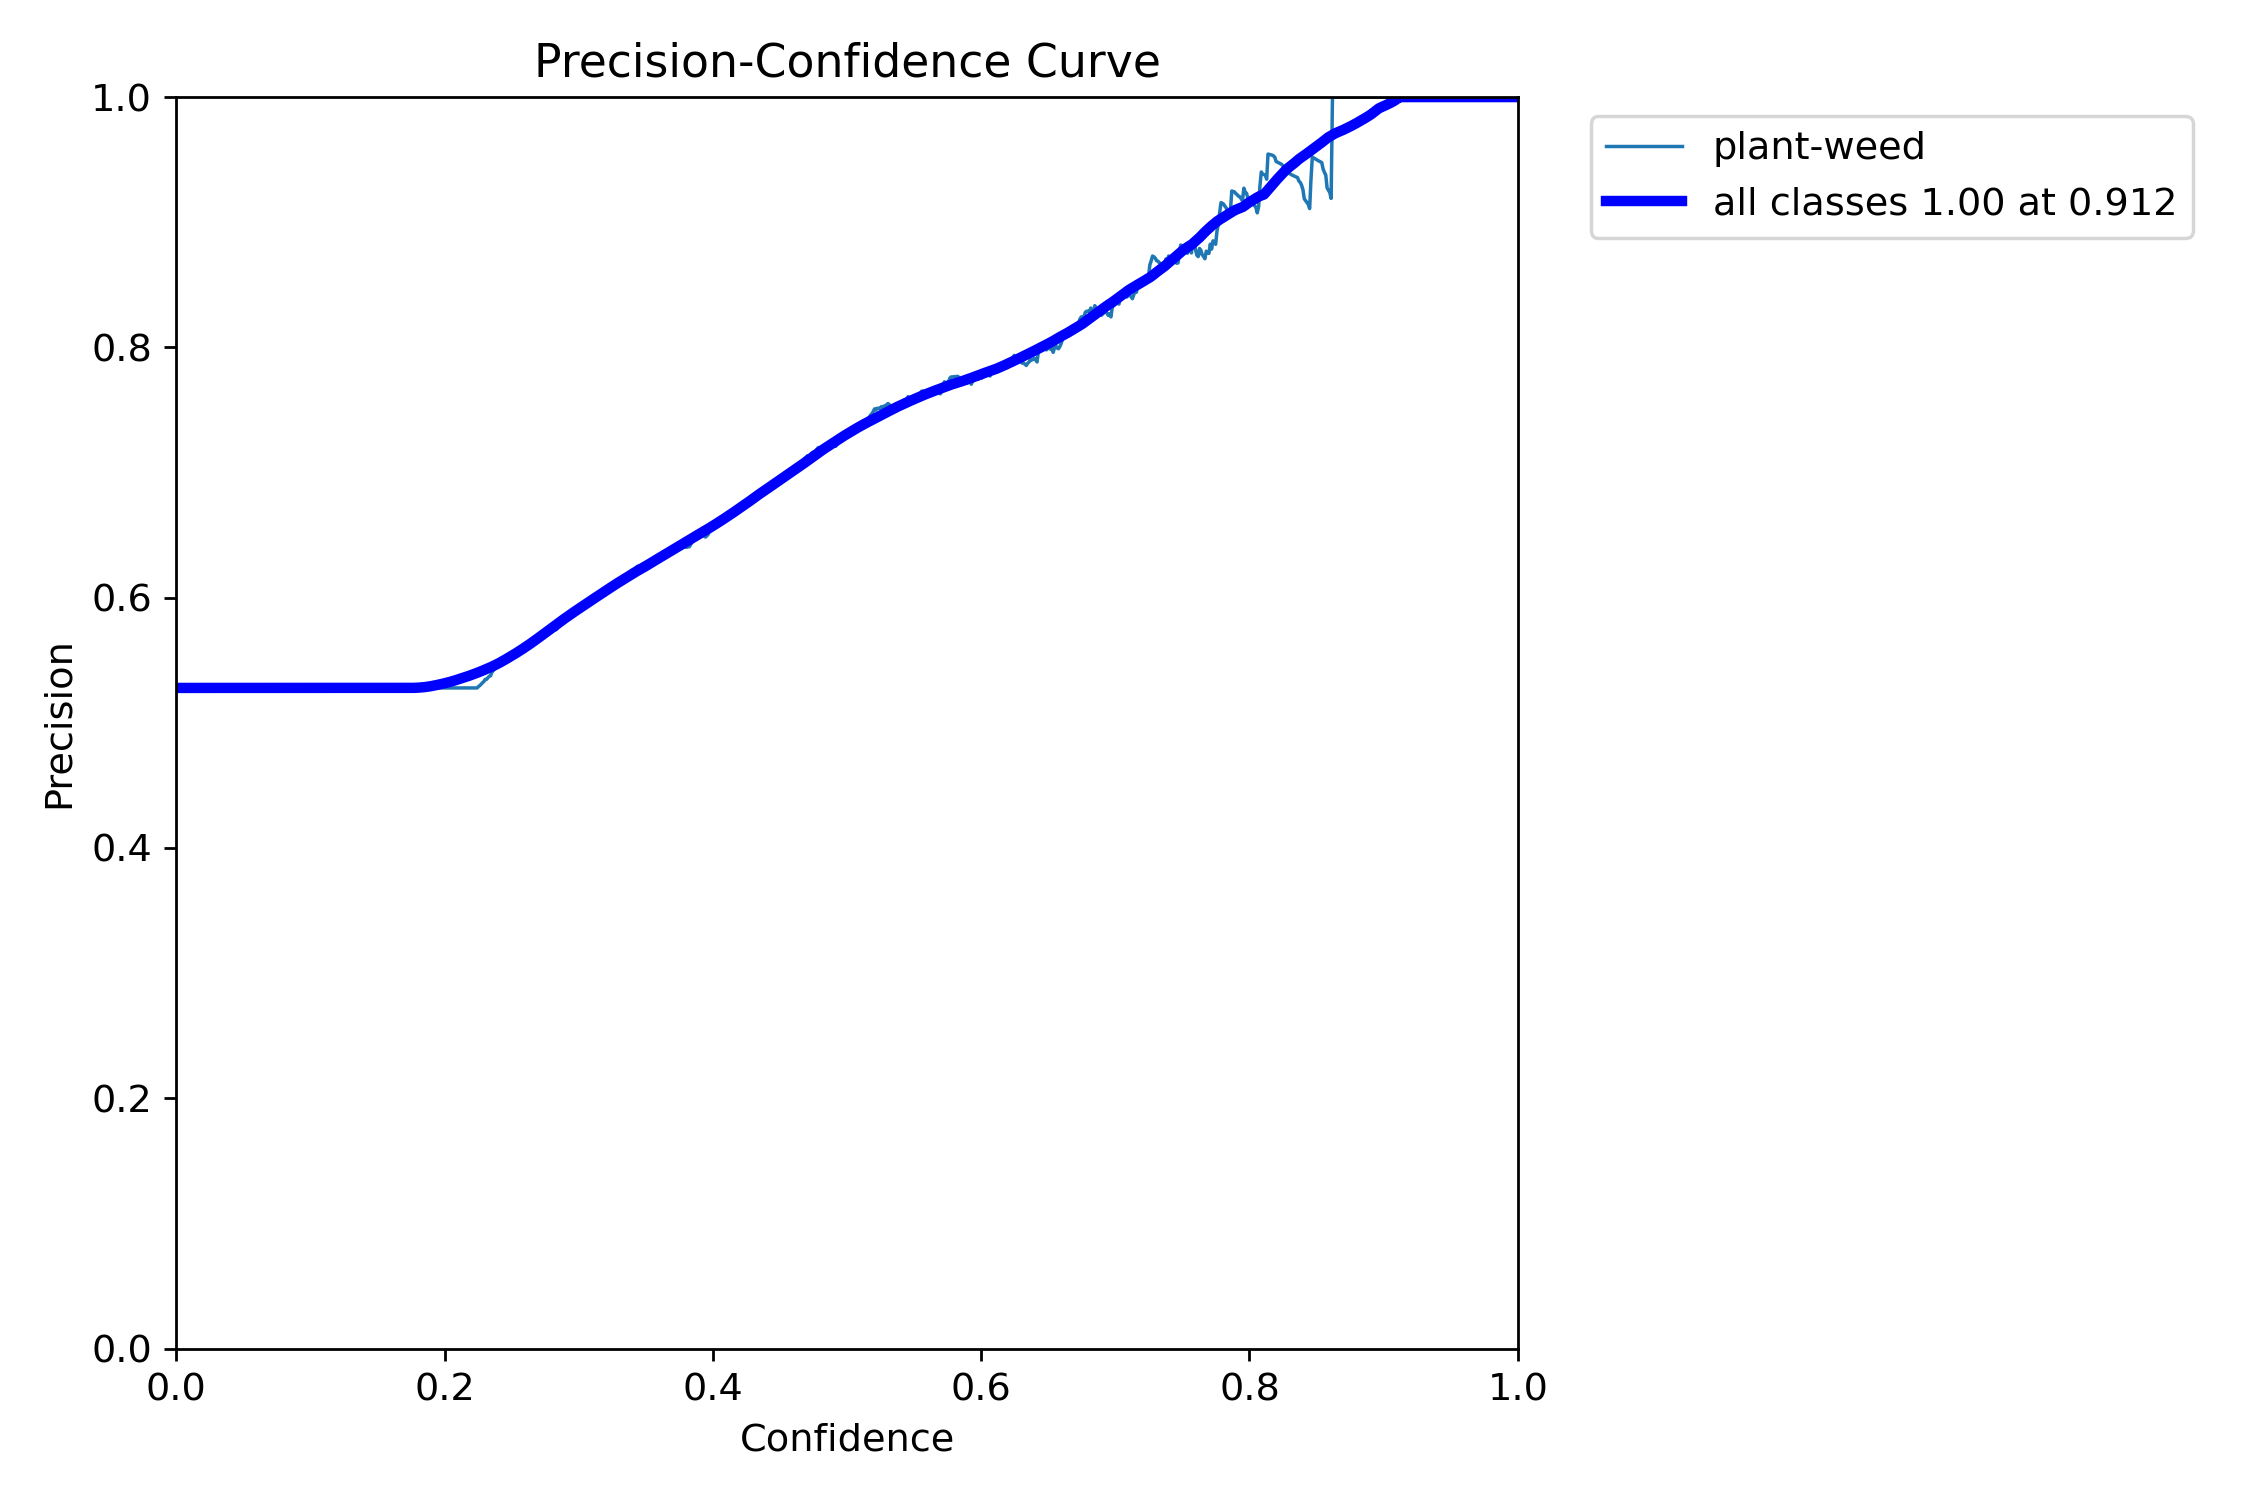

In [66]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

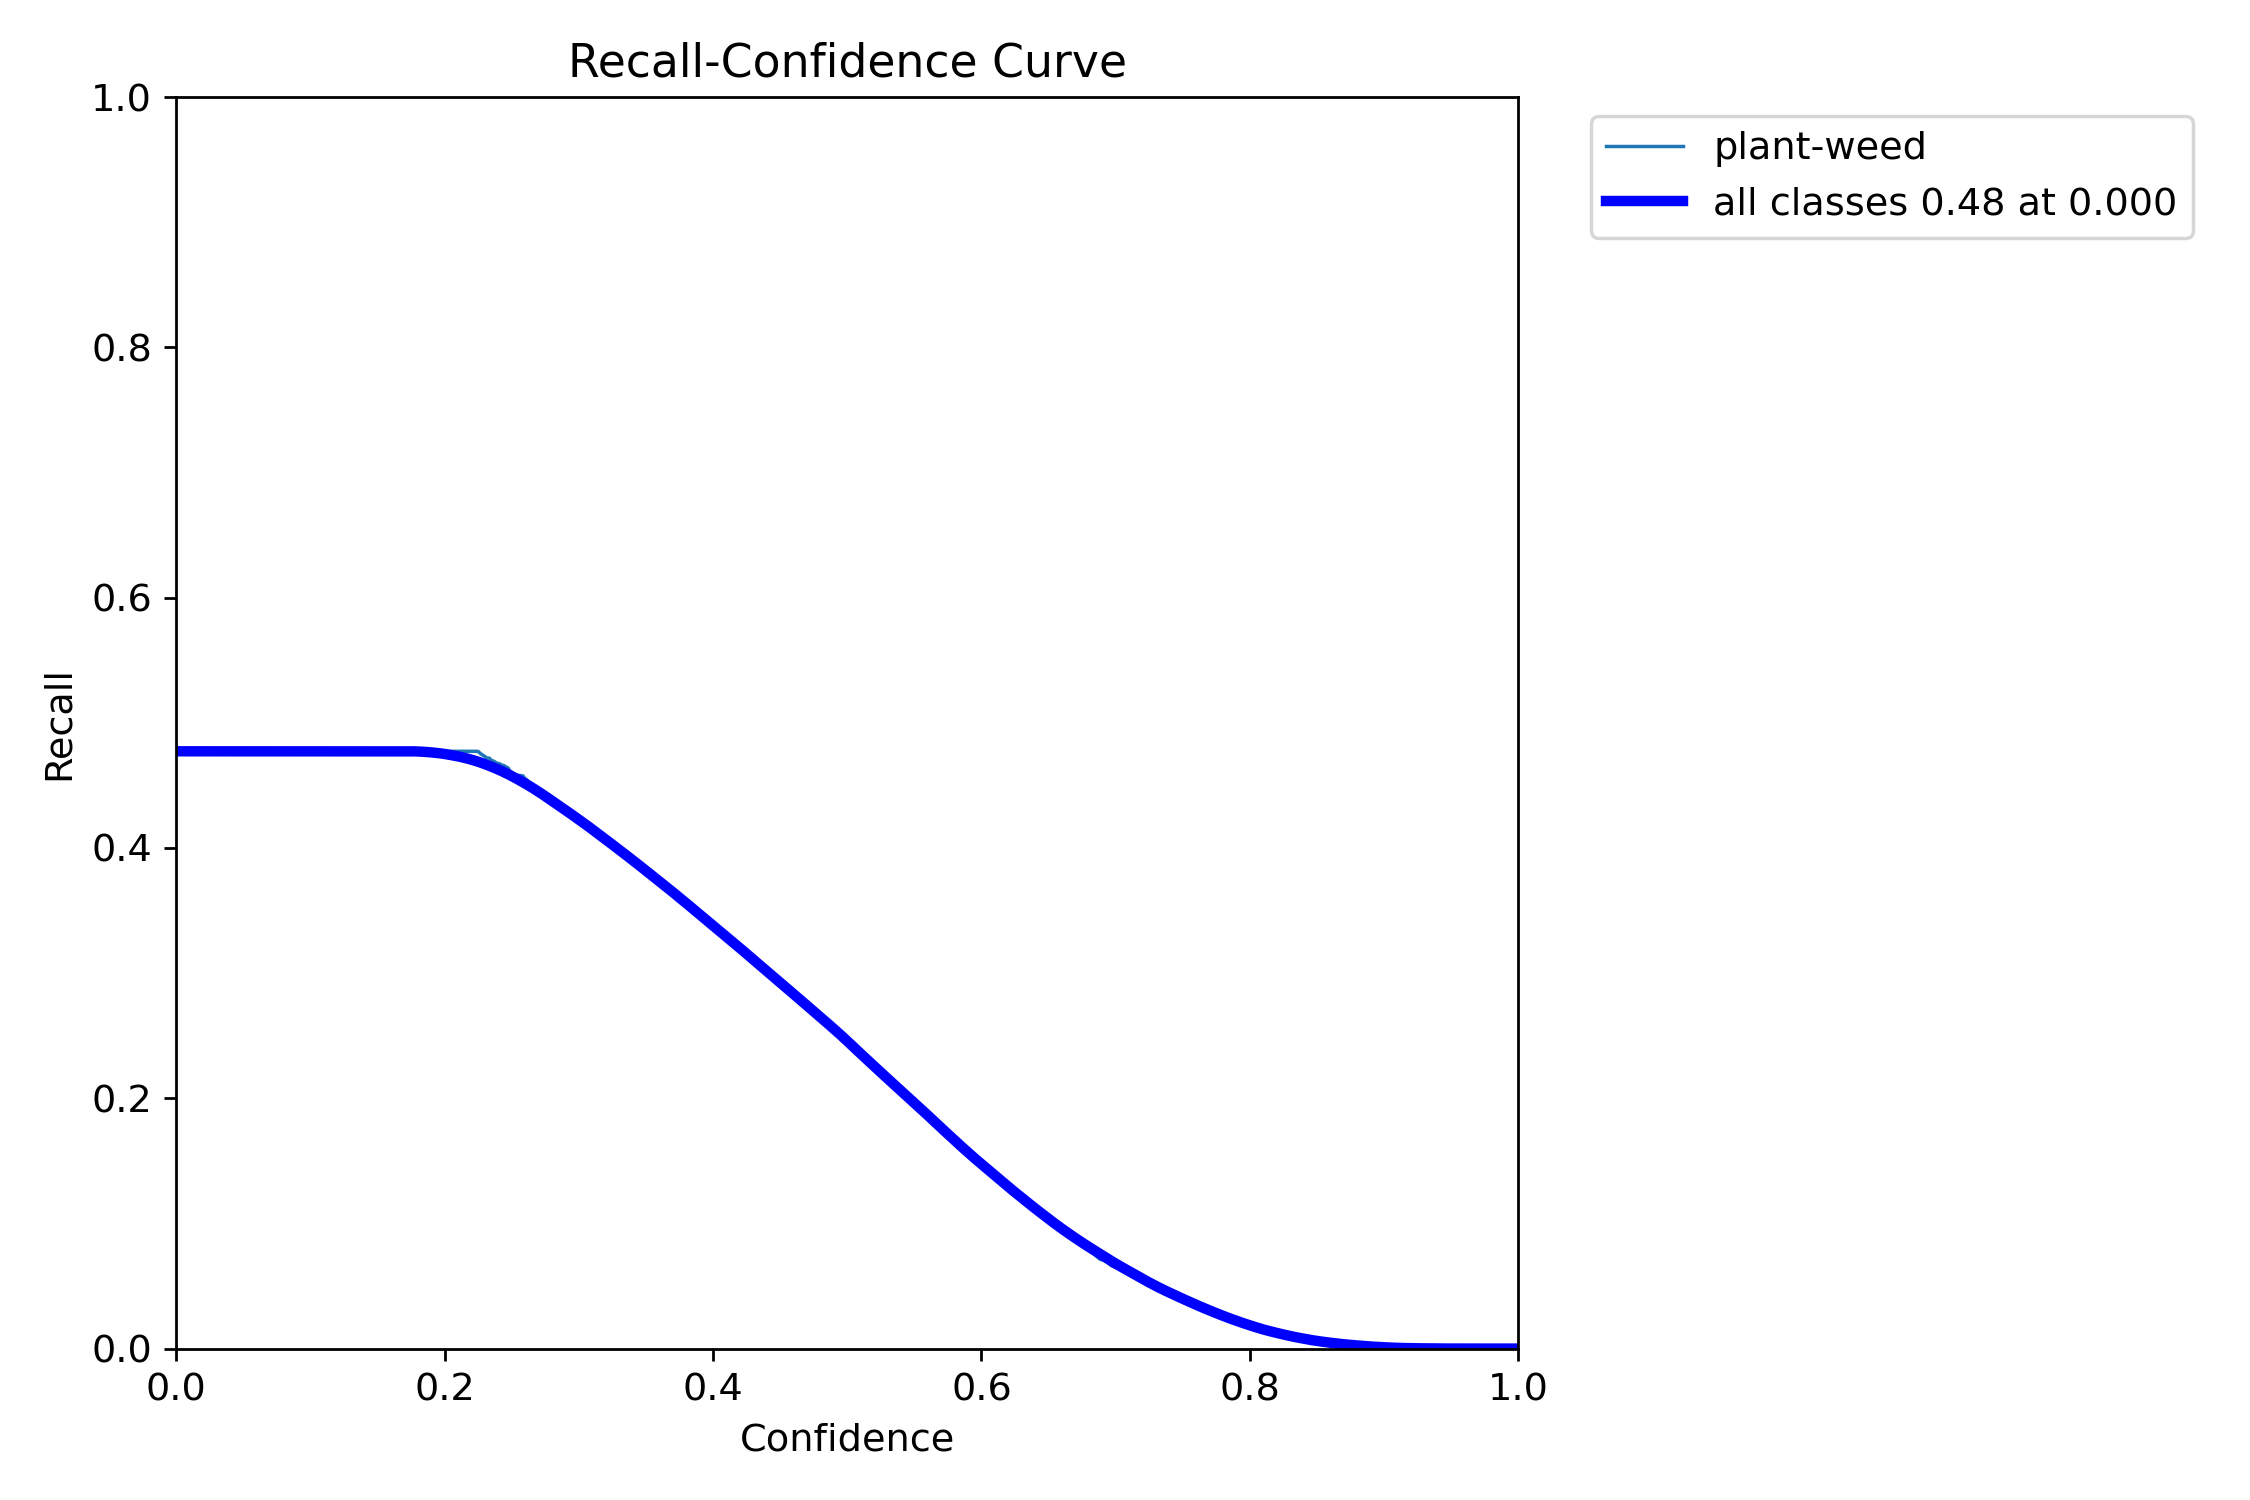

In [67]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

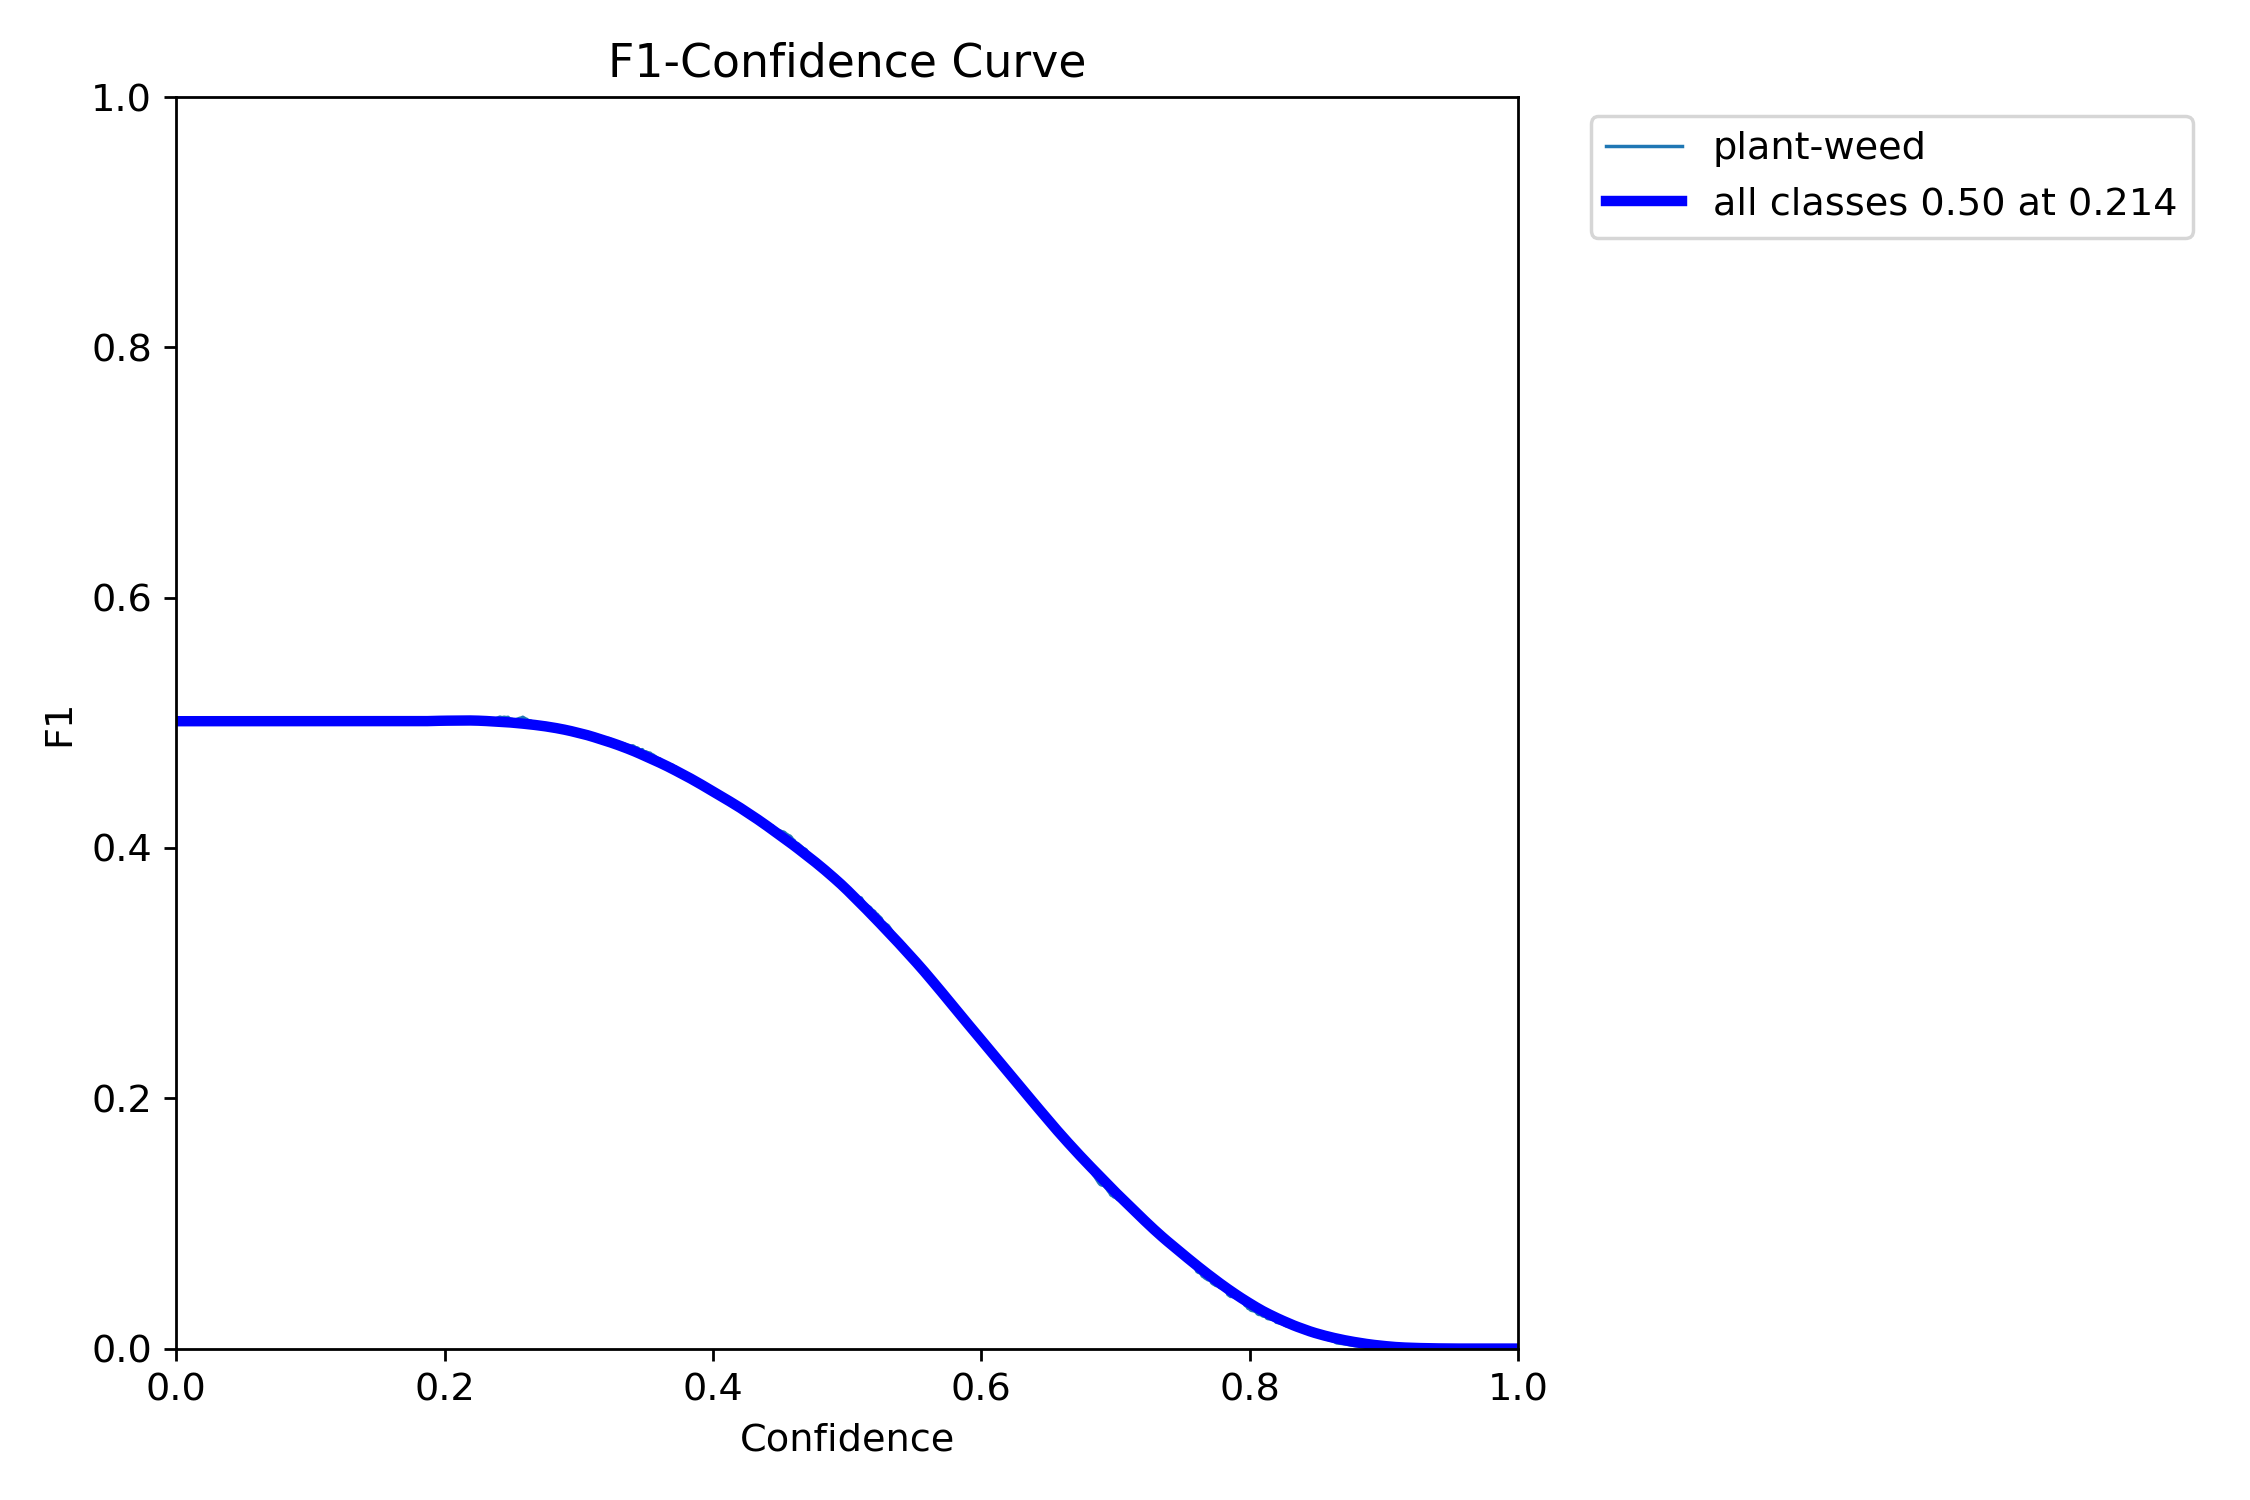

In [68]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

# References

## Experiment 50
### *YOLOv8 Mid | RGB images*

In [69]:
target_folder = f"docs/Experimentos/dataset50/"
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/dataset50
Project root updated to: ../../../


In [72]:
folder = "runs/detect/train/"

In [73]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df4 = pd.read_csv(file_path)
df = df4.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
440,441,4041.41,0.97963,0.53960,0.91744,0.51658,0.43808,0.41522,0.13044,2.71469,1.47613,2.10757,0.000258,0.000258,0.000258
441,442,4050.08,1.01742,0.54645,0.92930,0.51147,0.44206,0.41585,0.13107,2.71141,1.46415,2.09698,0.000254,0.000254,0.000254
442,443,4059.01,0.99178,0.54124,0.91862,0.50908,0.44470,0.41386,0.13165,2.70446,1.46262,2.08540,0.000250,0.000250,0.000250
443,444,4068.80,0.97619,0.53275,0.92091,0.50990,0.43980,0.40991,0.13014,2.70971,1.47070,2.08673,0.000246,0.000246,0.000246
444,445,4077.45,1.00435,0.55167,0.92804,0.52196,0.44816,0.41814,0.13255,2.70032,1.45801,2.08173,0.000242,0.000242,0.000242


In [74]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 67.957 min


#### Best epoch

In [75]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
244,245,2251.92,1.254,0.68498,1.01302,0.54078,0.47725,0.45351,0.14676,2.66094,1.39187,2.03566,0.001034,0.001034,0.001034,67.9575


In [76]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print("Proceso de entrenamiento:")
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Proceso de entrenamiento:
Mejor época de entrenamiento 245 con mAP50 de 0.454


In [77]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [98]:
# Setting values from CM graph
TP = 2011
FP = 1671
FN = 1461

In [99]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 5143

Confusion matrix:
[ 39.10% , 32.49% ]
[ 28.41% , 0.00% ]

Metrics:
- Accuracy: 0.391
- Precision: 0.546
- Recall: 0.579
- F1 Score: 0.562
- F½ Score: 0.552
- G-mean: 0.562


### Graphs

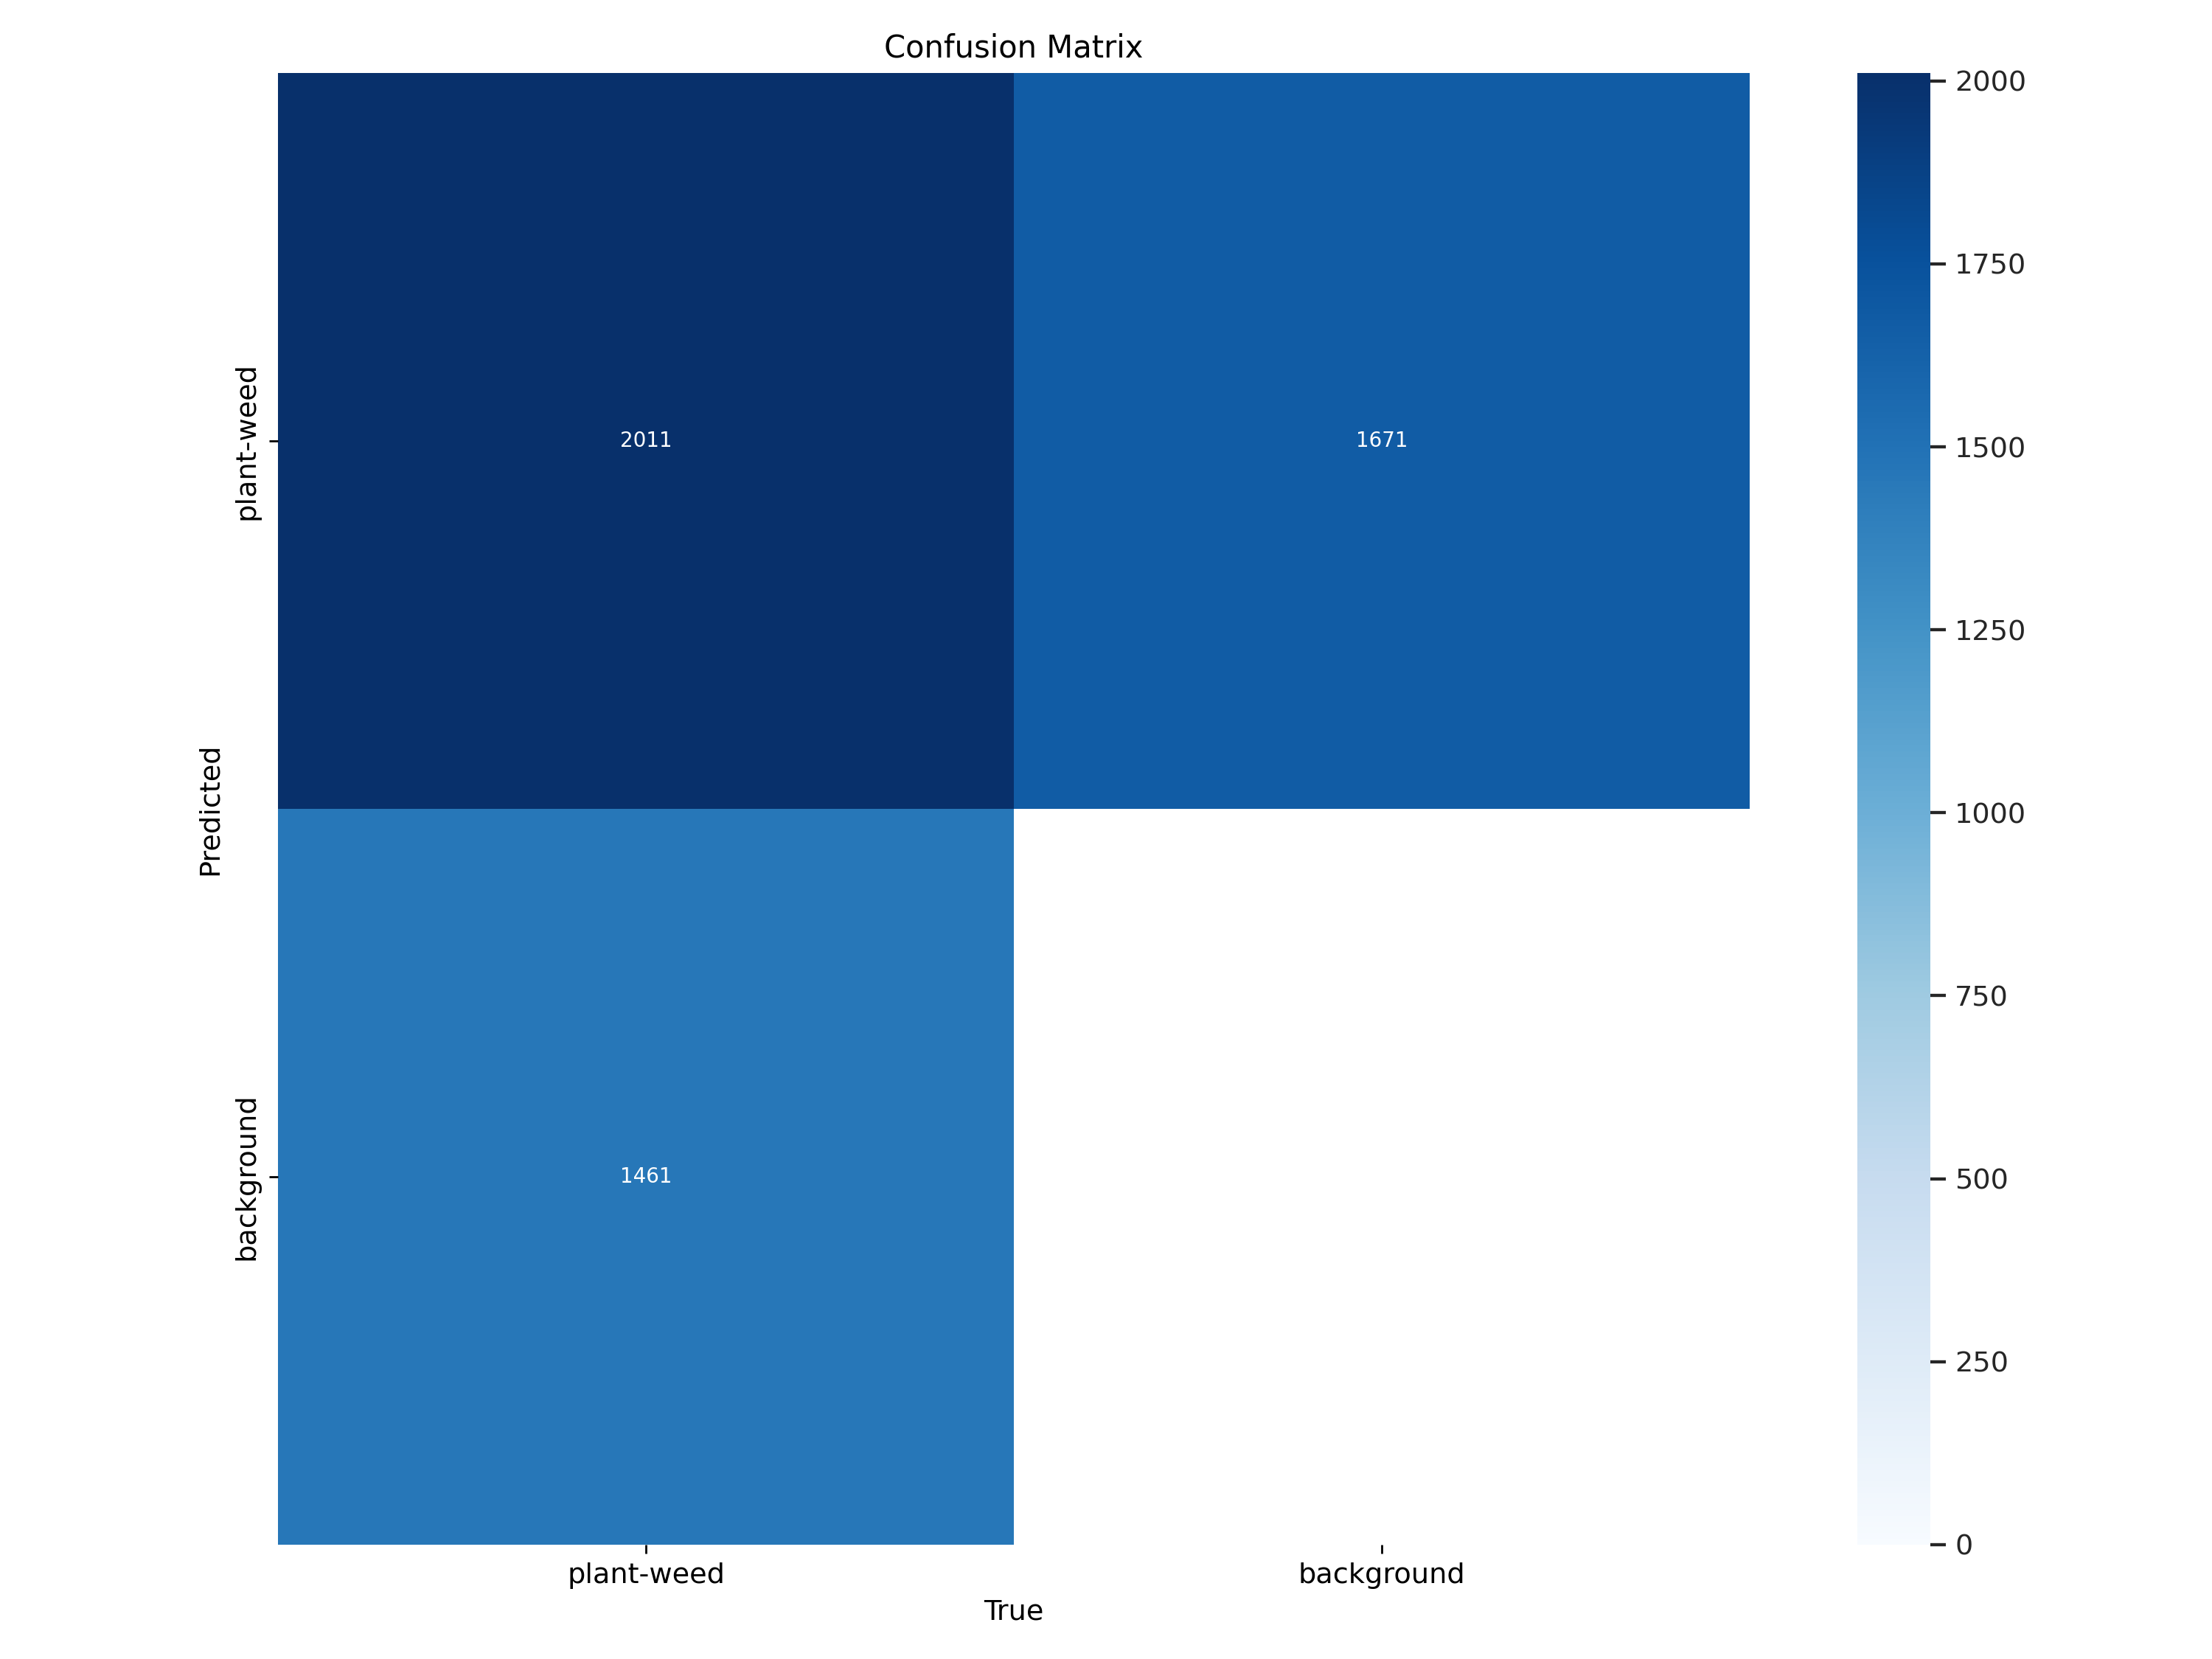

In [80]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

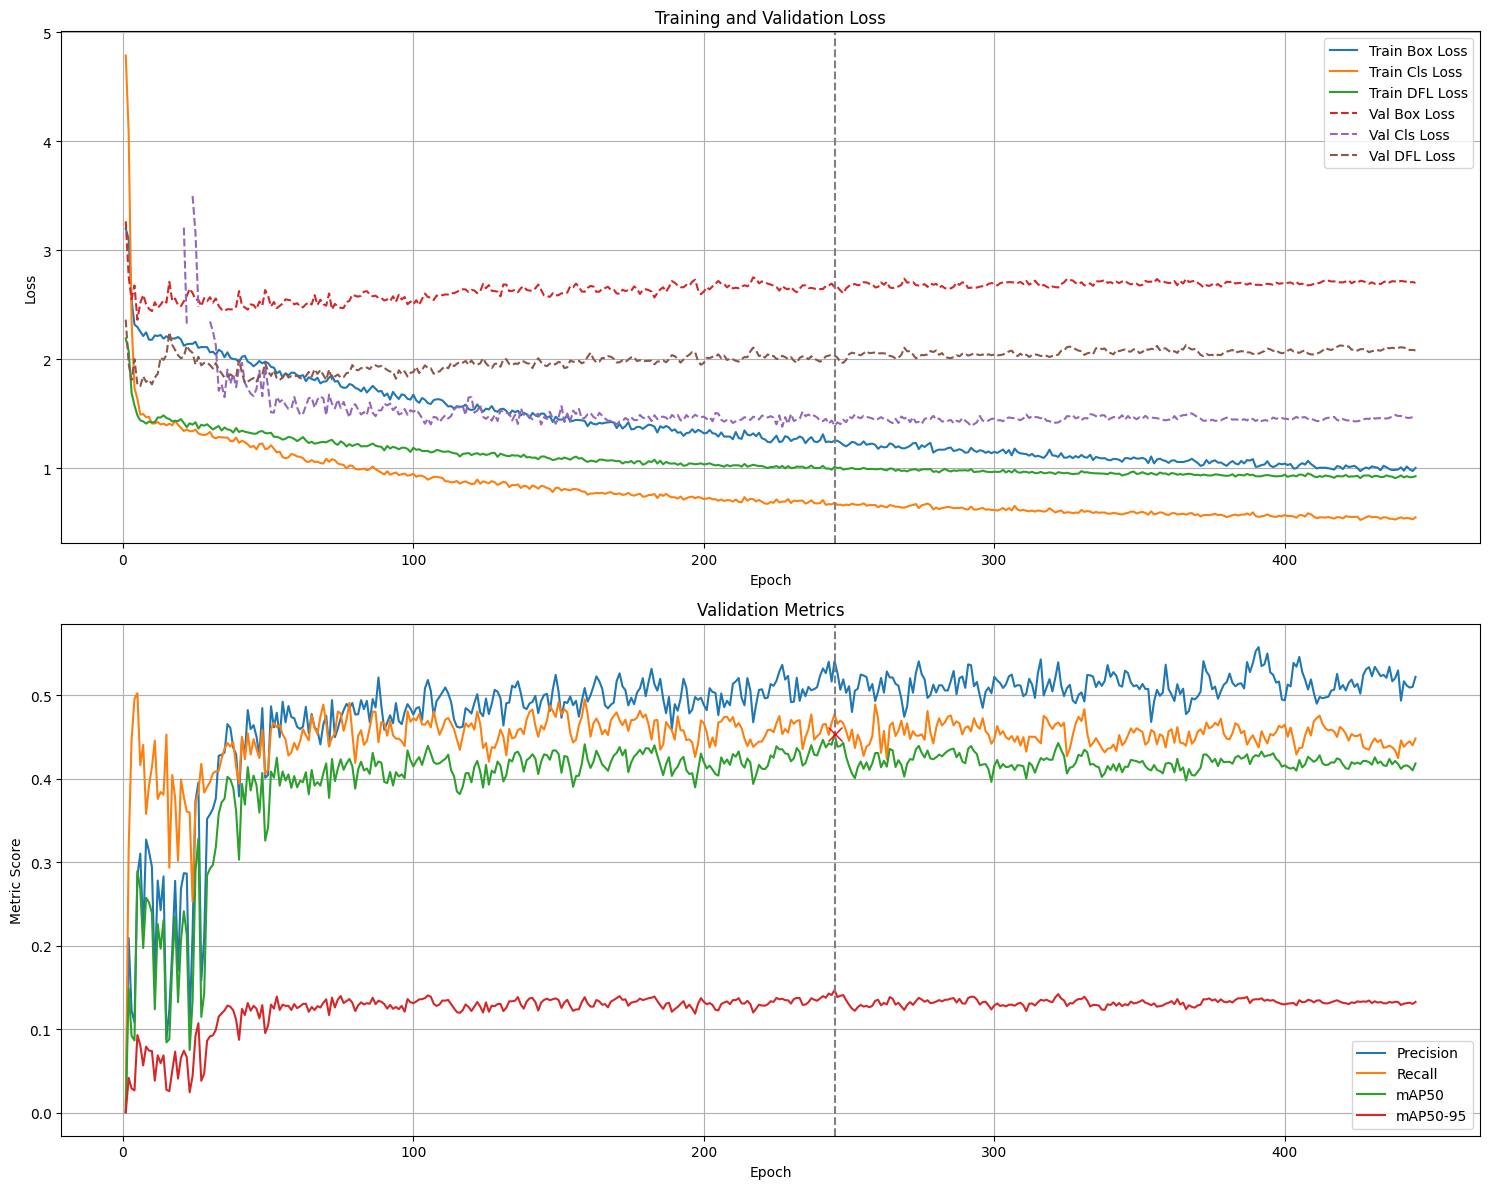

In [81]:
graph_training_metrics(df, epoch, graph="full")


_**NOTA:** `patience`=100 para EarlyStop_

In [82]:
graph_LrLoss_3D(df)

Validation set


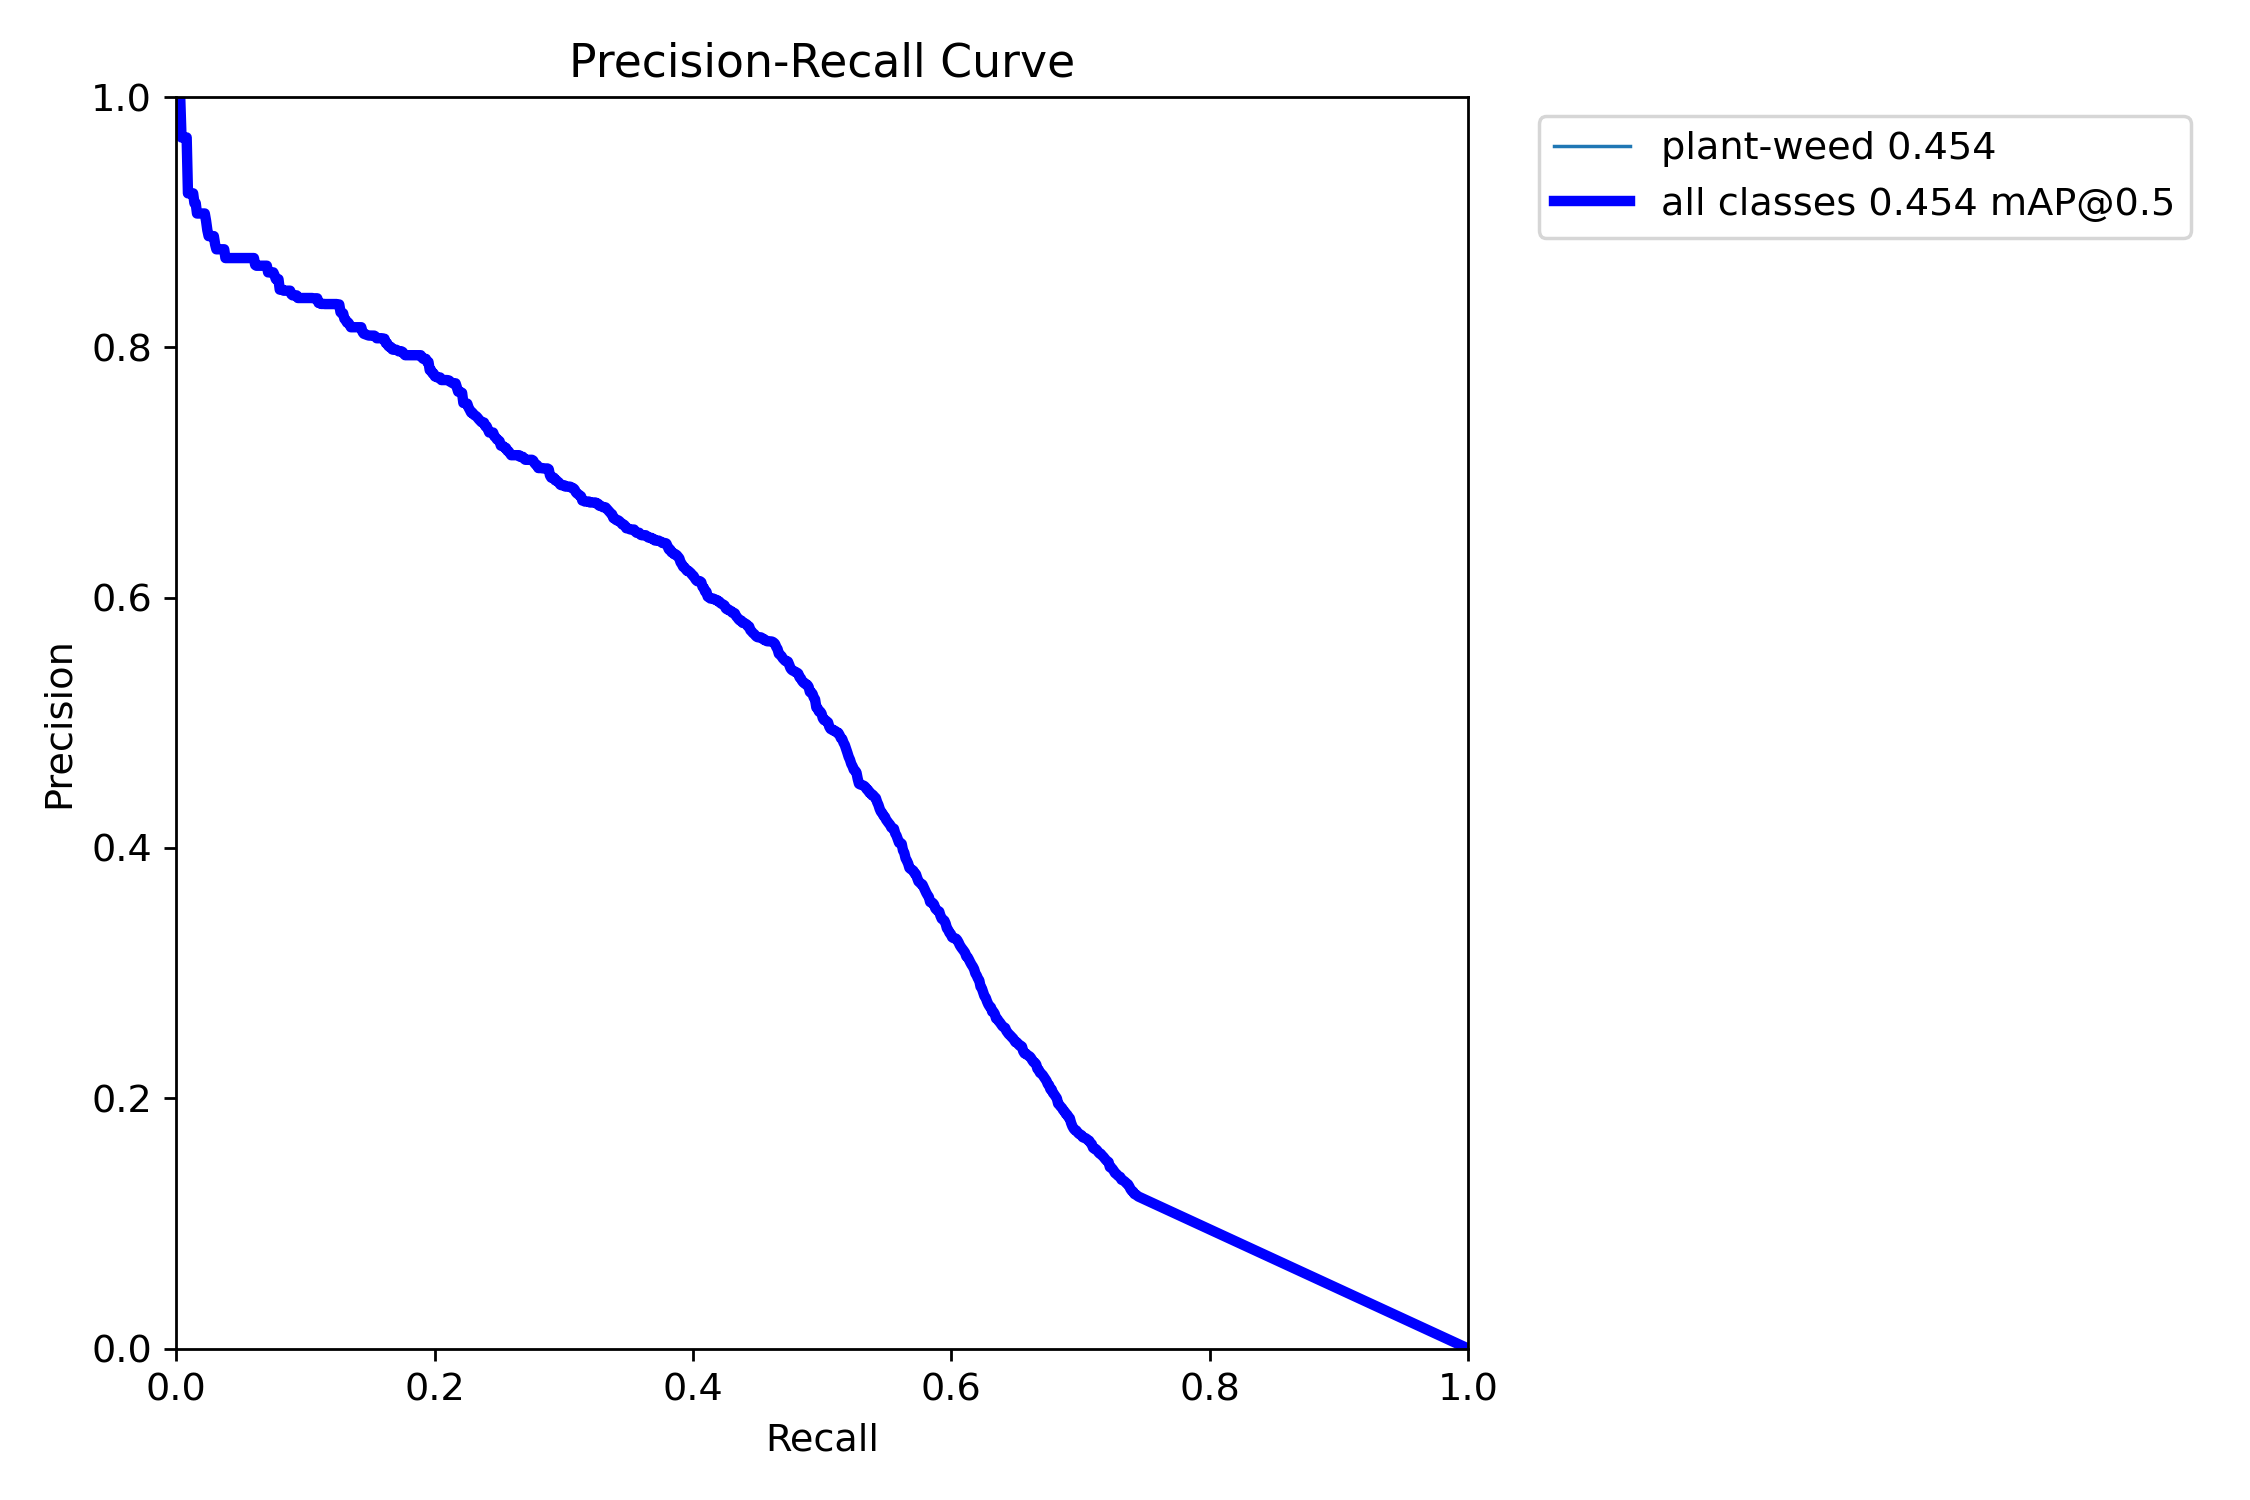

In [83]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

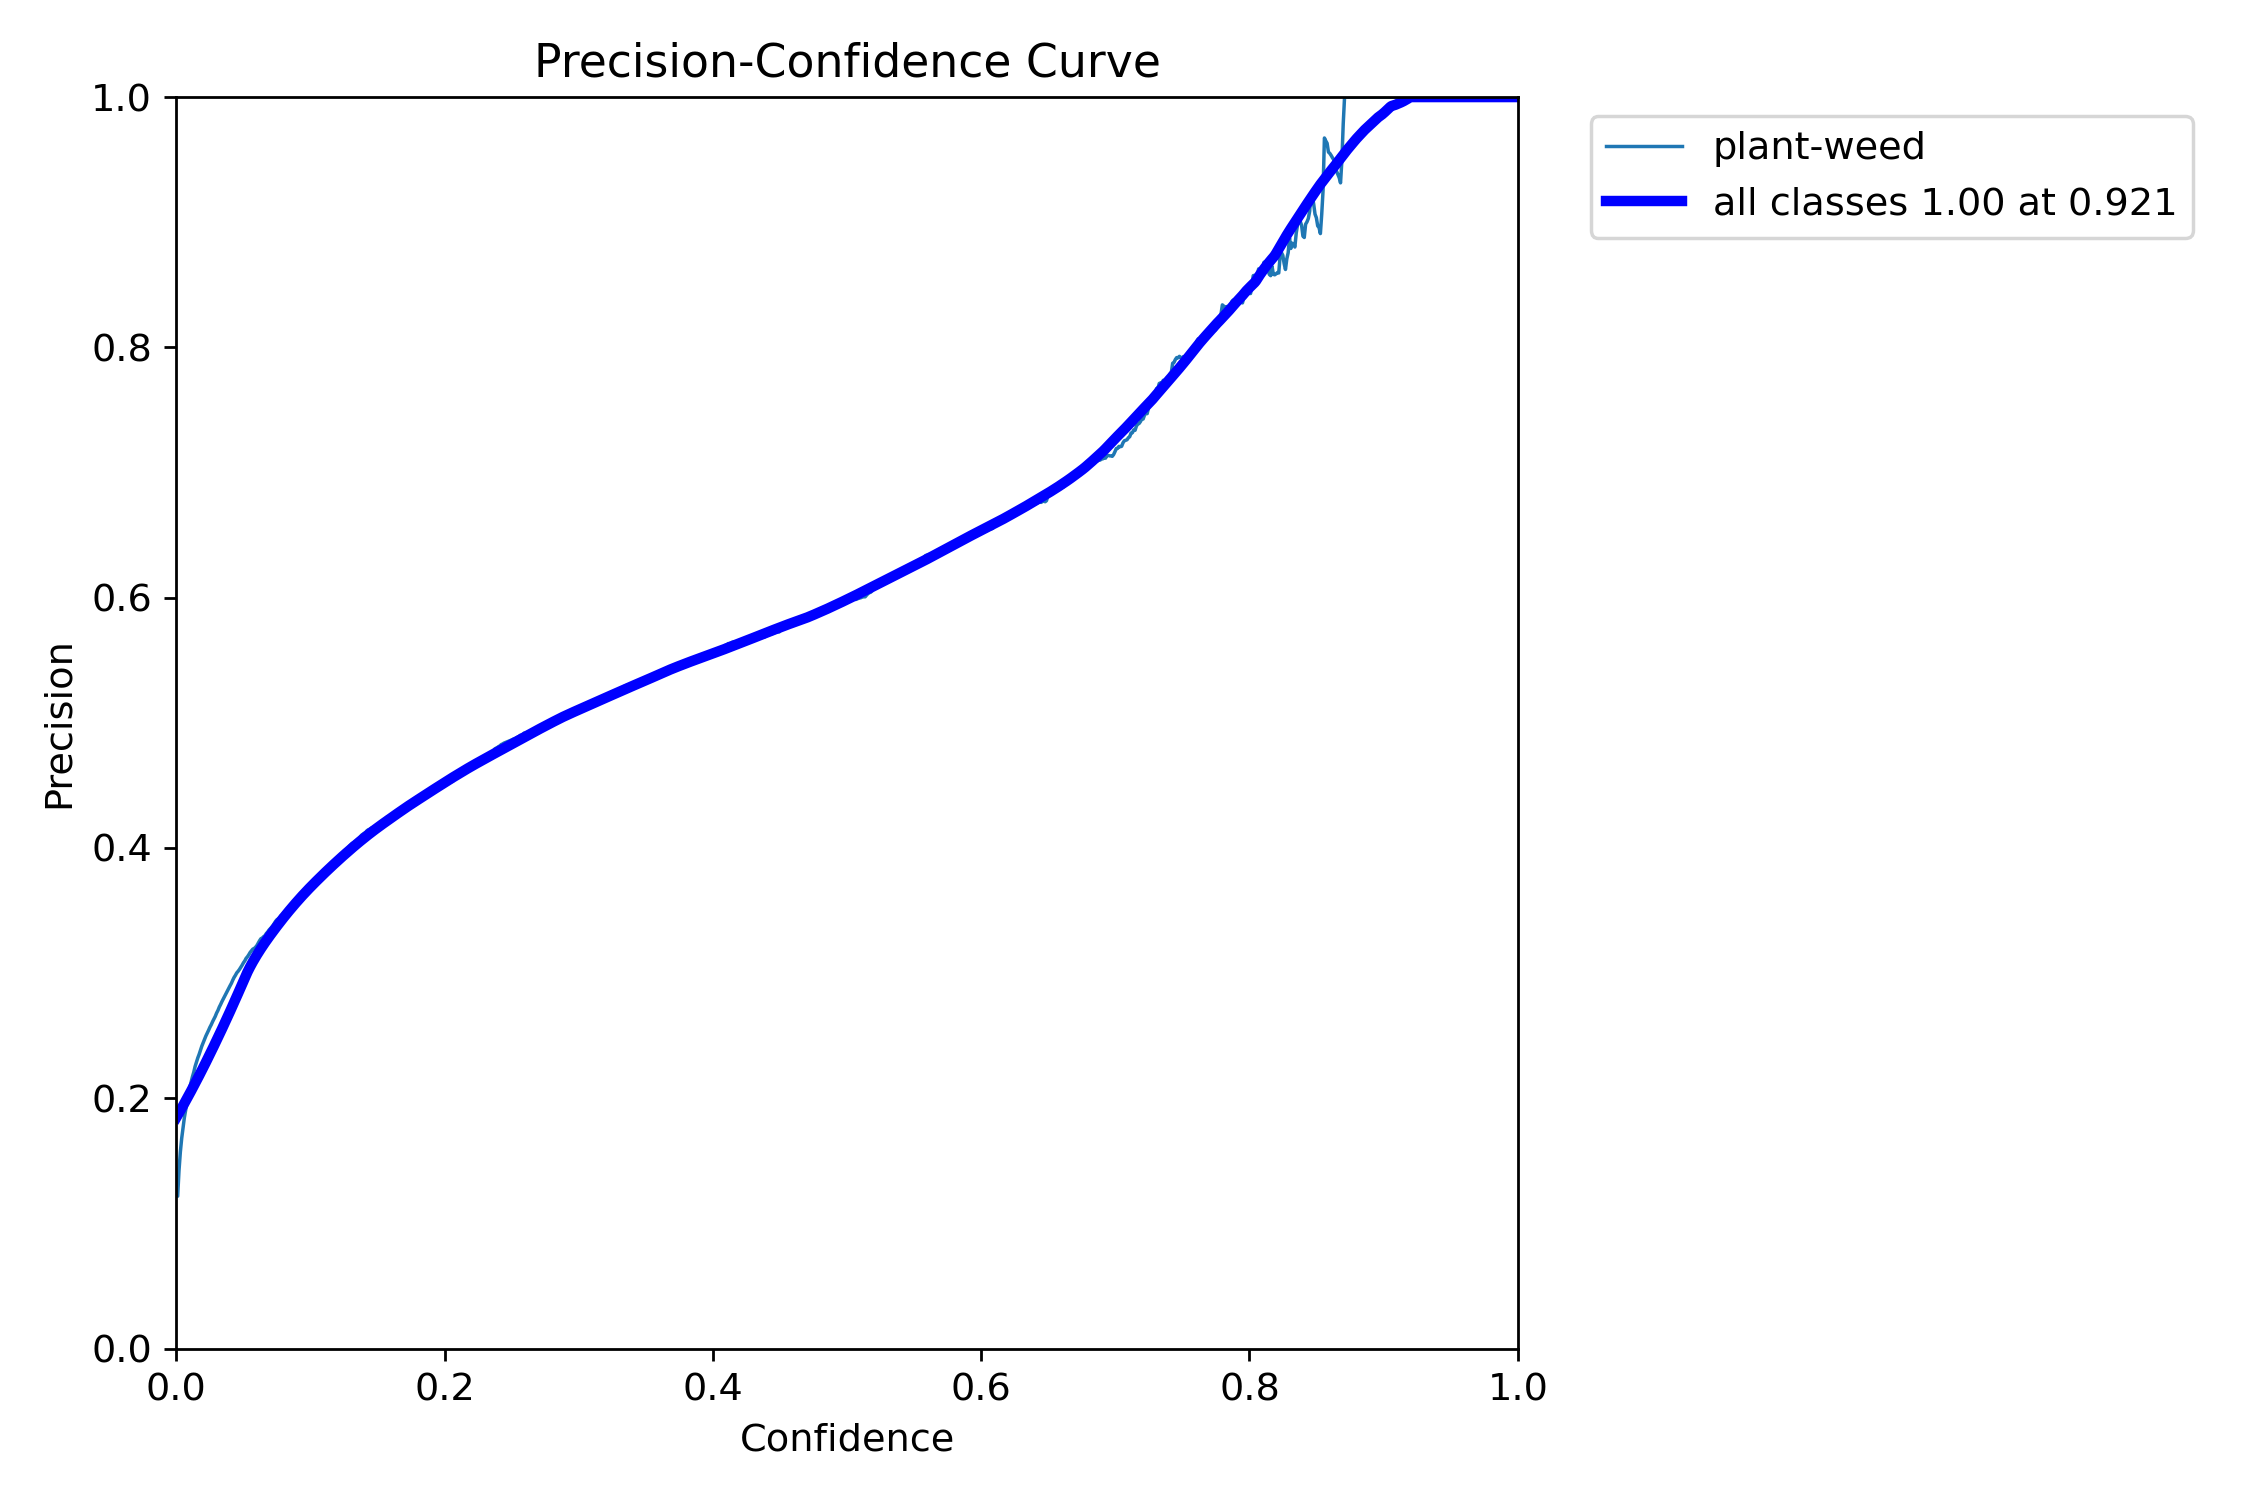

In [84]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

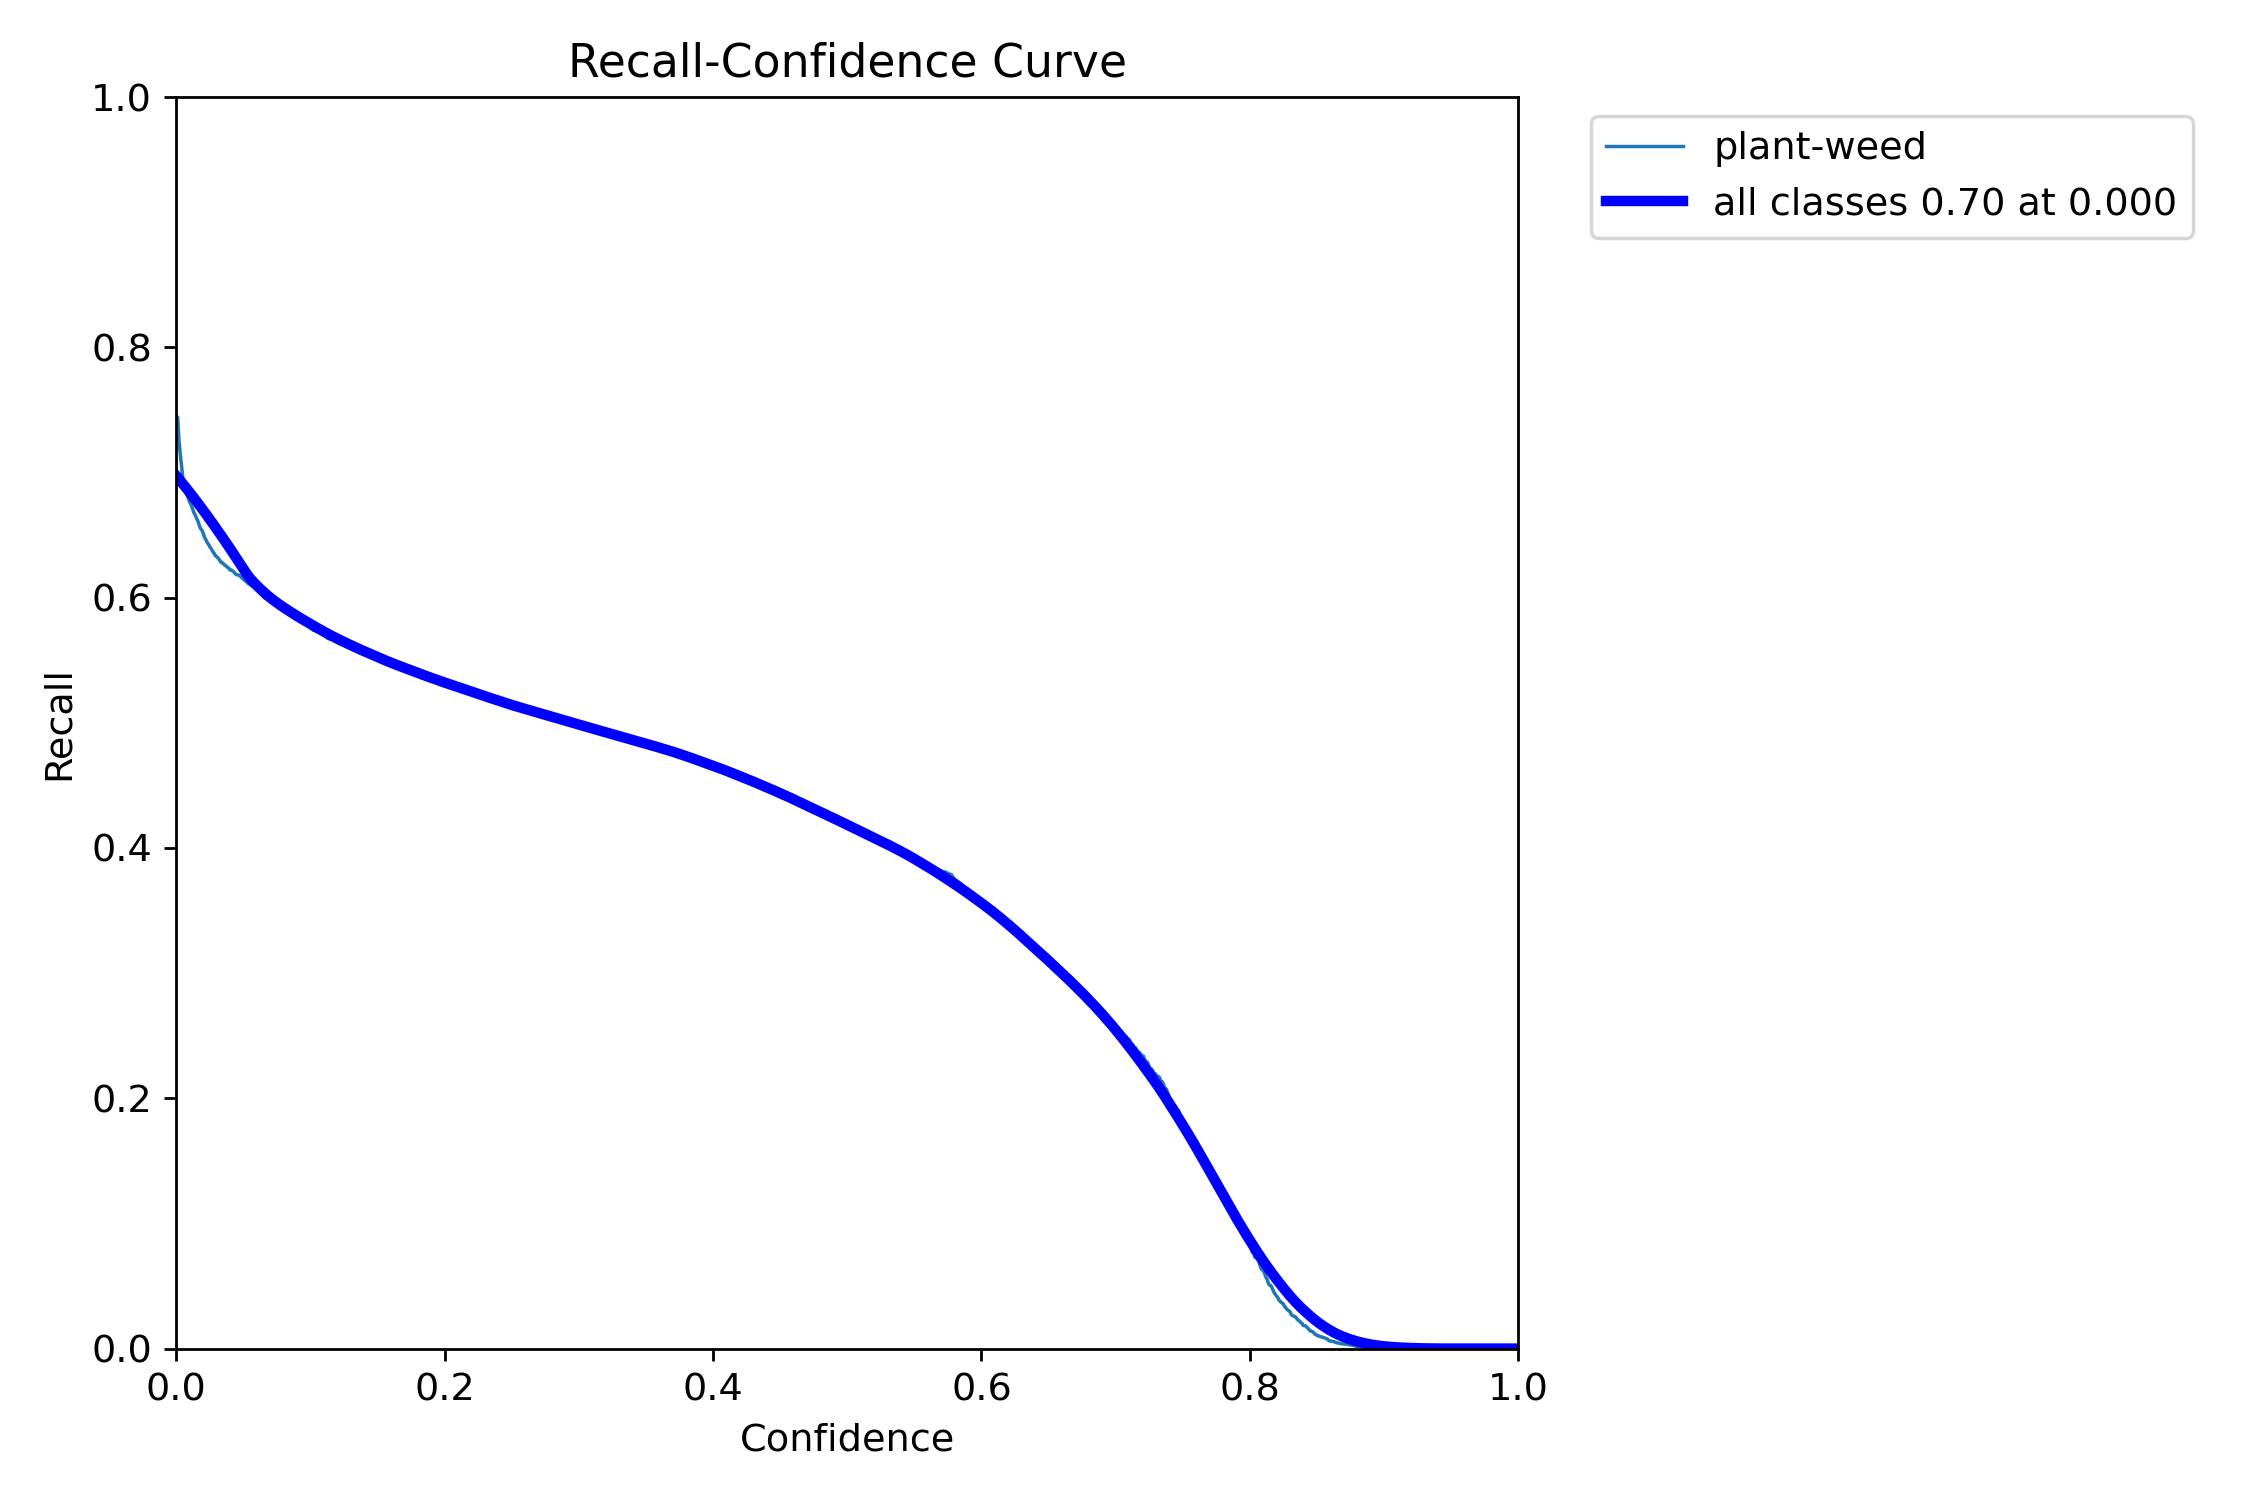

In [85]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

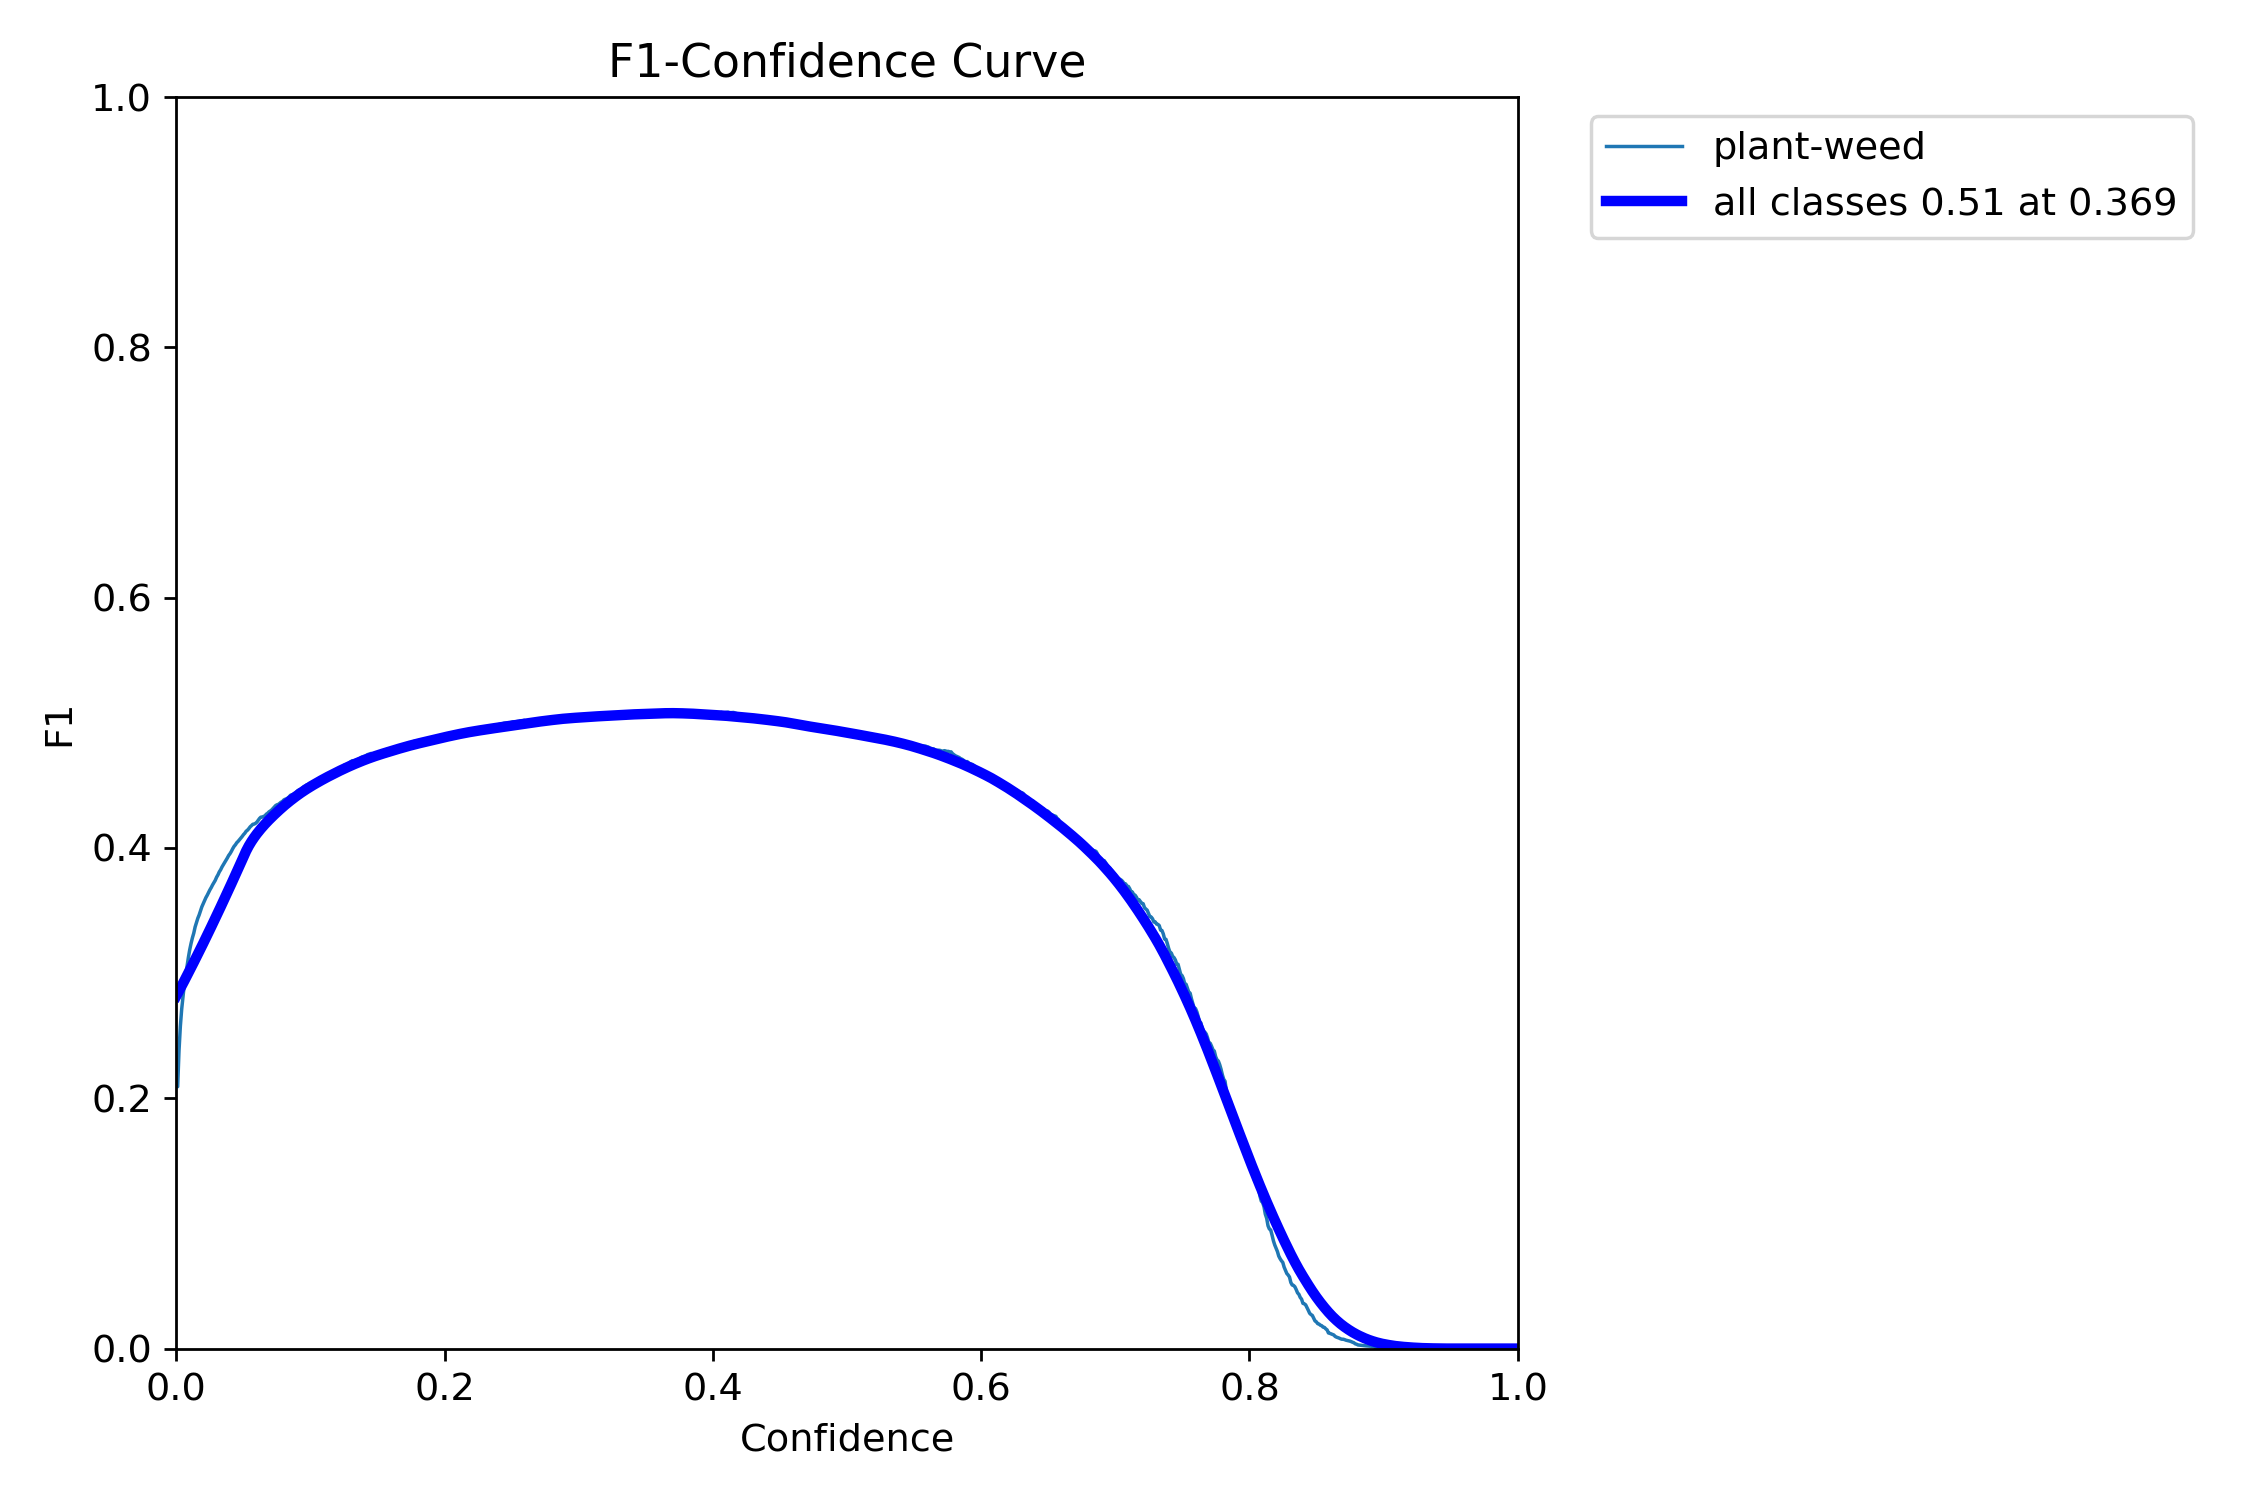

In [86]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

----

# Métricas generales

In [87]:
# best_models.index = [f"{i}º TRAIN" for i in range(1, len(best_models)+1)]

In [88]:
experiment_number = [f"{i}º TRAIN" for i in range(1, len(best_models)-1)]
experiment_number.append('REF1')
experiment_number.append('REF2')
best_models.index = experiment_number

In [89]:
best_models.sort_values(by='metrics/mAP50(B)', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
1º TRAIN,46,573.463,1.91756,1.15843,1.31109,0.51404,0.45852,0.44114,0.14690,2.40121,1.45162,1.74985,0.001846,0.001846,0.001846,49.483333
2º TRAIN,30,472.054,2.04139,1.29324,1.39094,0.48374,0.46717,0.44181,0.14581,2.36342,1.53153,1.70635,0.001874,0.001874,0.001874,57.085333
REF1,200,2360.980,1.73859,0.96404,1.30580,0.53938,0.47005,0.45095,0.14532,2.52551,1.35440,1.93694,0.001354,0.001354,0.001354,88.179167
REF2,245,2251.920,1.25400,0.68498,1.01302,0.54078,0.47725,0.45351,0.14676,2.66094,1.39187,2.03566,0.001034,0.001034,0.001034,67.957500


## History Graphs

In [90]:
# Define function to plot metrics
def plot_metric(metric, ylabel, title):
    plt.figure(figsize=(15, 5))
    if len(best_models) < 1: print('ALERTA: No hay datos para realizar las gráficas.')
    if len(best_models) >= 1: plt.plot(df1["epoch"], df1[metric], label="Training 1", linestyle="--", marker="o", markersize=4)
    if len(best_models) >= 2: plt.plot(df2["epoch"], df2[metric], label="Training 2", linestyle="--", marker="s", markersize=4)
    if len(best_models) >= 3: plt.plot(df3["epoch"], df3[metric], label="Training 3", linestyle="--", marker="d", markersize=4)
    if len(best_models) >= 4: plt.plot(df4["epoch"], df4[metric], label="Training 4", linestyle="--", marker="^", markersize=4)
    if len(best_models) >= 5: plt.plot(df5["epoch"], df5[metric], label="Training 5", linestyle="--", marker="v", markersize=4)
    if len(best_models) >= 6: plt.plot(df6["epoch"], df6[metric], label="Training 6", linestyle="--", marker="p", markersize=4)
    if len(best_models) >= 7: print("La cantidad de modelos entrenados supera la configuración del gráfico, por favor ajustar la función 'plot_metric()'")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training and Validation Losses

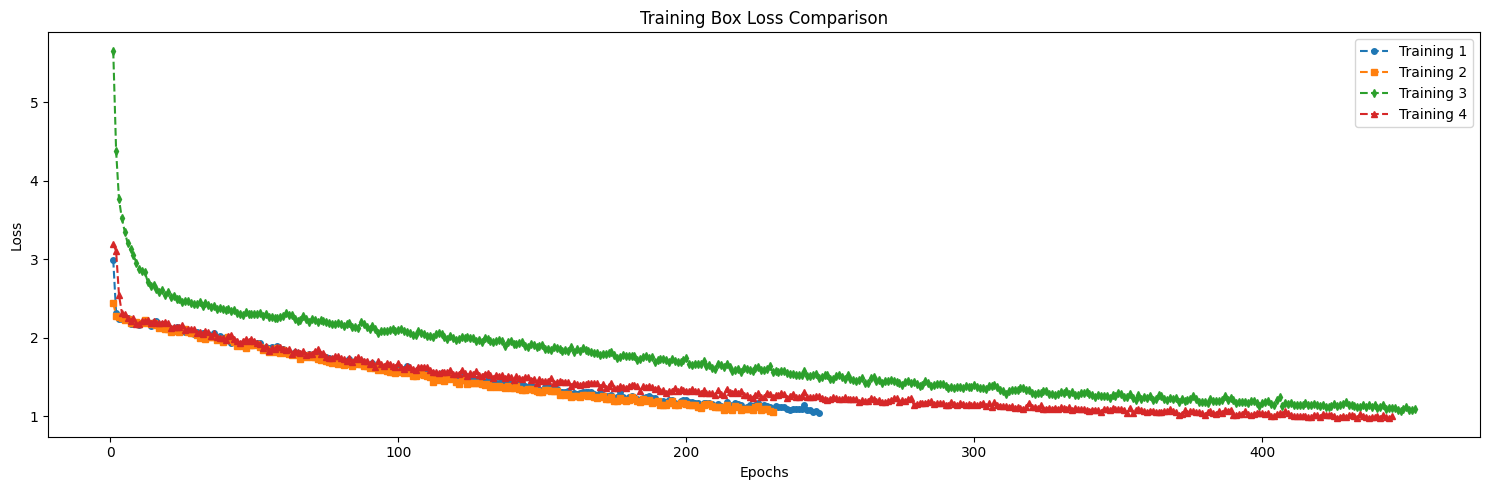

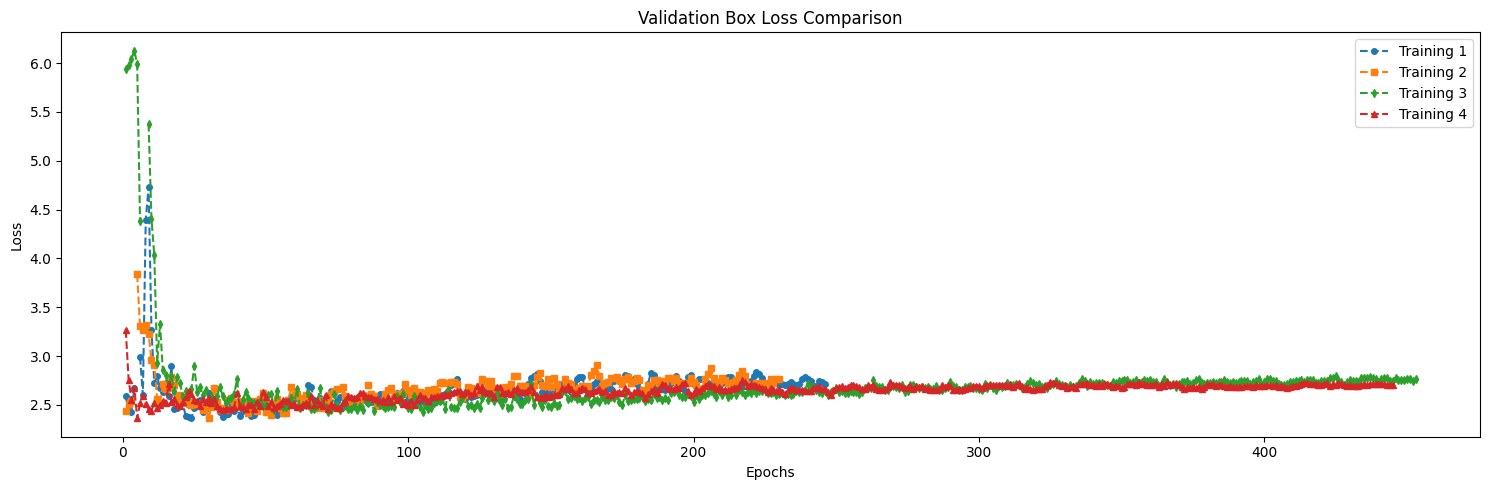

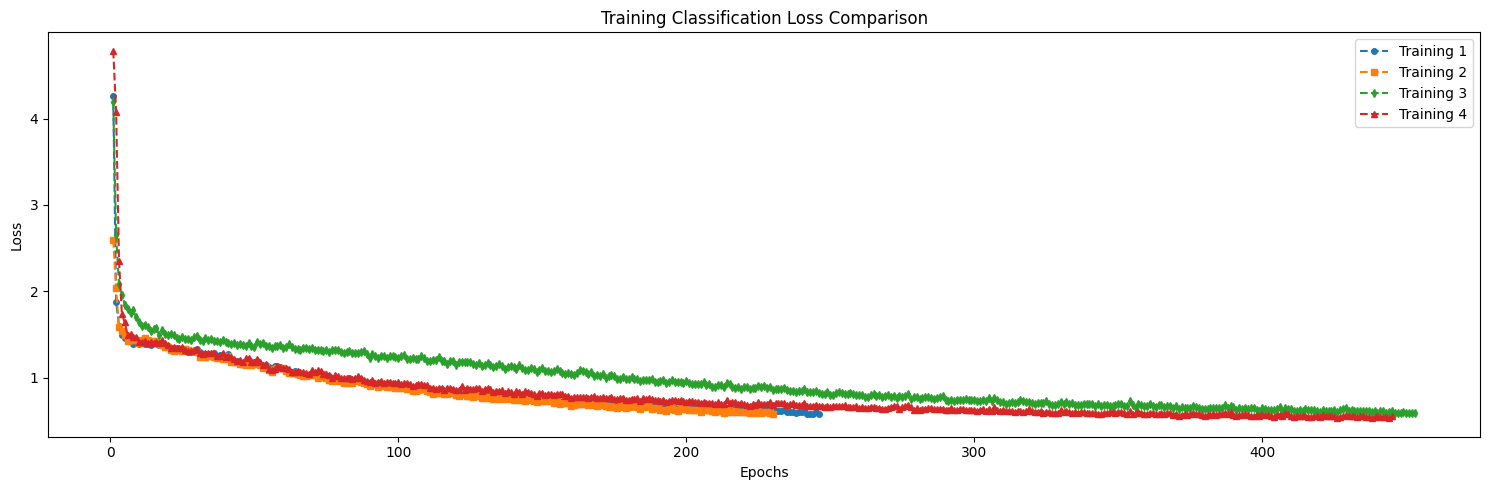

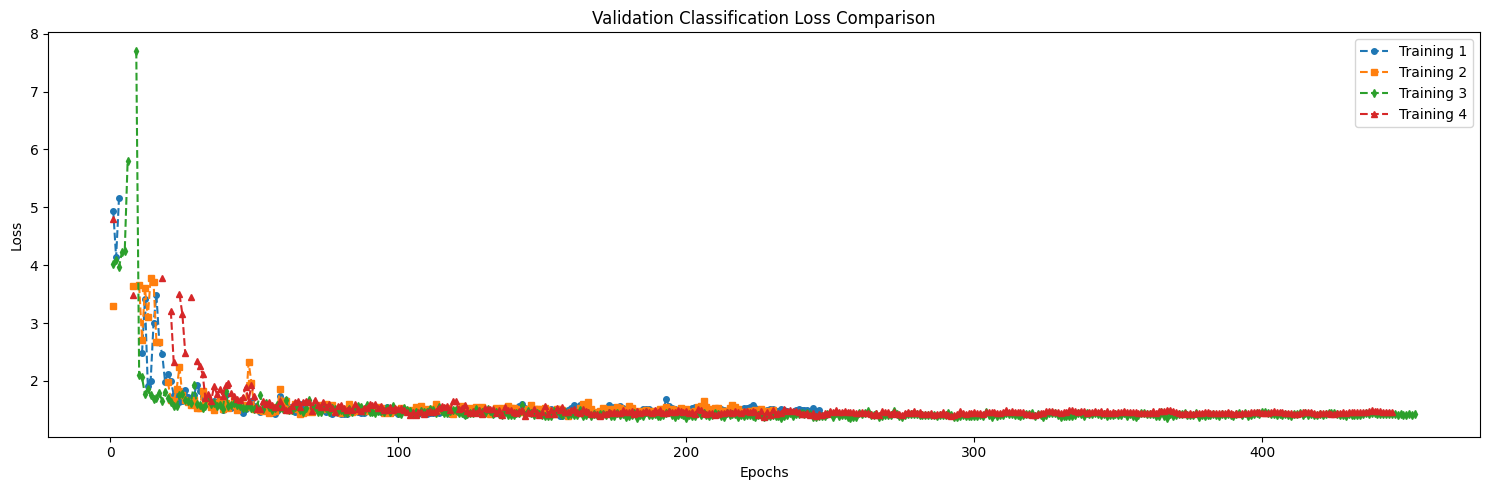

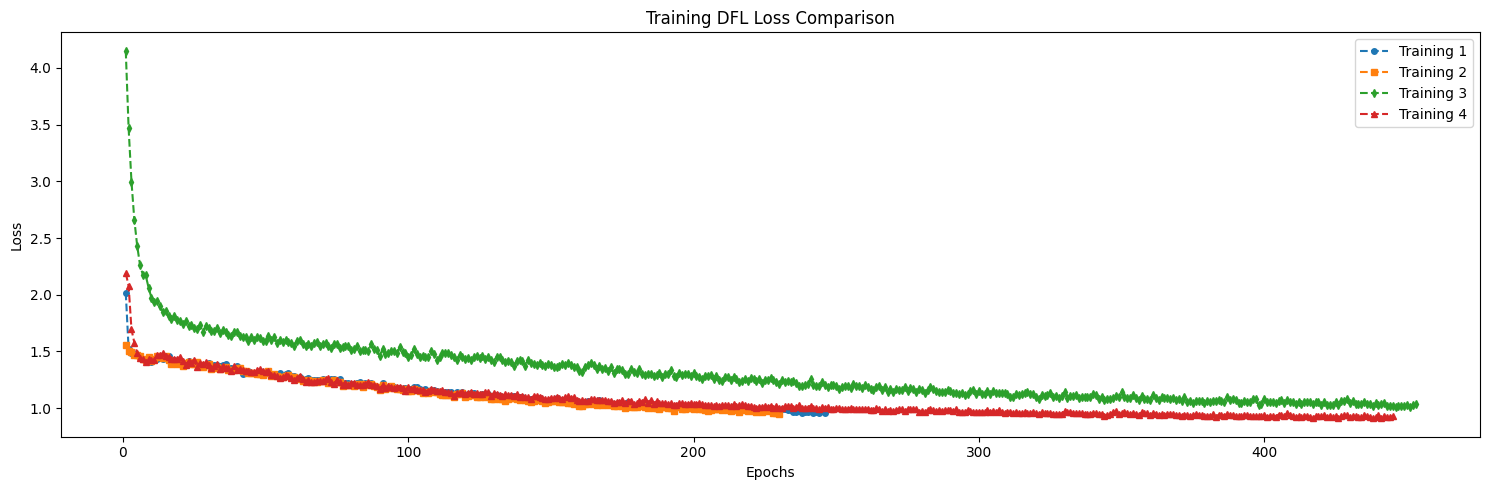

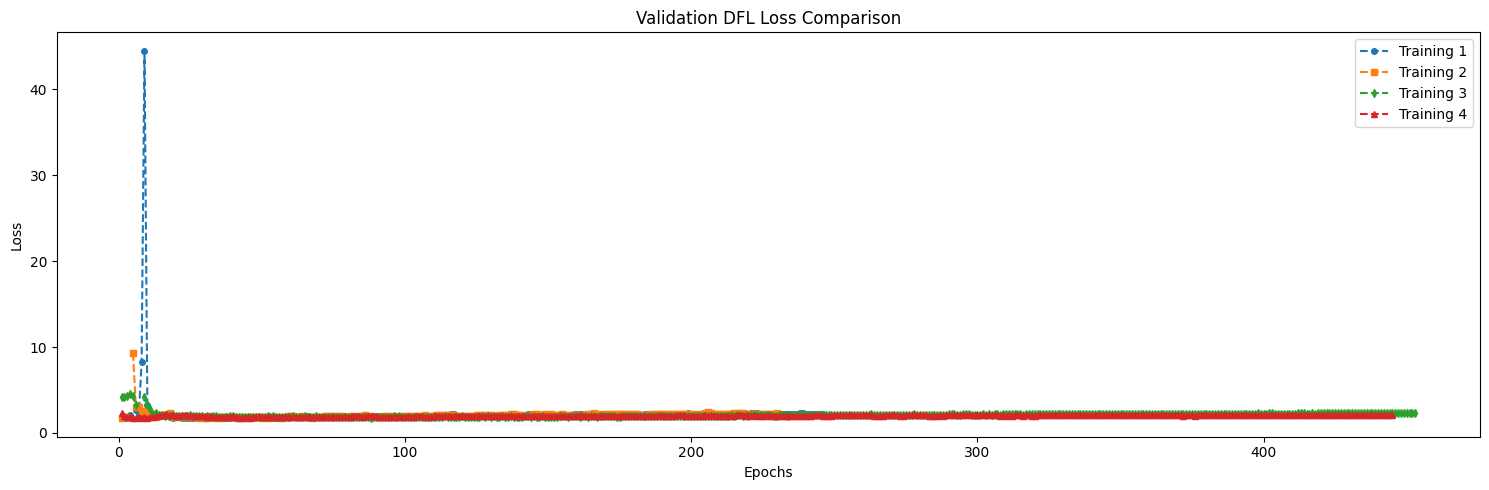

In [91]:
# Plot Training and Validation Losses
plot_metric("train/box_loss", "Loss", "Training Box Loss Comparison")
plot_metric("val/box_loss", "Loss", "Validation Box Loss Comparison")

plot_metric("train/cls_loss", "Loss", "Training Classification Loss Comparison")
plot_metric("val/cls_loss", "Loss", "Validation Classification Loss Comparison")

plot_metric("train/dfl_loss", "Loss", "Training DFL Loss Comparison")
plot_metric("val/dfl_loss", "Loss", "Validation DFL Loss Comparison")

### Performance Metrics

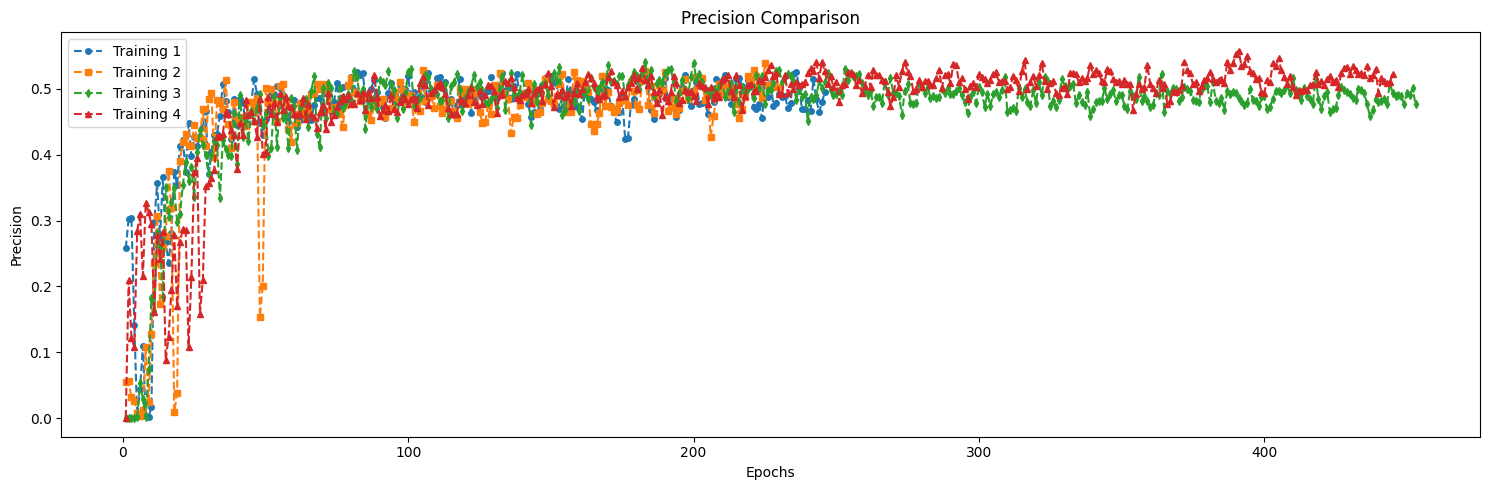

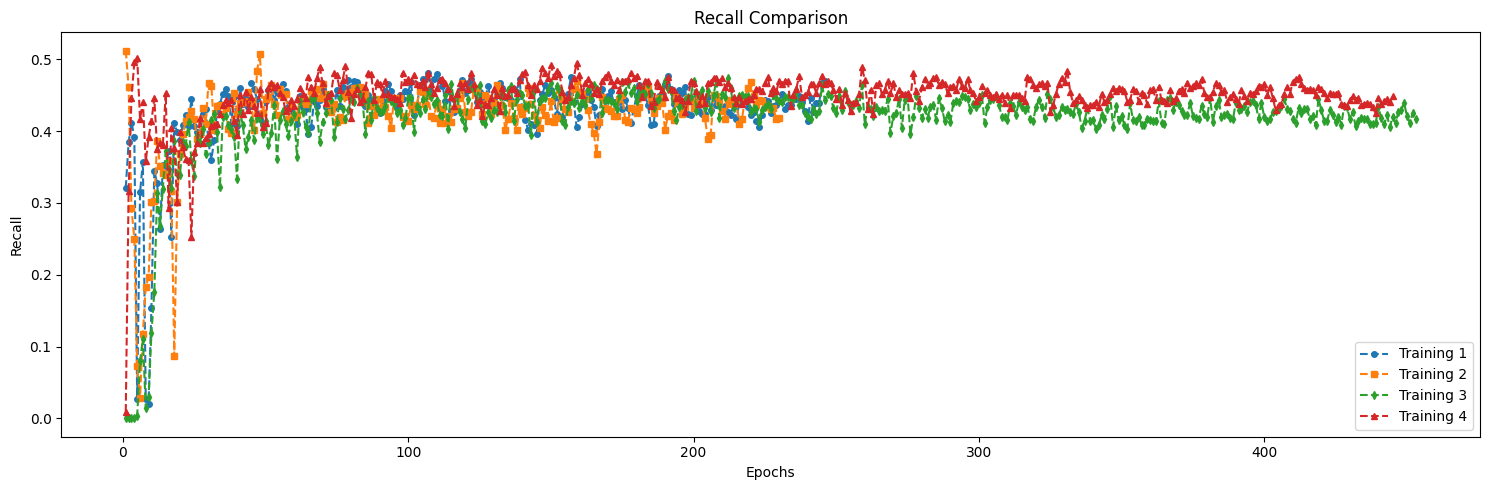

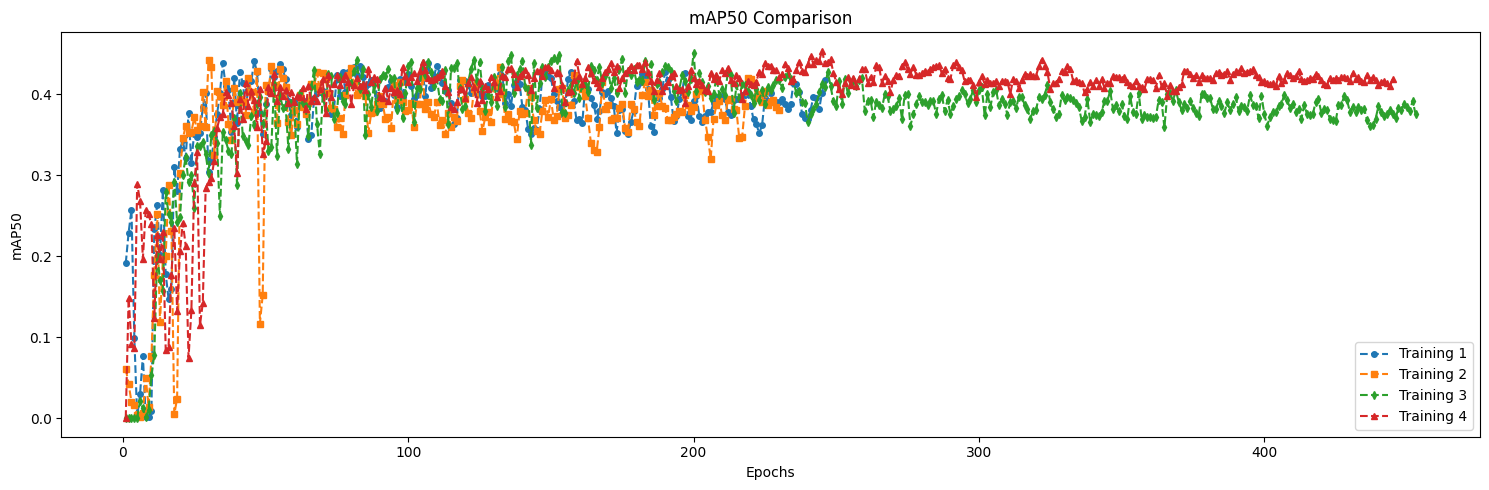

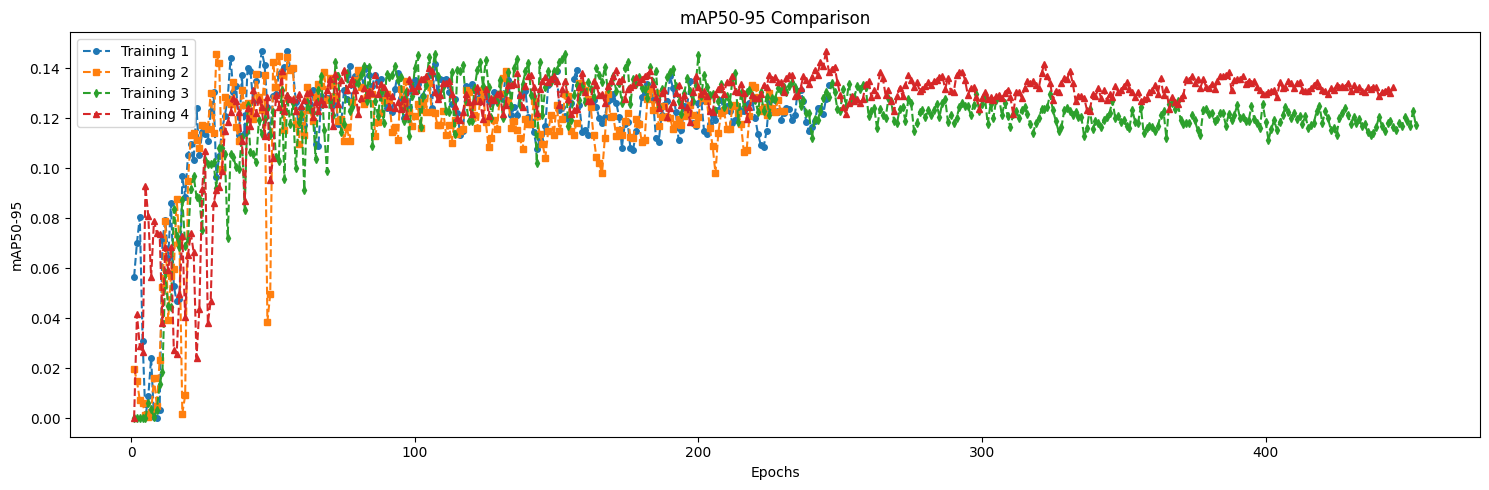

In [92]:
# Plot Performance Metrics
plot_metric("metrics/precision(B)", "Precision", "Precision Comparison")
plot_metric("metrics/recall(B)", "Recall", "Recall Comparison")
plot_metric("metrics/mAP50(B)", "mAP50", "mAP50 Comparison")
plot_metric("metrics/mAP50-95(B)", "mAP50-95", "mAP50-95 Comparison")

### Learning Rate

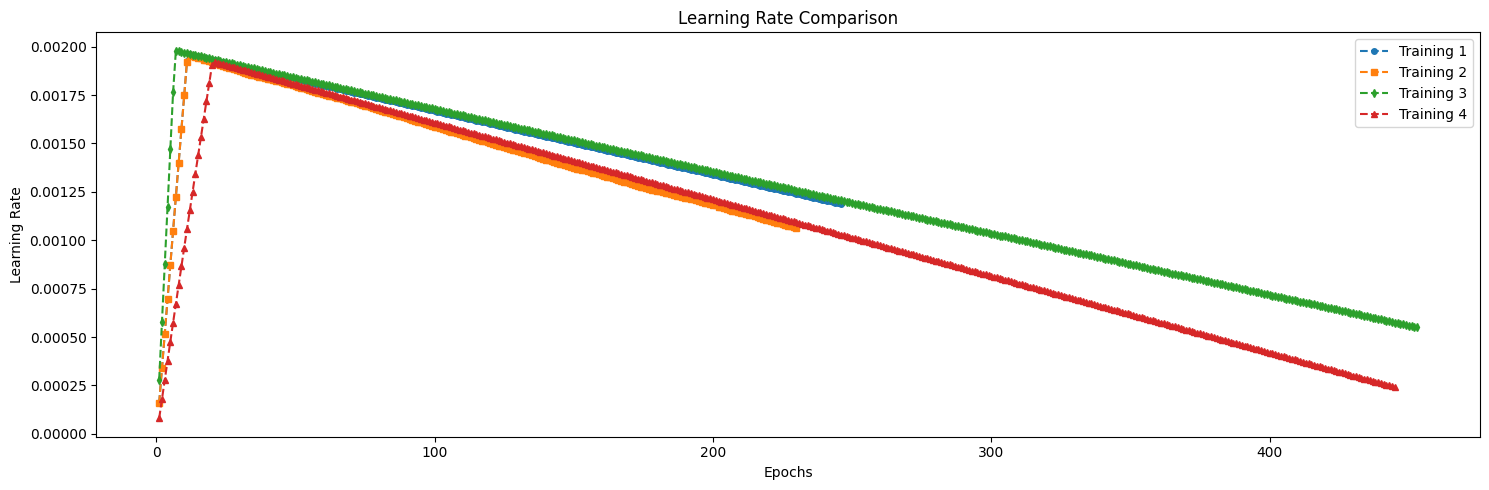

In [93]:
# Plot Learning Rate
plot_metric("lr/pg0", "Learning Rate", "Learning Rate Comparison")

## Comparative Graphs

In [94]:
#SETUP:
log_scale = False # Apply log scale to the y-axis

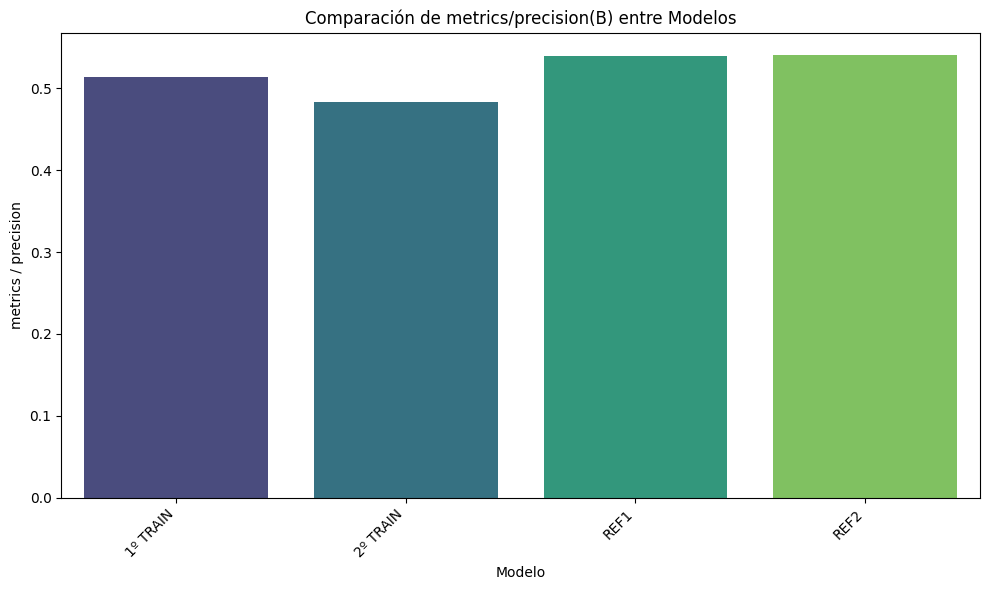

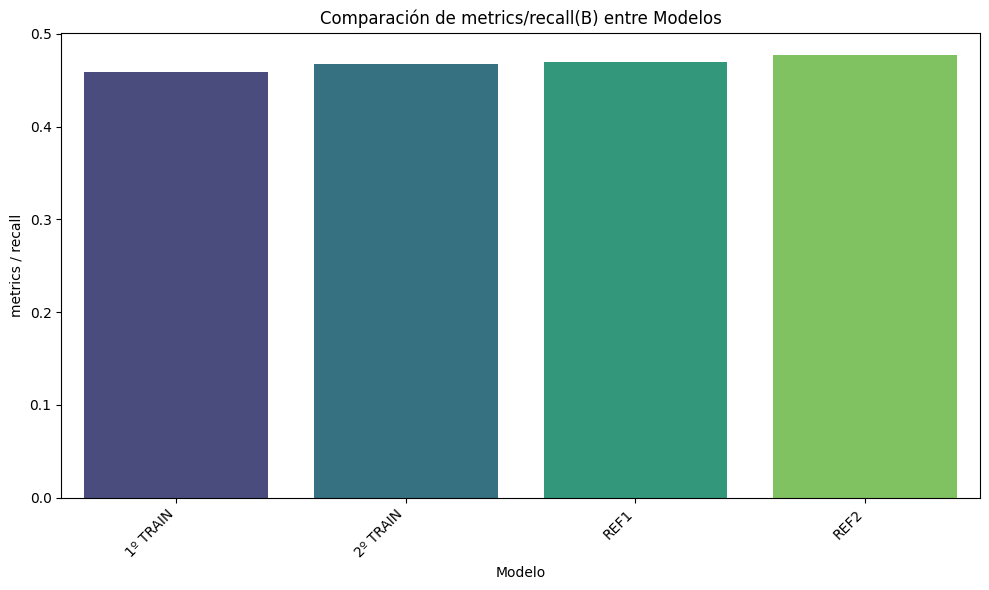

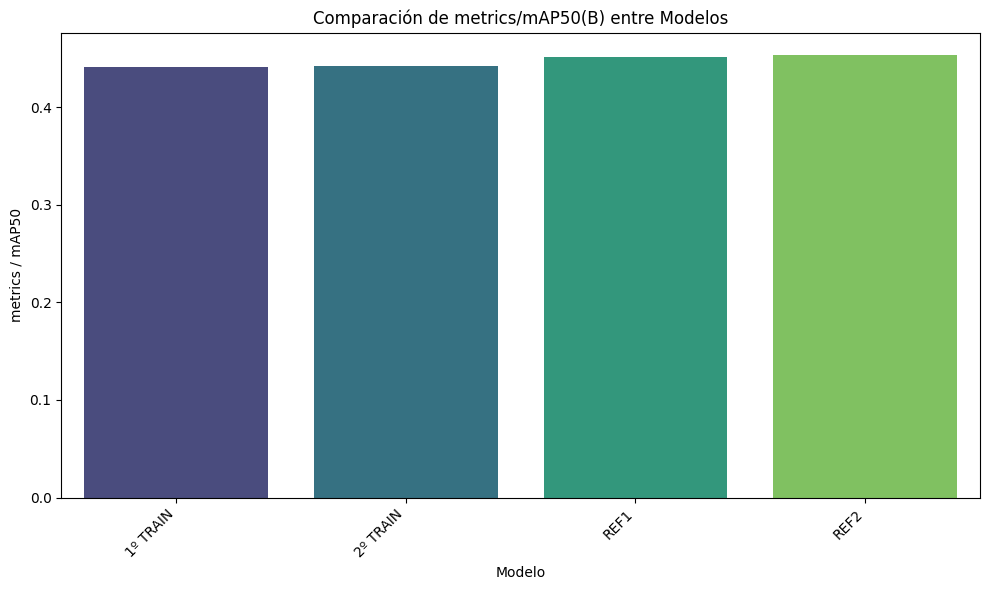

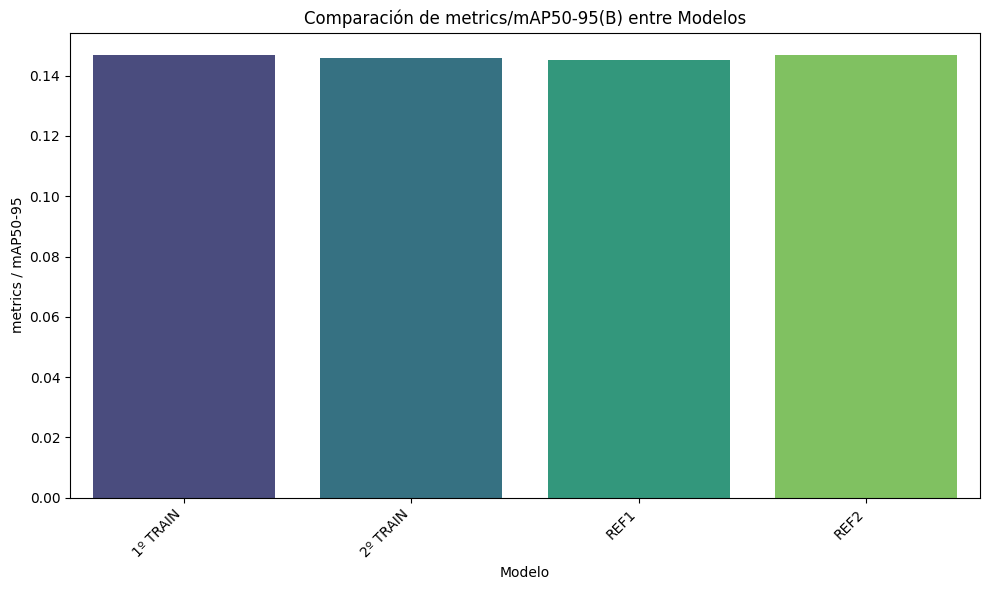

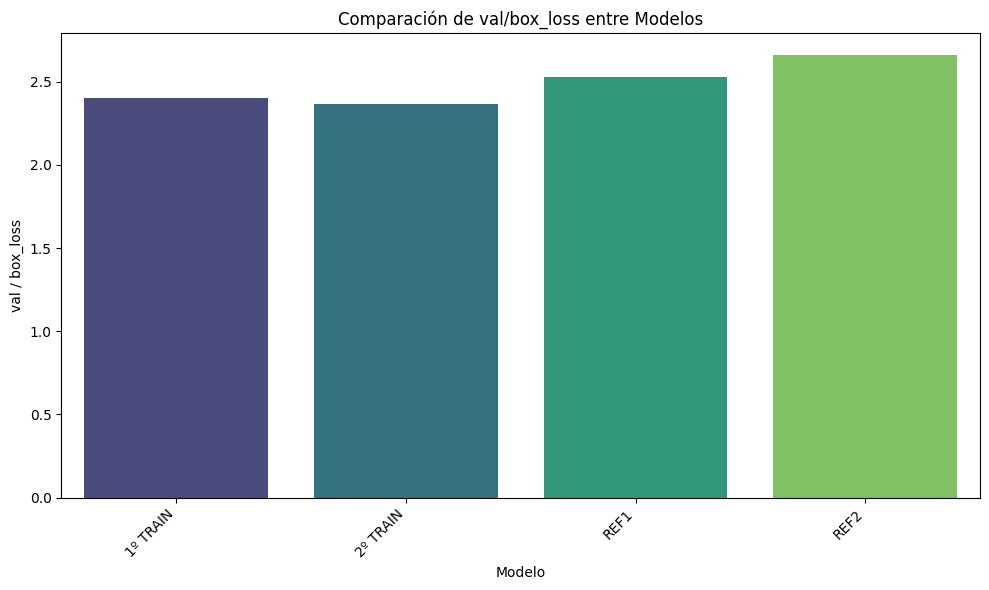

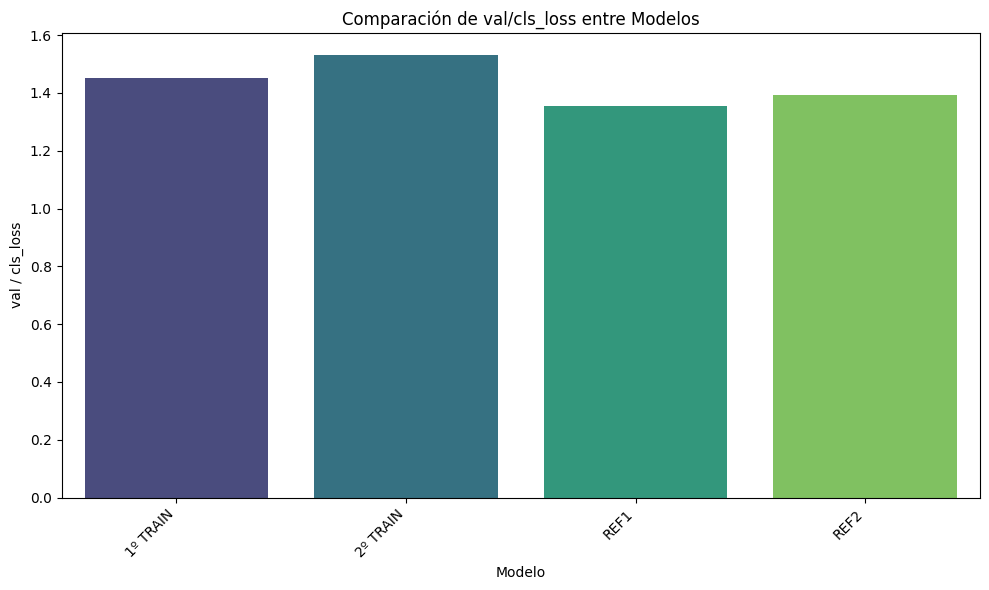

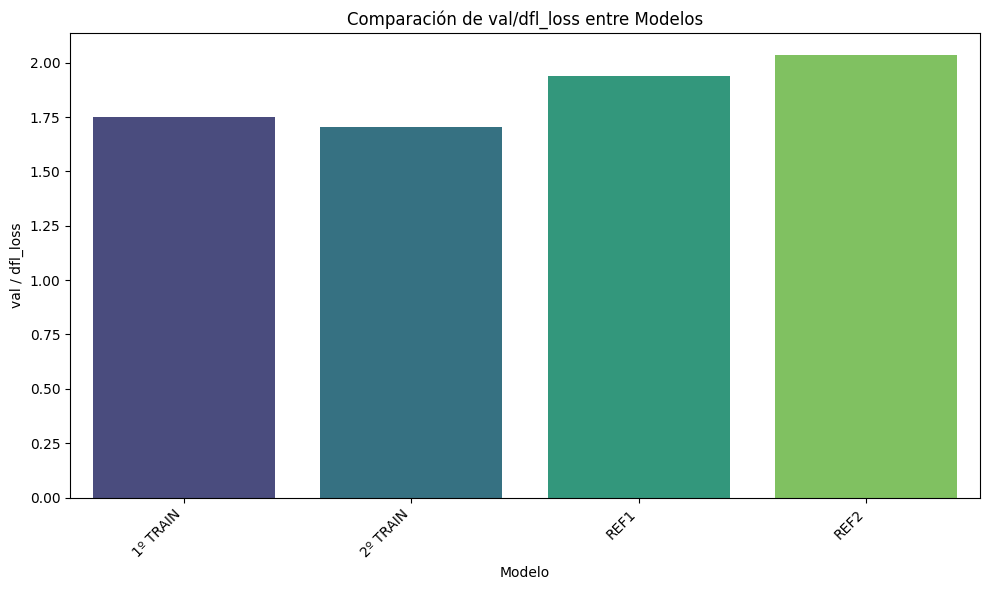

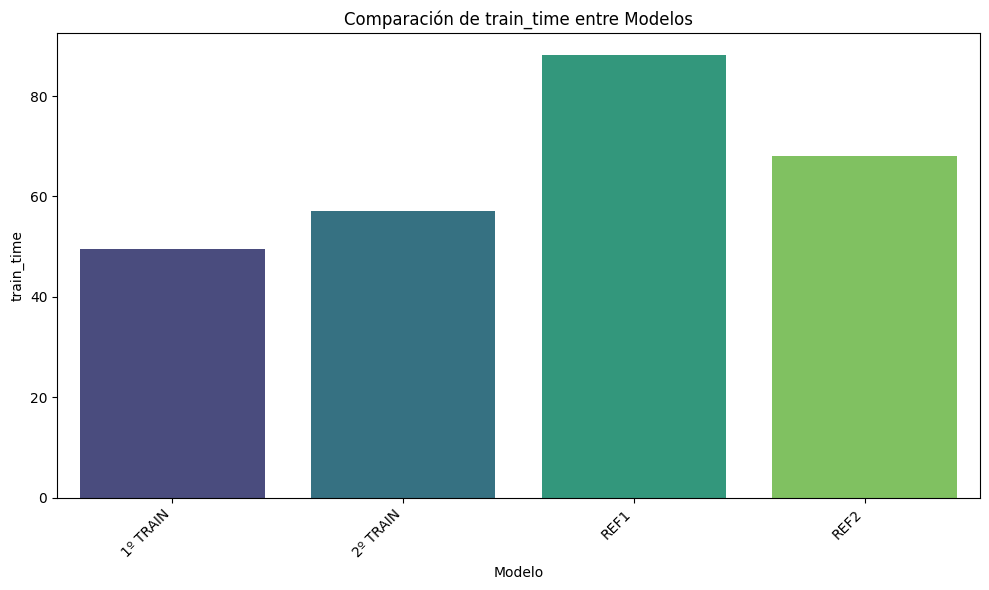

In [95]:
import seaborn as sns

metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
# print(f"Generando gráficos para las métricas: {metrics_to_plot}")

for metric in metrics_to_plot:

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
    sns.barplot(x='Model', y=metric, data=df_plot, hue='Model', palette='viridis', dodge=False, legend=False)

    plt.yscale('log') if log_scale else None 
    plt.title(f'Comparación de {metric} entre Modelos')
    plt.xlabel('Modelo')
    plt.ylabel(metric.replace('(B)', '').replace('/', ' / '))  # Clean up the y-axis label
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if they are long
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")

## Lollipop Graphs

In [96]:
#SETUP:
horizontal = False # Set to True for horizontal lollipop chart
log_scale = False # Apply log scale to the y-axis
sort = True # Sort values for better visual flow
sort_type = 'ascending' # Options: 'ascending', 'descending'

Orenamiento: ascending


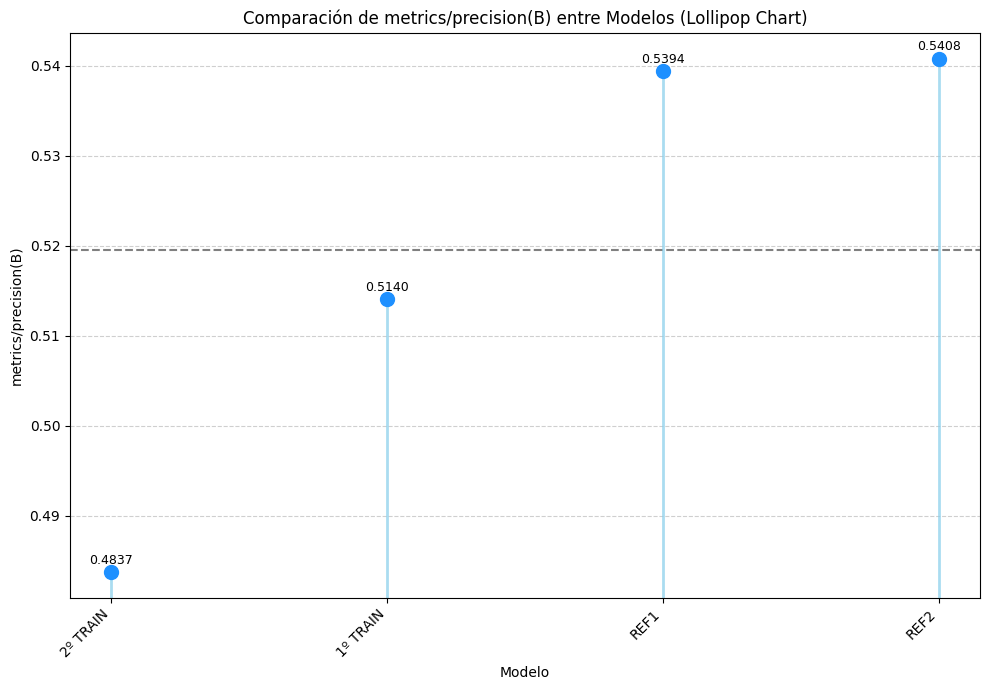

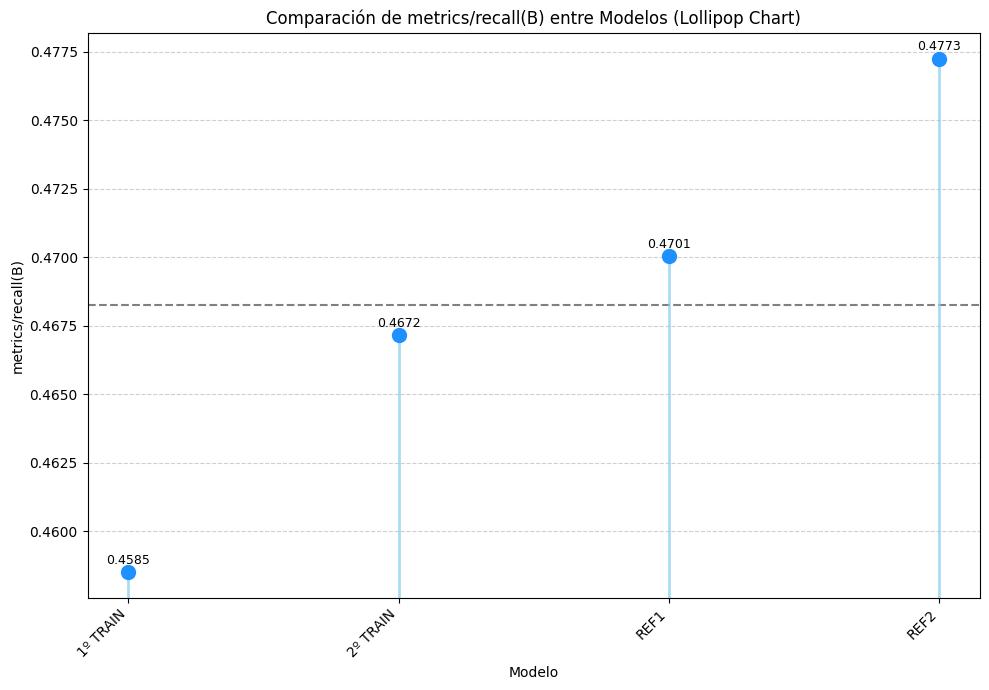

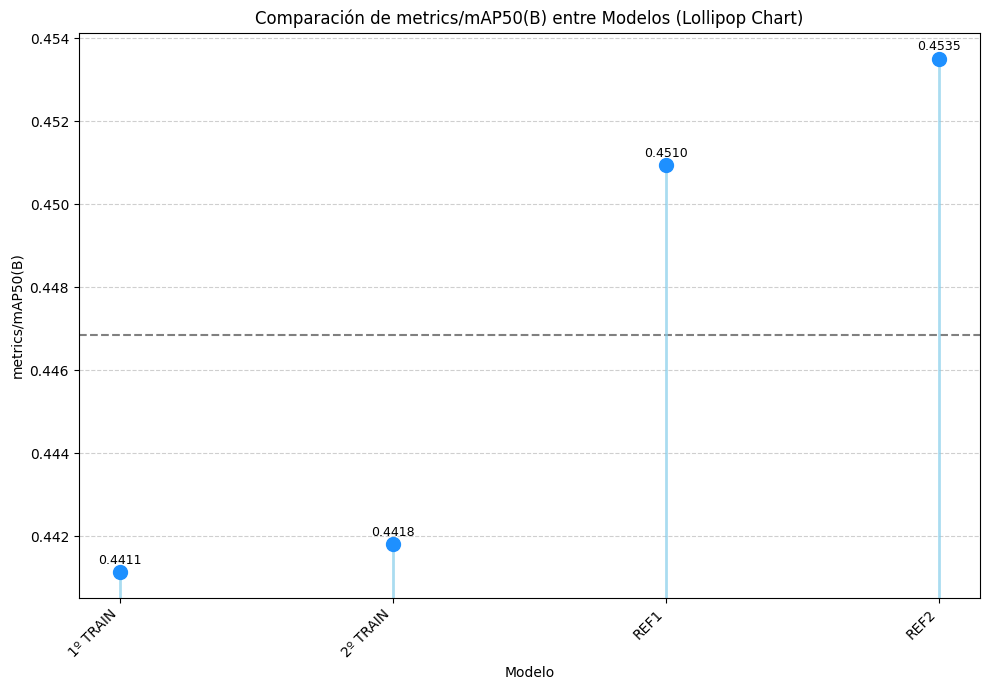

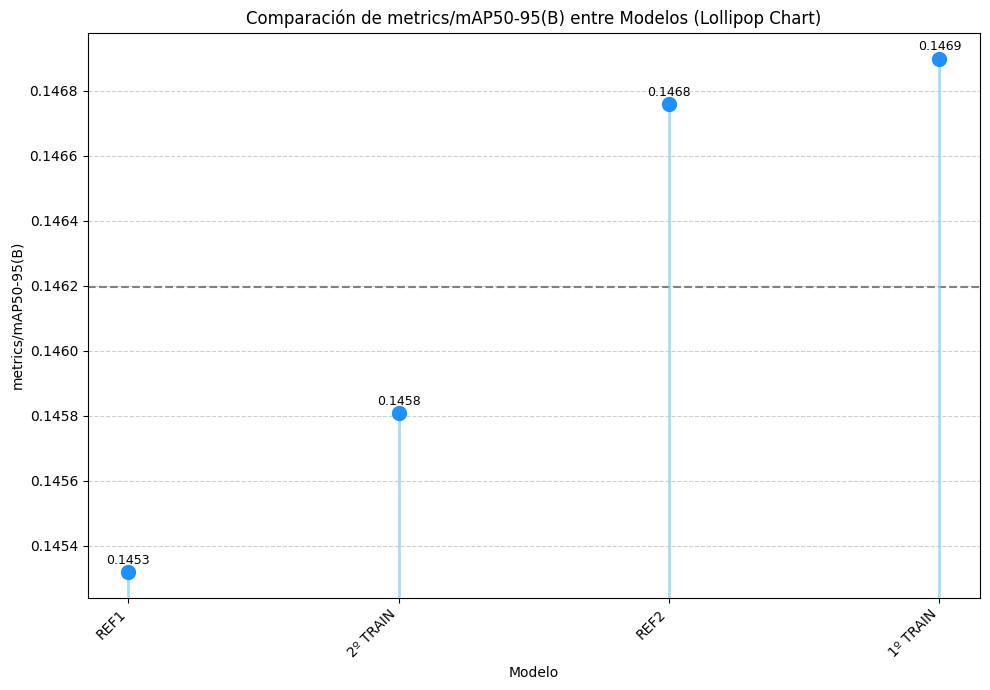

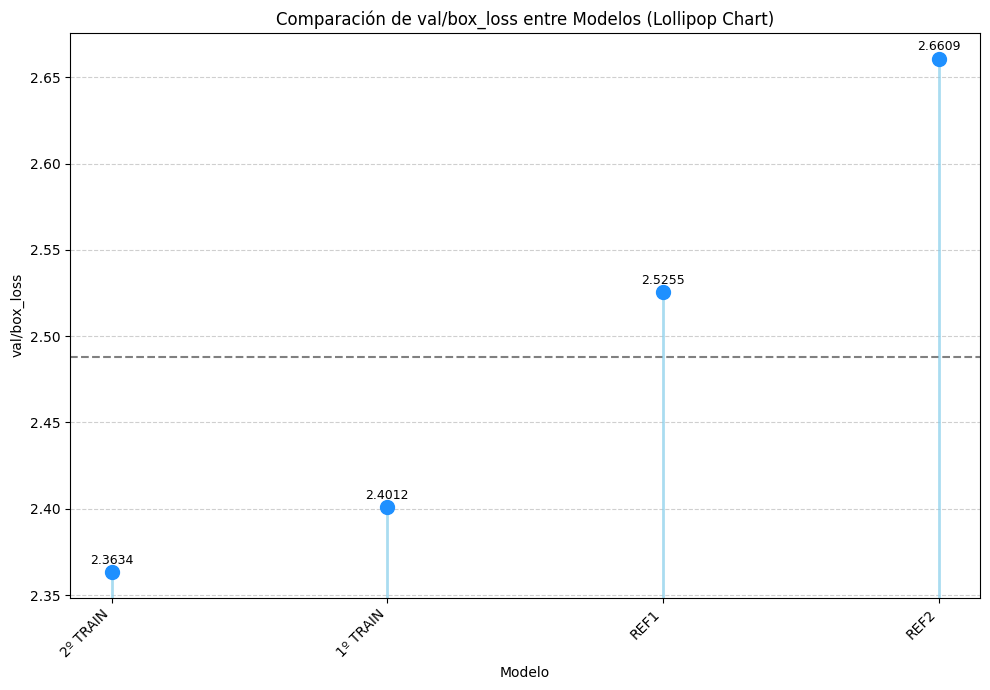

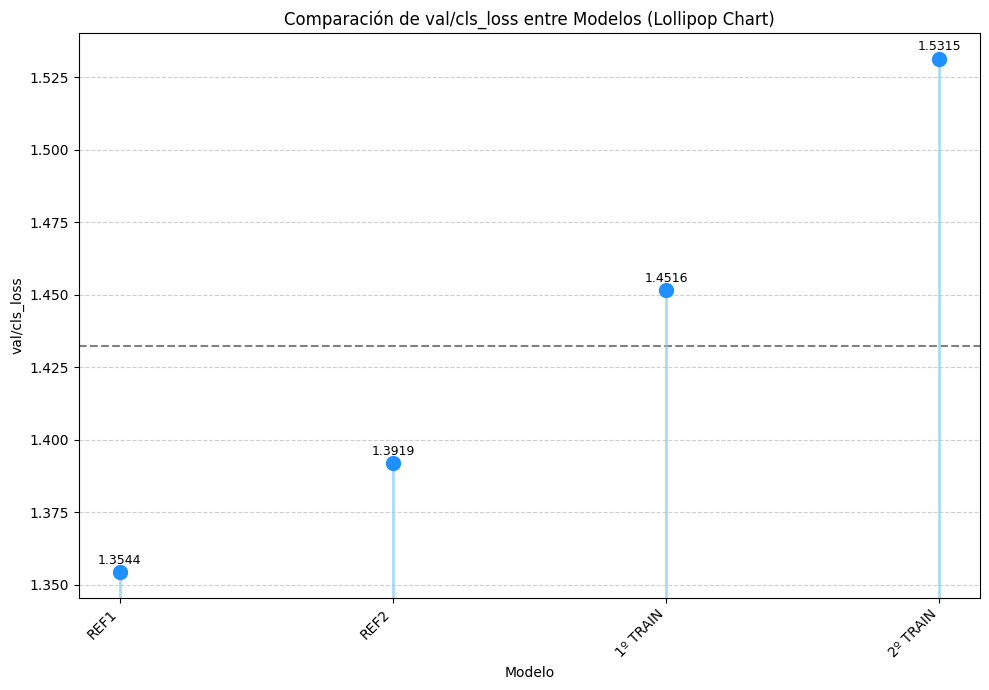

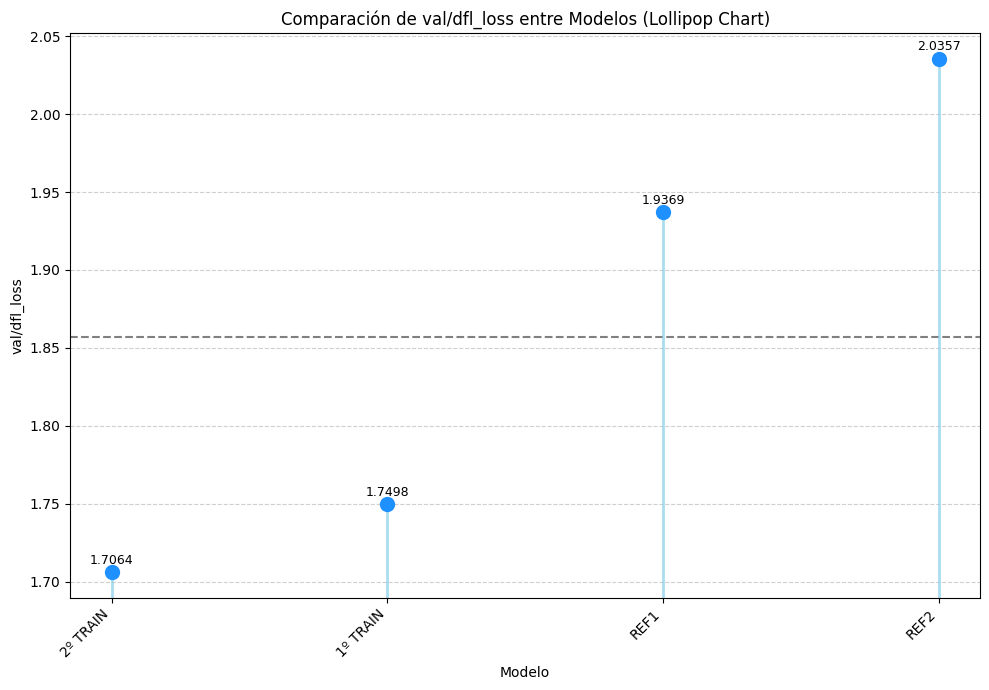

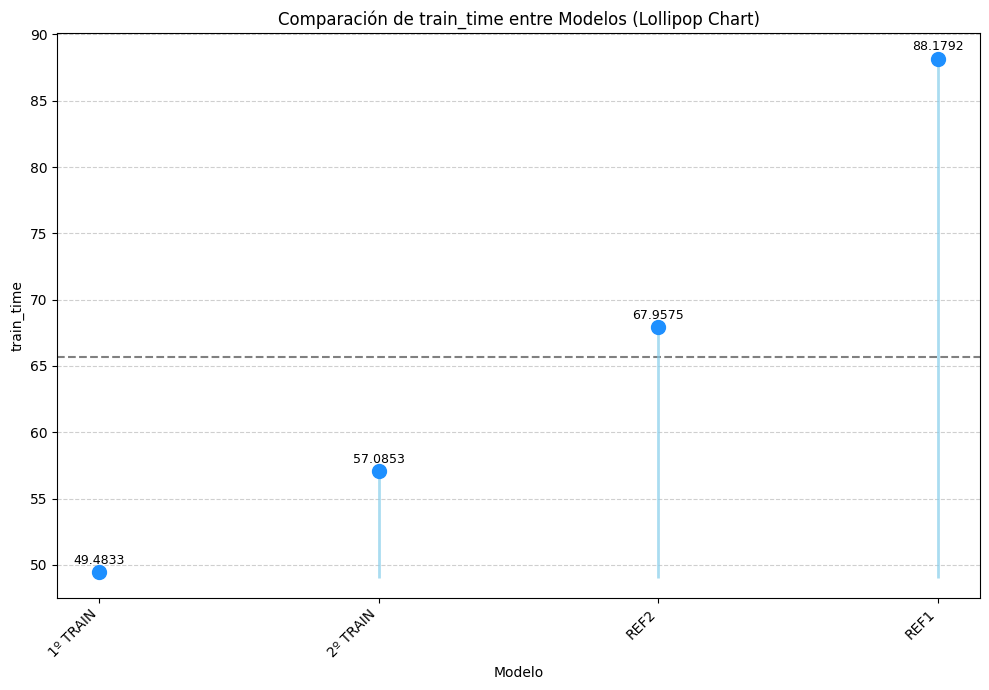

In [97]:
metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
#print(f"Generando gráficos para las métricas: {metrics_to_plot}")
print(f"Orenamiento: {sort_type}") if sort else None

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

for  metric in metrics_to_plot:

    # Preparamos el DataFrame para seaborn (opcional pero a veces útil)
    # Usaremos el índice directamente en este caso.
    df_plot = best_models.dropna(subset=[metric]).copy()
    df_plot['Model'] = df_plot.index

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    # Calculate the average value
    average_value = df_plot[metric].mean()

    # Sort values for potentially better visual flow (optional)
    if sort:
        match sort_type:
            case 'ascending':
                df_plot = df_plot.sort_values(by=metric, ascending=True)
            case 'descending':
                df_plot = df_plot.sort_values(by=metric, ascending=False)
            case _:
                print(f"Invalid sort type '{sort_type}'. No sorting applied.")

    plt.figure(figsize=(10, 7)) # Slightly taller figure might be nice

    # Define the y-values (the metric) and x-values (numerical index for models)
    values = df_plot[metric]
    axis = np.arange(len(df_plot)) # 0, 1, 2, ...

    # Determine the baseline for the stems (lines)
    # Start from slightly below the minimum value to emphasize differences
    plot_min_val = values.min()
    plot_max_val = values.max()
    stem_baseline = plot_min_val * 0.99 # Start stems just below the minimum point
    margin = (plot_max_val - plot_min_val) * 0.05 # Adjust y-axis limits for zoom, adding a margin

    if not horizontal:
        # --- Create the Lollipop Plot ---
        plt.yscale('log') if log_scale else None # Apply log scale to y-axis for vertical plot
        plt.ylim(max(0, plot_min_val - margin), plot_max_val + margin) # Ensure y_min not negative if data positive
    
        # Add average line
        plt.axhline(y=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create the 'stems' (vertical lines)
        plt.vlines(x=axis, ymin=stem_baseline, ymax=values, color='skyblue', alpha=0.7, linewidth=2)

        # Create the 'lollipops' (the dots at the top)
        plt.scatter(x=axis, y=values, color='dodgerblue', s=100, alpha=1, zorder=3) # zorder=3 makes dots appear on top

        # Add value labels next to the dots
        for i, txt in enumerate(values):
            plt.text(axis[i], values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly above dot
                    f'{txt:.4f}', # Format the number
                    ha='center', # Horizontal alignment
                    va='bottom', # Vertical alignment
                    fontsize=9)

        # Customize the plot
        plt.xlabel('Modelo')
        plt.ylabel(metric)

        # Set the x-axis ticks to be the model names
        plt.xticks(axis, df_plot['Model'], rotation=45, ha='right')

        # Add a light grid for easier comparison
        plt.grid(axis='y', linestyle='--', alpha=0.6)


    if horizontal:
        # --- Horizontal Lollipop (Alternative) ---
        plt.xscale('log') if log_scale else None # Apply log scale to x-axis for horizontal plot
        plt.xlim(max(0, plot_min_val - margin), plot_max_val + margin)

        # Add average line
        plt.axvline(x=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create horizontal lines (stems)
        plt.hlines(y=axis, xmin=stem_baseline, xmax=values, color='lightcoral', alpha=0.7, linewidth=2)

        # Create the dots
        plt.scatter(x=values, y=axis, color='firebrick', s=100, alpha=1, zorder=3)

        # Add value labels next to dots
        for i, txt in enumerate(values):
            plt.text(values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly right of dot
                    axis[i],
                    f'{txt:.4f}',
                    ha='left',
                    va='center',
                    fontsize=9)

        # Customize
        plt.xlabel(metric)
        plt.ylabel('Modelo')

        # Set the y-axis ticks to be the model names
        plt.yticks(axis, df_plot['Model']) # Set model names on y-axis ticks
        # Add a light grid for easier comparison
        plt.grid(axis='x', linestyle='--', alpha=0.6) # Grid on x-axis now
        

    plt.title(f'Comparación de {metric} entre Modelos (Lollipop Chart)')
    plt.tight_layout()
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")
    

# Resumen de los Experimentos

| Experiment | Dataset (Size) | Tiles | Tags | Epochs | Train Time (min)  | Inf Time (ms) | Total detections | True Positives | False Positives | False Negatives | Precision | mAP@0.5 | F1 | F½ |
|------------|------|--------------|---------|------|------|---------------|-----|---------------|---------------|---------------|--------|--------|--------|--------|
| **1º TRAIN (52)** | Small & Mid | 324 | 7669 | 46/246 |  50 | **0** | 4919 | **36.92%** | 29.42% | 33.67% | 0.557 | **0.441** | 0.539 | 0.550 |
| **2º TRAIN (53)** | Small & Mid | 324 | 7669 | 30/230 | 57 | **0** | 5498 | 35.32% | **36.85%** | 27.83% | 0.489 | **0.442** | 0.522 | 0.502 |
| **3º TRAIN (54)** | Small & Mid | 324 | 7669 | 200/453 | 88 | **0** | 88 | **37.70%** | 28.78% | 33.52% | 0.567 | **0.451** | 0.548 | 0.559 |
| |
| **4º TRAIN (50)** | Small & Mid | 324 | 7669 |  245/445  | *68* | **0** | 5143 | **39.10%** | 32.49% | 28.41% | 0.546 | **0.454** | 0.562 | 0.552 |

**DATASET UPDATED**
1. exGreen
2. 2 PCA + exGreen
1. Random weights + ExG w/PCA+xG+Bl

- **Reference:** RGB images **Exp. 50***

# Conclusiones

Se verifica que al entrenar un modelo con pesos aleatorios (sin pre-train) se obtienen resultados significativamente mejores para las imágenes con False Color. Esto puede verse en la relación entre 53 y 54.

Es detacable también que todos los entrenamientos alcanzaron sus mejores resultados en menos de 50 epochs (contra las 200 a 500 que demora en RGB). En todos los casos el entrenamiento se interrumpió de forma anticipada por no lograr mejoras significativas.

Se aprecia además que, si bien se ha obtenido un Accuracy menor para PCA (-3.6%), el F½-score mejora levemente (+1.27%), dado que se logra reducir los FP.